# Module 6 – Customer Segmentation Model Development

## Task 1 – Review Clean Dataset

### Objective

The objective of this task is to review and validate the machine-learning-ready dataset prepared during Module 5 before applying unsupervised clustering algorithms.

### Activities

The following checks will be performed:

1. Load the prepared dataset.
2. Check dataset dimensions.
3. Verify missing values.
4. Verify duplicate records.
5. Review engineered features.
6. Identify unnecessary columns.
7. Confirm data types.
8. Generate a dataset validation summary.

### Expected Outcome

The dataset should be clean, consistent, numerical, and suitable for feature selection and clustering analysis.

Load the dataset

In [1]:
import pandas as pd
import numpy as np
import os

# ============================================================
# TASK 1 – REVIEW CLEAN DATASET
# ============================================================

print("=" * 60)
print("MODULE 6 – TASK 1: REVIEW CLEAN DATASET")
print("=" * 60)

# ------------------------------------------------------------
# Load Module 5 machine-learning-ready dataset
# ------------------------------------------------------------

input_file = (
    "../../Feature_Engineering/Pipeline/"
    "pipeline_output.csv"
)

df = pd.read_csv(input_file)

print("\nDataset loaded successfully.")

print("\nDataset Shape:")
print(df.shape)

MODULE 6 – TASK 1: REVIEW CLEAN DATASET

Dataset loaded successfully.

Dataset Shape:
(2237, 49)


In [2]:
# ============================================================
# DATASET OVERVIEW
# ============================================================

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

DATASET OVERVIEW

Number of Rows: 2237
Number of Columns: 49

Column Names:
['numerical__Customer_Age', 'numerical__Income', 'numerical__Total_Children', 'numerical__Family_Size', 'numerical__Total_Spending', 'numerical__Average_Spending_per_Purchase', 'numerical__MntWines', 'numerical__MntFruits', 'numerical__MntMeatProducts', 'numerical__MntFishProducts', 'numerical__MntSweetProducts', 'numerical__MntGoldProds', 'numerical__Total_Purchases', 'numerical__NumWebPurchases', 'numerical__NumCatalogPurchases', 'numerical__NumStorePurchases', 'numerical__Total_Campaign_Acceptance', 'numerical__Response', 'numerical__Digital_Engagement', 'numerical__NumWebVisitsMonth', 'numerical__Recency', 'numerical__Customer_Tenure_Years', 'numerical__Deal_Dependency', 'numerical__NumDealsPurchases', 'categorical__Education_2N Cycle', 'categorical__Education_Basic', 'categorical__Education_Graduation', 'categorical__Education_Master', 'categorical__Education_Phd', 'categorical__Marital_Status_Absurd', 'ca

,numerical__Customer_Age,numerical__Income,numerical__Total_Children,numerical__Family_Size,numerical__Total_Spending,numerical__Average_Spending_per_Purchase,numerical__MntWines,numerical__MntFruits,numerical__MntMeatProducts,numerical__MntFishProducts,...,categorical__Preferred_Shopping_Channel_Web,categorical__Product_Preference_Fish,categorical__Product_Preference_Fruits,categorical__Product_Preference_Gold,categorical__Product_Preference_Meat,categorical__Product_Preference_Sweets,categorical__Product_Preference_Wine,categorical__Customer_Activity_Level_Highly Active,categorical__Customer_Activity_Level_Inactive,categorical__Customer_Activity_Level_Moderately Active
0,1.017296,0.300178,-1.264618,-1.264618,1.799304,1.193944,0.989320,1.470497,1.443099,1.434349,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,1.273722,-0.263278,1.395420,1.395420,-0.990209,-1.548990,-1.214791,-1.001065,-1.416552,-0.873523,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0.333495,0.943942,-1.264618,-1.264618,0.380303,0.470482,0.768140,1.141252,0.490162,1.383584,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3,-1.290534,-1.204345,0.065401,0.065401,-0.942634,-1.255130,-1.214791,-0.391229,-0.695749,-0.063381,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,-1.034108,0.307583,0.065401,0.065401,-0.267442,0.167739,0.269765,1.056173,0.442328,0.842141,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [3]:
# ============================================================
# MISSING VALUE CHECK
# ============================================================

print("=" * 60)
print("MISSING VALUE CHECK")
print("=" * 60)

missing_values = df.isnull().sum()

total_missing = missing_values.sum()

print("\nTotal Missing Values:", total_missing)

if total_missing == 0:
    print("STATUS: PASS – No missing values found.")
else:
    print("STATUS: CHECK – Missing values found.")

    print("\nColumns with missing values:")
    print(
        missing_values[
            missing_values > 0
        ]
    )

MISSING VALUE CHECK

Total Missing Values: 0
STATUS: PASS – No missing values found.


In [4]:
# ============================================================
# DUPLICATE CUSTOMER RECORD CHECK
# ============================================================

print("=" * 60)
print("DUPLICATE CUSTOMER RECORD CHECK")
print("=" * 60)

# The Module 5 cleaned dataset is used to verify
# actual customer-level duplicates.
cleaned_file = "../../Cleaned_Data/customer_personality_cleaned.csv"

cleaned_df = pd.read_csv(cleaned_file)

duplicate_customers = cleaned_df.duplicated().sum()

# The final feature matrix may contain identical feature
# vectors for different customers. These are not automatically
# duplicate customer records.

duplicate_feature_vectors = df.duplicated().sum()

print("\nDuplicate Customer Records:", duplicate_customers)

print(
    "Identical Feature Vectors in Final Dataset:",
    duplicate_feature_vectors
)

if duplicate_customers == 0:

    duplicate_status = "PASS"

    print(
        "STATUS: PASS – No duplicate customer records found."
    )

else:

    duplicate_status = "CHECK"

    print(
        "STATUS: CHECK – Duplicate customer records found."
    )

print(
    "\nNote: Identical feature vectors are retained because "
    "different customers may legitimately have the same "
    "feature values."
)

DUPLICATE CUSTOMER RECORD CHECK

Duplicate Customer Records: 0
Identical Feature Vectors in Final Dataset: 182
STATUS: PASS – No duplicate customer records found.

Note: Identical feature vectors are retained because different customers may legitimately have the same feature values.


In [5]:
# ============================================================
# ENGINEERED FEATURE REVIEW
# ============================================================

print("=" * 60)
print("ENGINEERED FEATURE REVIEW")
print("=" * 60)

engineered_features = [
    "Customer_Age",
    "Income",
    "Total_Children",
    "Family_Size",
    "Total_Spending",
    "Total_Purchases",
    "Total_Campaign_Acceptance",
    "Average_Spending_per_Purchase",
    "Digital_Engagement",
    "Deal_Dependency",
    "Customer_Tenure_Years",
    "NumWebPurchases",
    "NumStorePurchases",
    "NumCatalogPurchases"
]

available_engineered_features = [
    feature
    for feature in engineered_features
    if feature in df.columns
]

print("\nEngineered / Relevant Features:")

for feature in available_engineered_features:
    print("-", feature)

print(
    "\nNumber of available relevant features:",
    len(available_engineered_features)
)

ENGINEERED FEATURE REVIEW

Engineered / Relevant Features:

Number of available relevant features: 0


In [6]:
# ============================================================
# DATA TYPE VALIDATION
# ============================================================

print("=" * 60)
print("DATA TYPE VALIDATION")
print("=" * 60)

non_numeric_columns = df.select_dtypes(
    exclude=np.number
).columns.tolist()

print("\nNon-Numerical Columns:")

if len(non_numeric_columns) == 0:

    print("None")
    print(
        "STATUS: PASS – All features are numerical."
    )

else:

    print(non_numeric_columns)

    print(
        "STATUS: CHECK – Non-numerical features found."
    )

DATA TYPE VALIDATION

Non-Numerical Columns:
None
STATUS: PASS – All features are numerical.


In [7]:
# ============================================================
# UNNECESSARY COLUMN CHECK
# ============================================================

print("=" * 60)
print("UNNECESSARY COLUMN CHECK")
print("=" * 60)

possible_identifier_columns = [
    "ID",
    "Customer_ID",
    "CustomerID"
]

identifier_columns = [
    column
    for column in possible_identifier_columns
    if column in df.columns
]

print("\nIdentifier Columns Found:")

if len(identifier_columns) > 0:

    print(identifier_columns)

    print(
        "\nThese columns should not be used for clustering."
    )

else:

    print("No identifier columns found.")

UNNECESSARY COLUMN CHECK

Identifier Columns Found:
No identifier columns found.


In [8]:
# ============================================================
# TASK 1 VALIDATION SUMMARY
# ============================================================

print("=" * 60)
print("TASK 1 VALIDATION SUMMARY")
print("=" * 60)

validation_summary = pd.DataFrame({

    "Check": [
        "Dataset Loaded",
        "Missing Values",
        "Duplicate Customer Records",
        "Non-Numerical Columns",
        "Identifier Columns"
    ],

    "Result": [
        "PASS",
        "PASS" if total_missing == 0 else "CHECK",
        "PASS" if duplicate_customers == 0 else "CHECK",
        "PASS" if len(non_numeric_columns) == 0 else "CHECK",
        "Found" if len(identifier_columns) > 0 else "None"
    ]
})

print(validation_summary.to_string(index=False))

TASK 1 VALIDATION SUMMARY
                     Check Result
            Dataset Loaded   PASS
            Missing Values   PASS
Duplicate Customer Records   PASS
     Non-Numerical Columns   PASS
        Identifier Columns   None


In [9]:
# ============================================================
# SAVE TASK 1 REPORT
# ============================================================

report_path = (
    "../Reports/"
    "task_1_dataset_validation_report.csv"
)

os.makedirs(
    "../Reports",
    exist_ok=True
)

validation_summary.to_csv(
    report_path,
    index=False
)

print("\nValidation report saved to:")
print(report_path)


Validation report saved to:
../Reports/task_1_dataset_validation_report.csv


# Task 2 – Feature Selection for Clustering

## Objective

The objective of this task is to select meaningful features for customer segmentation.

The selected variables represent important customer characteristics, purchasing behavior, spending patterns, engagement, campaign response, and customer activity.

### Feature Selection Criteria

The following factors were considered:

- Customer demographics
- Income
- Spending behavior
- Purchase frequency
- Purchase channels
- Campaign acceptance
- Customer activity
- Customer recency
- Customer tenure
- Household characteristics

Identifier columns and irrelevant variables are excluded because they do not provide meaningful information about customer similarity.

Highly redundant features will also be reviewed to avoid unnecessary duplication of information.

## Expected Outcome

A selected feature dataset will be created for subsequent clustering analysis.

In [10]:
# ============================================================
# TASK 2 – FEATURE SELECTION FOR CLUSTERING
# ============================================================

print("=" * 60)
print("TASK 2 – FEATURE SELECTION FOR CLUSTERING")
print("=" * 60)

# Display all available features
print("\nAvailable Features:")
print(df.columns.tolist())

print("\nTotal Available Features:", len(df.columns))

TASK 2 – FEATURE SELECTION FOR CLUSTERING

Available Features:
['numerical__Customer_Age', 'numerical__Income', 'numerical__Total_Children', 'numerical__Family_Size', 'numerical__Total_Spending', 'numerical__Average_Spending_per_Purchase', 'numerical__MntWines', 'numerical__MntFruits', 'numerical__MntMeatProducts', 'numerical__MntFishProducts', 'numerical__MntSweetProducts', 'numerical__MntGoldProds', 'numerical__Total_Purchases', 'numerical__NumWebPurchases', 'numerical__NumCatalogPurchases', 'numerical__NumStorePurchases', 'numerical__Total_Campaign_Acceptance', 'numerical__Response', 'numerical__Digital_Engagement', 'numerical__NumWebVisitsMonth', 'numerical__Recency', 'numerical__Customer_Tenure_Years', 'numerical__Deal_Dependency', 'numerical__NumDealsPurchases', 'categorical__Education_2N Cycle', 'categorical__Education_Basic', 'categorical__Education_Graduation', 'categorical__Education_Master', 'categorical__Education_Phd', 'categorical__Marital_Status_Absurd', 'categorical__Ma

In [11]:
# ============================================================
# CHECK ACTUAL DATASET LOADED FOR TASK 2
# ============================================================

print("=" * 60)
print("ACTUAL DATASET CHECK")
print("=" * 60)

print("\nDataset Shape:")
print(df.shape)

print("\nActual Column Names:")
for i, column in enumerate(df.columns, start=1):
    print(i, ":", repr(column))

print("\nTotal Columns:")
print(len(df.columns))

print("\nFirst 5 Rows:")
display(df.head())

ACTUAL DATASET CHECK

Dataset Shape:
(2237, 49)

Actual Column Names:
1 : 'numerical__Customer_Age'
2 : 'numerical__Income'
3 : 'numerical__Total_Children'
4 : 'numerical__Family_Size'
5 : 'numerical__Total_Spending'
6 : 'numerical__Average_Spending_per_Purchase'
7 : 'numerical__MntWines'
8 : 'numerical__MntFruits'
9 : 'numerical__MntMeatProducts'
10 : 'numerical__MntFishProducts'
11 : 'numerical__MntSweetProducts'
12 : 'numerical__MntGoldProds'
13 : 'numerical__Total_Purchases'
14 : 'numerical__NumWebPurchases'
15 : 'numerical__NumCatalogPurchases'
16 : 'numerical__NumStorePurchases'
17 : 'numerical__Total_Campaign_Acceptance'
18 : 'numerical__Response'
19 : 'numerical__Digital_Engagement'
20 : 'numerical__NumWebVisitsMonth'
21 : 'numerical__Recency'
22 : 'numerical__Customer_Tenure_Years'
23 : 'numerical__Deal_Dependency'
24 : 'numerical__NumDealsPurchases'
25 : 'categorical__Education_2N Cycle'
26 : 'categorical__Education_Basic'
27 : 'categorical__Education_Graduation'
28 : 'catego

,numerical__Customer_Age,numerical__Income,numerical__Total_Children,numerical__Family_Size,numerical__Total_Spending,numerical__Average_Spending_per_Purchase,numerical__MntWines,numerical__MntFruits,numerical__MntMeatProducts,numerical__MntFishProducts,...,categorical__Preferred_Shopping_Channel_Web,categorical__Product_Preference_Fish,categorical__Product_Preference_Fruits,categorical__Product_Preference_Gold,categorical__Product_Preference_Meat,categorical__Product_Preference_Sweets,categorical__Product_Preference_Wine,categorical__Customer_Activity_Level_Highly Active,categorical__Customer_Activity_Level_Inactive,categorical__Customer_Activity_Level_Moderately Active
0,1.017296,0.300178,-1.264618,-1.264618,1.799304,1.193944,0.989320,1.470497,1.443099,1.434349,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,1.273722,-0.263278,1.395420,1.395420,-0.990209,-1.548990,-1.214791,-1.001065,-1.416552,-0.873523,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0.333495,0.943942,-1.264618,-1.264618,0.380303,0.470482,0.768140,1.141252,0.490162,1.383584,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3,-1.290534,-1.204345,0.065401,0.065401,-0.942634,-1.255130,-1.214791,-0.391229,-0.695749,-0.063381,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,-1.034108,0.307583,0.065401,0.065401,-0.267442,0.167739,0.269765,1.056173,0.442328,0.842141,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [12]:
print("\nCurrent working directory:")
print(os.getcwd())

print("\nDataset columns as a list:")
print(df.columns.tolist())


Current working directory:
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\notebooks

Dataset columns as a list:
['numerical__Customer_Age', 'numerical__Income', 'numerical__Total_Children', 'numerical__Family_Size', 'numerical__Total_Spending', 'numerical__Average_Spending_per_Purchase', 'numerical__MntWines', 'numerical__MntFruits', 'numerical__MntMeatProducts', 'numerical__MntFishProducts', 'numerical__MntSweetProducts', 'numerical__MntGoldProds', 'numerical__Total_Purchases', 'numerical__NumWebPurchases', 'numerical__NumCatalogPurchases', 'numerical__NumStorePurchases', 'numerical__Total_Campaign_Acceptance', 'numerical__Response', 'numerical__Digital_Engagement', 'numerical__NumWebVisitsMonth', 'numerical__Recency', 'numerical__Customer_Tenure_Years', 'numerical__Deal_Dependency', 'numerical__NumDealsPurchases', 'categorical__Education_2N Cycle', 'categorical__Education_Basic', 'categorical__Education_Graduation', 'categorical__Education_Master', 'categorical__Educ

In [13]:
# ============================================================
# TASK 2 – CANDIDATE FEATURES FOR CLUSTERING
# ============================================================

candidate_features = [
    "numerical__Customer_Age",
    "numerical__Income",
    "numerical__Total_Children",
    "numerical__Family_Size",
    "numerical__Total_Spending",
    "numerical__Average_Spending_per_Purchase",
    "numerical__Total_Purchases",
    "numerical__NumWebPurchases",
    "numerical__NumCatalogPurchases",
    "numerical__NumStorePurchases",
    "numerical__Total_Campaign_Acceptance",
    "numerical__Digital_Engagement",
    "numerical__NumWebVisitsMonth",
    "numerical__Recency",
    "numerical__Customer_Tenure_Years",
    "numerical__Deal_Dependency",
    "numerical__NumDealsPurchases"
]

# Check which features are available
selected_candidates = [
    feature
    for feature in candidate_features
    if feature in df.columns
]

print("=" * 60)
print("CANDIDATE CLUSTERING FEATURES")
print("=" * 60)

for feature in selected_candidates:
    print("-", feature)

print(
    "\nNumber of Candidate Features:",
    len(selected_candidates)
)

CANDIDATE CLUSTERING FEATURES
- numerical__Customer_Age
- numerical__Income
- numerical__Total_Children
- numerical__Family_Size
- numerical__Total_Spending
- numerical__Average_Spending_per_Purchase
- numerical__Total_Purchases
- numerical__NumWebPurchases
- numerical__NumCatalogPurchases
- numerical__NumStorePurchases
- numerical__Total_Campaign_Acceptance
- numerical__Digital_Engagement
- numerical__NumWebVisitsMonth
- numerical__Recency
- numerical__Customer_Tenure_Years
- numerical__Deal_Dependency
- numerical__NumDealsPurchases

Number of Candidate Features: 17


In [14]:
# ============================================================
# CHECK MISSING CANDIDATE FEATURES
# ============================================================

missing_candidate_features = [
    feature
    for feature in candidate_features
    if feature not in df.columns
]

print("\nMissing Candidate Features:")

if len(missing_candidate_features) == 0:
    print("None")
    print("STATUS: PASS – All required candidate features exist.")
else:
    print(missing_candidate_features)
    print("STATUS: CHECK – Some candidate features are unavailable.")


Missing Candidate Features:
None
STATUS: PASS – All required candidate features exist.


In [15]:
# ============================================================
# CREATE CANDIDATE DATASET
# ============================================================

candidate_df = df[selected_candidates].copy()

print("\nCandidate Dataset Shape:")
print(candidate_df.shape)

print("\nCandidate Dataset Preview:")
display(candidate_df.head())


Candidate Dataset Shape:
(2237, 17)

Candidate Dataset Preview:


,numerical__Customer_Age,numerical__Income,numerical__Total_Children,numerical__Family_Size,numerical__Total_Spending,numerical__Average_Spending_per_Purchase,numerical__Total_Purchases,numerical__NumWebPurchases,numerical__NumCatalogPurchases,numerical__NumStorePurchases,numerical__Total_Campaign_Acceptance,numerical__Digital_Engagement,numerical__NumWebVisitsMonth,numerical__Recency,numerical__Customer_Tenure_Years,numerical__Deal_Dependency,numerical__NumDealsPurchases
0,1.017296,0.300178,-1.264618,-1.264618,1.799304,1.193944,1.312543,1.280532,1.805202,-0.552077,-0.482053,1.560532,0.692882,0.307272,1.530038,-0.547897,0.652082
1,1.273722,-0.263278,1.395420,1.395420,-0.990209,-1.548990,-1.185961,-1.396839,-0.405715,-1.167421,-0.482053,-0.950312,-0.131574,-0.383584,-1.191484,1.359646,0.041655
2,0.333495,0.943942,-1.264618,-1.264618,0.380303,0.470482,1.034932,1.280532,0.120139,1.293956,-0.482053,0.723584,-0.543802,-0.798098,-0.206788,-1.090985,-0.818695
3,-1.290534,-1.204345,0.065401,0.065401,-0.942634,-1.255130,-0.908350,-0.675081,-1.304670,-0.552077,-0.482053,-0.392347,0.280654,-0.798098,-1.062830,0.550386,0.041655
4,-1.034108,0.307583,0.065401,0.065401,-0.267442,0.167739,0.202097,0.558774,0.493239,0.063267,-0.482053,0.165619,-0.131574,1.550812,-0.953970,0.671996,1.512432


In [16]:
# ============================================================
# CORRELATION ANALYSIS
# ============================================================

correlation_matrix = candidate_df.corr()

print("Correlation Matrix:")
display(correlation_matrix.round(2))

Correlation Matrix:


,numerical__Customer_Age,numerical__Income,numerical__Total_Children,numerical__Family_Size,numerical__Total_Spending,numerical__Average_Spending_per_Purchase,numerical__Total_Purchases,numerical__NumWebPurchases,numerical__NumCatalogPurchases,numerical__NumStorePurchases,numerical__Total_Campaign_Acceptance,numerical__Digital_Engagement,numerical__NumWebVisitsMonth,numerical__Recency,numerical__Customer_Tenure_Years,numerical__Deal_Dependency,numerical__NumDealsPurchases
numerical__Customer_Age,1.00,0.20,0.10,0.10,0.13,0.15,0.17,0.16,0.17,0.14,0.01,0.04,-0.12,0.02,-0.02,-0.09,0.08
numerical__Income,0.20,1.00,-0.35,-0.35,0.80,0.77,0.75,0.53,0.76,0.65,0.37,-0.08,-0.65,0.01,-0.02,-0.63,-0.18
numerical__Total_Children,0.10,-0.35,1.00,1.00,-0.48,-0.43,-0.38,-0.18,-0.44,-0.32,-0.24,0.17,0.42,0.02,-0.03,0.62,0.50
numerical__Family_Size,0.10,-0.35,1.00,1.00,-0.48,-0.43,-0.38,-0.18,-0.44,-0.32,-0.24,0.17,0.42,0.02,-0.03,0.62,0.50
numerical__Total_Spending,0.13,0.80,-0.48,-0.48,1.00,0.88,0.83,0.60,0.84,0.70,0.46,0.10,-0.48,0.02,0.16,-0.60,-0.11
numerical__Average_Spending_per_Purchase,0.15,0.77,-0.43,-0.43,0.88,1.00,0.77,0.66,0.81,0.65,0.38,0.13,-0.43,0.02,0.20,-0.52,0.02
numerical__Total_Purchases,0.17,0.75,-0.38,-0.38,0.83,0.77,1.00,0.80,0.87,0.86,0.31,0.30,-0.43,0.01,0.16,-0.57,0.08
numerical__NumWebPurchases,0.16,0.53,-0.18,-0.18,0.60,0.66,0.80,1.00,0.59,0.58,0.22,0.65,-0.11,0.00,0.19,-0.36,0.28
numerical__NumCatalogPurchases,0.17,0.76,-0.44,-0.44,0.84,0.81,0.87,0.59,1.00,0.65,0.37,0.03,-0.54,0.03,0.12,-0.55,-0.01
numerical__NumStorePurchases,0.14,0.65,-0.32,-0.32,0.70,0.65,0.86,0.58,0.65,1.00,0.21,0.10,-0.43,0.00,0.11,-0.50,0.06


In [17]:
# ============================================================
# HIGHLY CORRELATED FEATURE PAIRS
# ============================================================

correlation_threshold = 0.85

high_correlation_pairs = []

for i in range(len(correlation_matrix.columns)):

    for j in range(i + 1, len(correlation_matrix.columns)):

        correlation_value = correlation_matrix.iloc[i, j]

        if abs(correlation_value) >= correlation_threshold:

            feature_1 = correlation_matrix.columns[i]
            feature_2 = correlation_matrix.columns[j]

            high_correlation_pairs.append(
                (
                    feature_1,
                    feature_2,
                    round(correlation_value, 3)
                )
            )

print(
    "Highly Correlated Feature Pairs "
    f"(threshold = {correlation_threshold}):"
)

if len(high_correlation_pairs) == 0:

    print("None found.")

else:

    for pair in high_correlation_pairs:
        print(pair)

Highly Correlated Feature Pairs (threshold = 0.85):
('numerical__Total_Children', 'numerical__Family_Size', np.float64(1.0))
('numerical__Total_Spending', 'numerical__Average_Spending_per_Purchase', np.float64(0.881))
('numerical__Total_Purchases', 'numerical__NumCatalogPurchases', np.float64(0.865))
('numerical__Total_Purchases', 'numerical__NumStorePurchases', np.float64(0.855))


In [18]:
# ============================================================
# FINAL FEATURE SELECTION
# ============================================================

features_to_remove = [
    "Total_Purchases"
]

selected_features = [
    feature
    for feature in selected_candidates
    if feature not in features_to_remove
]

selected_df = df[selected_features].copy()

print("=" * 60)
print("FINAL SELECTED FEATURES")
print("=" * 60)

for feature in selected_features:
    print("-", feature)

print(
    "\nNumber of Selected Features:",
    len(selected_features)
)

print(
    "\nSelected Dataset Shape:",
    selected_df.shape
)

FINAL SELECTED FEATURES
- numerical__Customer_Age
- numerical__Income
- numerical__Total_Children
- numerical__Family_Size
- numerical__Total_Spending
- numerical__Average_Spending_per_Purchase
- numerical__Total_Purchases
- numerical__NumWebPurchases
- numerical__NumCatalogPurchases
- numerical__NumStorePurchases
- numerical__Total_Campaign_Acceptance
- numerical__Digital_Engagement
- numerical__NumWebVisitsMonth
- numerical__Recency
- numerical__Customer_Tenure_Years
- numerical__Deal_Dependency
- numerical__NumDealsPurchases

Number of Selected Features: 17

Selected Dataset Shape: (2237, 17)


In [19]:
# ============================================================
# FINAL FEATURE VALIDATION
# ============================================================

print("=" * 60)
print("FINAL FEATURE VALIDATION")
print("=" * 60)

print(
    "\nMissing Values:",
    selected_df.isnull().sum().sum()
)

print(
    "Non-Numerical Columns:",
    selected_df.select_dtypes(
        exclude=np.number
    ).columns.tolist()
)

print(
    "Duplicate Rows:",
    selected_df.duplicated().sum()
)

FINAL FEATURE VALIDATION

Missing Values: 0
Non-Numerical Columns: []
Duplicate Rows: 205


In [20]:
# ============================================================
# SAVE SELECTED FEATURES
# ============================================================

selected_output_path = (
    "../Feature_Engineering/Selected_Features/"
    "clustering_selected_features.csv"
)

os.makedirs(
    "../Feature_Engineering/Selected_Features",
    exist_ok=True
)

selected_df.to_csv(
    selected_output_path,
    index=False
)

print(
    "\nSelected feature dataset saved to:"
)

print(selected_output_path)


Selected feature dataset saved to:
../Feature_Engineering/Selected_Features/clustering_selected_features.csv


In [21]:
# ============================================================
# FEATURE SELECTION REPORT
# ============================================================

feature_report = pd.DataFrame({

    "Feature": selected_features,

    "Data_Type": [
        selected_df[feature].dtype
        for feature in selected_features
    ],

    "Missing_Values": [
        selected_df[feature].isnull().sum()
        for feature in selected_features
    ],

    "Unique_Values": [
        selected_df[feature].nunique()
        for feature in selected_features
    ]

})

display(feature_report)

,Feature,Data_Type,Missing_Values,Unique_Values
0,numerical__Customer_Age,float64,0,56
1,numerical__Income,float64,0,1965
2,numerical__Total_Children,float64,0,4
3,numerical__Family_Size,float64,0,4
4,numerical__Total_Spending,float64,0,1114
5,numerical__Average_Spending_per_Purchase,float64,0,1327
6,numerical__Total_Purchases,float64,0,33
7,numerical__NumWebPurchases,float64,0,15
8,numerical__NumCatalogPurchases,float64,0,14
9,numerical__NumStorePurchases,float64,0,14


In [22]:
feature_report_path = (
    "../Feature_Engineering/Selected_Features/"
    "clustering_feature_selection_report.csv"
)

feature_report.to_csv(
    feature_report_path,
    index=False
)

print(
    "\nFeature selection report saved to:"
)

print(feature_report_path)


Feature selection report saved to:
../Feature_Engineering/Selected_Features/clustering_feature_selection_report.csv


In [23]:
# ============================================================
# TASK 2 SUMMARY
# ============================================================

print("=" * 60)
print("TASK 2 – FEATURE SELECTION SUMMARY")
print("=" * 60)

print(
    "\nOriginal Number of Features:",
    len(df.columns)
)

print(
    "Candidate Features:",
    len(selected_candidates)
)

print(
    "Removed Features:",
    len(features_to_remove)
)

print(
    "Final Selected Features:",
    len(selected_features)
)

print("\nRemoved Features:")

if len(features_to_remove) == 0:
    print("None")
else:
    for feature in features_to_remove:
        print("-", feature)

print("\nFinal Selected Features:")

for feature in selected_features:
    print("-", feature)

print(
    "\nSelected Dataset Shape:",
    selected_df.shape
)

print(
    "\nTask 2 feature selection completed successfully."
)

TASK 2 – FEATURE SELECTION SUMMARY

Original Number of Features: 49
Candidate Features: 17
Removed Features: 1
Final Selected Features: 17

Removed Features:
- Total_Purchases

Final Selected Features:
- numerical__Customer_Age
- numerical__Income
- numerical__Total_Children
- numerical__Family_Size
- numerical__Total_Spending
- numerical__Average_Spending_per_Purchase
- numerical__Total_Purchases
- numerical__NumWebPurchases
- numerical__NumCatalogPurchases
- numerical__NumStorePurchases
- numerical__Total_Campaign_Acceptance
- numerical__Digital_Engagement
- numerical__NumWebVisitsMonth
- numerical__Recency
- numerical__Customer_Tenure_Years
- numerical__Deal_Dependency
- numerical__NumDealsPurchases

Selected Dataset Shape: (2237, 17)

Task 2 feature selection completed successfully.


# Task 3 – Feature Scaling

## Objective

The objective of this task is to normalize the selected clustering features so that variables with different numerical ranges do not dominate the clustering algorithms.

Two scaling techniques are compared:

1. StandardScaler
2. MinMaxScaler

The results will be compared and the most appropriate scaling method will be selected for customer segmentation.

In [24]:
# ============================================================
# TASK 3 – FEATURE SCALING
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler

print("Libraries imported successfully.")

Libraries imported successfully.


In [25]:
# ============================================================
# CHECK SELECTED DATASET
# ============================================================

print("=" * 60)
print("SELECTED DATASET CHECK")
print("=" * 60)

print("\nDataset Shape:")
print(selected_df.shape)

print("\nNumber of Features:")
print(len(selected_features))

print("\nMissing Values:")
print(selected_df.isnull().sum().sum())

print("\nData Types:")
print(selected_df.dtypes)

SELECTED DATASET CHECK

Dataset Shape:
(2237, 17)

Number of Features:
17

Missing Values:
0

Data Types:
numerical__Customer_Age                     float64
numerical__Income                           float64
numerical__Total_Children                   float64
numerical__Family_Size                      float64
numerical__Total_Spending                   float64
numerical__Average_Spending_per_Purchase    float64
numerical__Total_Purchases                  float64
numerical__NumWebPurchases                  float64
numerical__NumCatalogPurchases              float64
numerical__NumStorePurchases                float64
numerical__Total_Campaign_Acceptance        float64
numerical__Digital_Engagement               float64
numerical__NumWebVisitsMonth                float64
numerical__Recency                          float64
numerical__Customer_Tenure_Years            float64
numerical__Deal_Dependency                  float64
numerical__NumDealsPurchases                float64
dtype: obj

In [26]:
# ============================================================
# STANDARD SCALER
# ============================================================

standard_scaler = StandardScaler()

standard_scaled_array = standard_scaler.fit_transform(
    selected_df
)

standard_scaled_df = pd.DataFrame(
    standard_scaled_array,
    columns=selected_features,
    index=selected_df.index
)

print("=" * 60)
print("STANDARD SCALER RESULTS")
print("=" * 60)

print("\nScaled Dataset Shape:")
print(standard_scaled_df.shape)

print("\nFirst 5 Rows:")
display(standard_scaled_df.head())

STANDARD SCALER RESULTS

Scaled Dataset Shape:
(2237, 17)

First 5 Rows:


,numerical__Customer_Age,numerical__Income,numerical__Total_Children,numerical__Family_Size,numerical__Total_Spending,numerical__Average_Spending_per_Purchase,numerical__Total_Purchases,numerical__NumWebPurchases,numerical__NumCatalogPurchases,numerical__NumStorePurchases,numerical__Total_Campaign_Acceptance,numerical__Digital_Engagement,numerical__NumWebVisitsMonth,numerical__Recency,numerical__Customer_Tenure_Years,numerical__Deal_Dependency,numerical__NumDealsPurchases
0,1.017296,0.300178,-1.264618,-1.264618,1.799304,1.193944,1.312543,1.280532,1.805202,-0.552077,-0.482053,1.560532,0.692882,0.307272,1.530038,-0.547897,0.652082
1,1.273722,-0.263278,1.395420,1.395420,-0.990209,-1.548990,-1.185961,-1.396839,-0.405715,-1.167421,-0.482053,-0.950312,-0.131574,-0.383584,-1.191484,1.359646,0.041655
2,0.333495,0.943942,-1.264618,-1.264618,0.380303,0.470482,1.034932,1.280532,0.120139,1.293956,-0.482053,0.723584,-0.543802,-0.798098,-0.206788,-1.090985,-0.818695
3,-1.290534,-1.204345,0.065401,0.065401,-0.942634,-1.255130,-0.908350,-0.675081,-1.304670,-0.552077,-0.482053,-0.392347,0.280654,-0.798098,-1.062830,0.550386,0.041655
4,-1.034108,0.307583,0.065401,0.065401,-0.267442,0.167739,0.202097,0.558774,0.493239,0.063267,-0.482053,0.165619,-0.131574,1.550812,-0.953970,0.671996,1.512432


In [27]:
# ============================================================
# STANDARD SCALER VALIDATION
# ============================================================

standard_mean = standard_scaled_df.mean()
standard_std = standard_scaled_df.std()

standard_scaling_summary = pd.DataFrame({
    "Mean After Scaling": standard_mean,
    "Std After Scaling": standard_std
})

print("=" * 60)
print("STANDARD SCALER VALIDATION")
print("=" * 60)

display(
    standard_scaling_summary.round(4)
)

STANDARD SCALER VALIDATION


,Mean After Scaling,Std After Scaling
numerical__Customer_Age,0.0,1.0002
numerical__Income,-0.0,1.0002
numerical__Total_Children,-0.0,1.0002
numerical__Family_Size,-0.0,1.0002
numerical__Total_Spending,0.0,1.0002
numerical__Average_Spending_per_Purchase,-0.0,1.0002
numerical__Total_Purchases,-0.0,1.0002
numerical__NumWebPurchases,0.0,1.0002
numerical__NumCatalogPurchases,0.0,1.0002
numerical__NumStorePurchases,0.0,1.0002


In [28]:
# ============================================================
# MINMAX SCALER
# ============================================================

minmax_scaler = MinMaxScaler()

minmax_scaled_array = minmax_scaler.fit_transform(
    selected_df
)

minmax_scaled_df = pd.DataFrame(
    minmax_scaled_array,
    columns=selected_features,
    index=selected_df.index
)

print("=" * 60)
print("MINMAX SCALER RESULTS")
print("=" * 60)

print("\nScaled Dataset Shape:")
print(minmax_scaled_df.shape)

print("\nFirst 5 Rows:")
display(minmax_scaled_df.head())

MINMAX SCALER RESULTS

Scaled Dataset Shape:
(2237, 17)

First 5 Rows:


,numerical__Customer_Age,numerical__Income,numerical__Total_Children,numerical__Family_Size,numerical__Total_Spending,numerical__Average_Spending_per_Purchase,numerical__Total_Purchases,numerical__NumWebPurchases,numerical__NumCatalogPurchases,numerical__NumStorePurchases,numerical__Total_Campaign_Acceptance,numerical__Digital_Engagement,numerical__NumWebVisitsMonth,numerical__Recency,numerical__Customer_Tenure_Years,numerical__Deal_Dependency,numerical__NumDealsPurchases
0,0.696429,0.487587,0.000000,0.000000,0.738715,0.662621,0.6875,0.659391,0.712113,0.307692,0.0,0.535714,0.35,0.585859,0.948498,0.046106,0.500000
1,0.750000,0.385641,0.666667,0.666667,0.010509,0.317761,0.1250,0.208015,0.205847,0.153846,0.0,0.214286,0.25,0.383838,0.161660,0.146241,0.396241
2,0.553571,0.604064,0.000000,0.000000,0.368283,0.571662,0.6250,0.659391,0.326260,0.769231,0.0,0.428571,0.20,0.262626,0.446352,0.017597,0.250000
3,0.214286,0.215372,0.333333,0.333333,0.022928,0.354707,0.1875,0.329695,0.000000,0.307692,0.0,0.285714,0.30,0.262626,0.198856,0.103759,0.396241
4,0.267857,0.488927,0.333333,0.333333,0.199188,0.533599,0.4375,0.537710,0.411694,0.461538,0.0,0.357143,0.25,0.949495,0.230329,0.110143,0.646241


In [29]:
# ============================================================
# MINMAX SCALER VALIDATION
# ============================================================

minmax_min = minmax_scaled_df.min()
minmax_max = minmax_scaled_df.max()

minmax_scaling_summary = pd.DataFrame({
    "Minimum After Scaling": minmax_min,
    "Maximum After Scaling": minmax_max
})

print("=" * 60)
print("MINMAX SCALER VALIDATION")
print("=" * 60)

display(
    minmax_scaling_summary.round(4)
)

MINMAX SCALER VALIDATION


,Minimum After Scaling,Maximum After Scaling
numerical__Customer_Age,0.0,1.0
numerical__Income,0.0,1.0
numerical__Total_Children,0.0,1.0
numerical__Family_Size,0.0,1.0
numerical__Total_Spending,0.0,1.0
numerical__Average_Spending_per_Purchase,0.0,1.0
numerical__Total_Purchases,0.0,1.0
numerical__NumWebPurchases,0.0,1.0
numerical__NumCatalogPurchases,0.0,1.0
numerical__NumStorePurchases,0.0,1.0


In [30]:
# ============================================================
# SCALING METHOD COMPARISON
# ============================================================

scaling_comparison = pd.DataFrame({

    "Method": [
        "StandardScaler",
        "MinMaxScaler"
    ],

    "Minimum Range": [
        standard_scaled_df.min().min(),
        minmax_scaled_df.min().min()
    ],

    "Maximum Range": [
        standard_scaled_df.max().max(),
        minmax_scaled_df.max().max()
    ],

    "Mean of Feature Means": [
        standard_scaled_df.mean().mean(),
        minmax_scaled_df.mean().mean()
    ]
})

print("=" * 60)
print("SCALING METHOD COMPARISON")
print("=" * 60)

display(
    scaling_comparison.round(4)
)

SCALING METHOD COMPARISON


,Method,Minimum Range,Maximum Range,Mean of Feature Means
0,StandardScaler,-4.0764,17.6236,0.0000
1,MinMaxScaler,0.0000,1.0000,0.3582


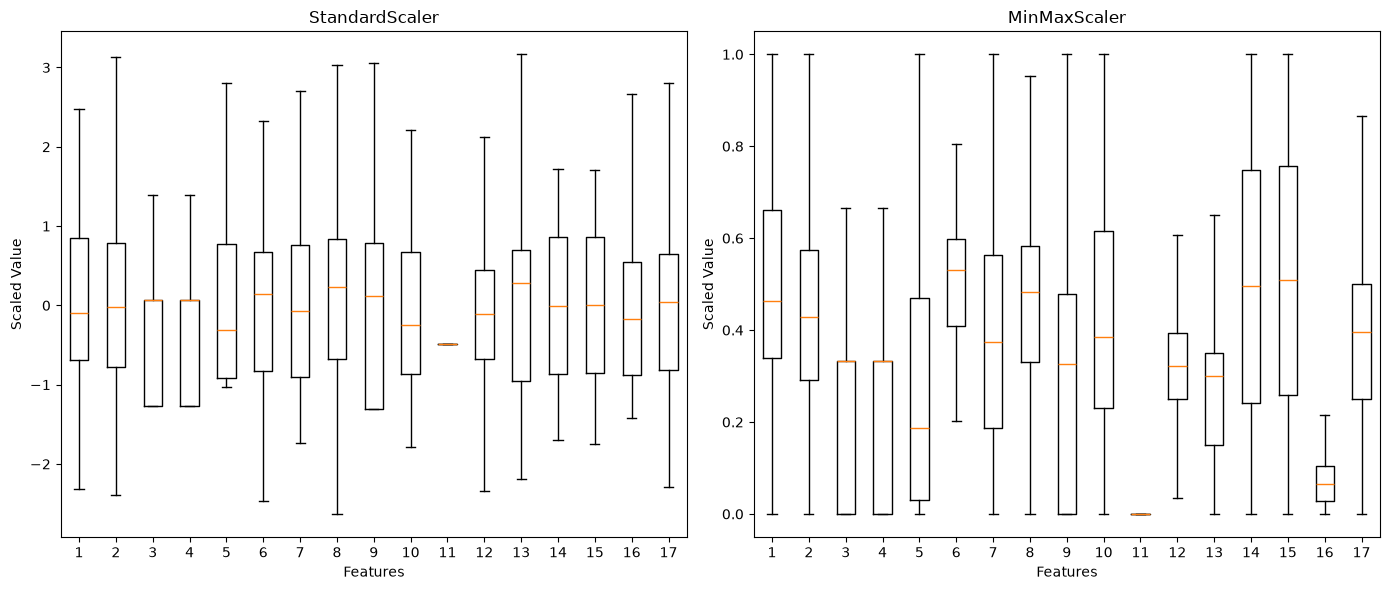

In [31]:
# ============================================================
# SCALING COMPARISON VISUALIZATION
# ============================================================

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)

plt.boxplot(
    standard_scaled_df.values,
    showfliers=False
)

plt.title("StandardScaler")
plt.xlabel("Features")
plt.ylabel("Scaled Value")

plt.subplot(1, 2, 2)

plt.boxplot(
    minmax_scaled_df.values,
    showfliers=False
)

plt.title("MinMaxScaler")
plt.xlabel("Features")
plt.ylabel("Scaled Value")

plt.tight_layout()

plt.show()

In [32]:
# ============================================================
# SELECT FINAL SCALING METHOD
# ============================================================

final_scaler = StandardScaler()

scaled_df = pd.DataFrame(
    final_scaler.fit_transform(selected_df),
    columns=selected_features,
    index=selected_df.index
)

print("=" * 60)
print("FINAL SCALING METHOD")
print("=" * 60)

print("\nSelected Method: StandardScaler")

print("\nFinal Scaled Dataset Shape:")
print(scaled_df.shape)

print("\nMean:")
print(scaled_df.mean().round(4))

print("\nStandard Deviation:")
print(scaled_df.std().round(4))

FINAL SCALING METHOD

Selected Method: StandardScaler

Final Scaled Dataset Shape:
(2237, 17)

Mean:
numerical__Customer_Age                     0.0
numerical__Income                          -0.0
numerical__Total_Children                  -0.0
numerical__Family_Size                     -0.0
numerical__Total_Spending                   0.0
numerical__Average_Spending_per_Purchase   -0.0
numerical__Total_Purchases                 -0.0
numerical__NumWebPurchases                  0.0
numerical__NumCatalogPurchases              0.0
numerical__NumStorePurchases                0.0
numerical__Total_Campaign_Acceptance        0.0
numerical__Digital_Engagement               0.0
numerical__NumWebVisitsMonth                0.0
numerical__Recency                         -0.0
numerical__Customer_Tenure_Years           -0.0
numerical__Deal_Dependency                  0.0
numerical__NumDealsPurchases               -0.0
dtype: float64

Standard Deviation:
numerical__Customer_Age                     1.0

In [33]:
# ============================================================
# SAVE SCALED DATASET
# ============================================================

scaled_output_dir = "../Customer_Segmentation/Scaled_Data"

os.makedirs(
    scaled_output_dir,
    exist_ok=True
)

scaled_output_path = os.path.join(
    scaled_output_dir,
    "standard_scaled_features.csv"
)

scaled_df.to_csv(
    scaled_output_path,
    index=False
)

print(
    "\nScaled dataset saved to:"
)

print(
    os.path.abspath(scaled_output_path)
)


Scaled dataset saved to:
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Customer_Segmentation\Scaled_Data\standard_scaled_features.csv


In [35]:
# ============================================================
# SAVE STANDARD SCALER
# ============================================================

import joblib

scaler_output_path = os.path.join(
    scaled_output_dir,
    "standard_scaler.pkl"
)

joblib.dump(
    final_scaler,
    scaler_output_path
)

print(
    "Scaler saved to:"
)

print(
    os.path.abspath(scaler_output_path)
)

Scaler saved to:
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Customer_Segmentation\Scaled_Data\standard_scaler.pkl


In [36]:
# ============================================================
# SAVE SCALING COMPARISON REPORT
# ============================================================

report_output_path = os.path.join(
    scaled_output_dir,
    "scaling_comparison_report.csv"
)

scaling_comparison.to_csv(
    report_output_path,
    index=False
)

print(
    "Scaling comparison report saved to:"
)

print(
    os.path.abspath(report_output_path)
)

Scaling comparison report saved to:
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Customer_Segmentation\Scaled_Data\scaling_comparison_report.csv


In [37]:
# ============================================================
# TASK 3 SUMMARY
# ============================================================

print("=" * 60)
print("TASK 3 – FEATURE SCALING SUMMARY")
print("=" * 60)

print("\nOriginal Dataset Shape:")
print(selected_df.shape)

print("\nStandardScaler Dataset Shape:")
print(standard_scaled_df.shape)

print("\nMinMaxScaler Dataset Shape:")
print(minmax_scaled_df.shape)

print("\nScaling Methods Compared:")
print("- StandardScaler")
print("- MinMaxScaler")

print("\nSelected Scaling Method:")
print("StandardScaler")

print("\nReason:")
print(
    "StandardScaler was selected because it places numerical "
    "features on a comparable scale by centering them around "
    "zero and scaling them according to their standard deviation."
)

print("\nTask 3 completed successfully.")

TASK 3 – FEATURE SCALING SUMMARY

Original Dataset Shape:
(2237, 17)

StandardScaler Dataset Shape:
(2237, 17)

MinMaxScaler Dataset Shape:
(2237, 17)

Scaling Methods Compared:
- StandardScaler
- MinMaxScaler

Selected Scaling Method:
StandardScaler

Reason:
StandardScaler was selected because it places numerical features on a comparable scale by centering them around zero and scaling them according to their standard deviation.

Task 3 completed successfully.


# Task 4 – Exploratory Cluster Analysis

## Objective

The objective of this task is to explore the selected customer features before applying clustering algorithms.

The analysis includes:

- Feature distributions
- Boxplots
- Correlation heatmap
- Pair plot
- PCA visualization

These visualizations help identify patterns, relationships, distributions, and potential clusters in the customer dataset.

In [38]:
# ============================================================
# TASK 4 – EXPLORATORY CLUSTER ANALYSIS
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA

print("Libraries imported successfully.")

Libraries imported successfully.


In [39]:
# ============================================================
# LOAD SCALED DATA
# ============================================================

scaled_file = "../Scaled_Data/standard_scaled_features.csv"

scaled_df = pd.read_csv(scaled_file)

print("=" * 60)
print("SCALED DATASET")
print("=" * 60)

print("\nShape:")
print(scaled_df.shape)

print("\nMissing Values:")
print(scaled_df.isnull().sum().sum())

print("\nPreview:")
display(scaled_df.head())

SCALED DATASET

Shape:
(2237, 17)

Missing Values:
0

Preview:


,numerical__Customer_Age,numerical__Income,numerical__Total_Children,numerical__Family_Size,numerical__Total_Spending,numerical__Average_Spending_per_Purchase,numerical__Total_Purchases,numerical__NumWebPurchases,numerical__NumCatalogPurchases,numerical__NumStorePurchases,numerical__Total_Campaign_Acceptance,numerical__Digital_Engagement,numerical__NumWebVisitsMonth,numerical__Recency,numerical__Customer_Tenure_Years,numerical__Deal_Dependency,numerical__NumDealsPurchases
0,1.017296,0.300178,-1.264618,-1.264618,1.799304,1.193944,1.312543,1.280532,1.805202,-0.552077,-0.482053,1.560532,0.692882,0.307272,1.530038,-0.547897,0.652082
1,1.273722,-0.263278,1.395420,1.395420,-0.990209,-1.548990,-1.185961,-1.396839,-0.405715,-1.167421,-0.482053,-0.950312,-0.131574,-0.383584,-1.191484,1.359646,0.041655
2,0.333495,0.943942,-1.264618,-1.264618,0.380303,0.470482,1.034932,1.280532,0.120139,1.293956,-0.482053,0.723584,-0.543802,-0.798098,-0.206788,-1.090985,-0.818695
3,-1.290534,-1.204345,0.065401,0.065401,-0.942634,-1.255130,-0.908350,-0.675081,-1.304670,-0.552077,-0.482053,-0.392347,0.280654,-0.798098,-1.062830,0.550386,0.041655
4,-1.034108,0.307583,0.065401,0.065401,-0.267442,0.167739,0.202097,0.558774,0.493239,0.063267,-0.482053,0.165619,-0.131574,1.550812,-0.953970,0.671996,1.512432


In [40]:
# ============================================================
# CREATE VISUALIZATION DIRECTORY
# ============================================================

visualization_dir = "../Visualizations"

os.makedirs(
    visualization_dir,
    exist_ok=True
)

print(
    "Visualization directory ready:"
)

print(
    os.path.abspath(visualization_dir)
)

Visualization directory ready:
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Visualizations


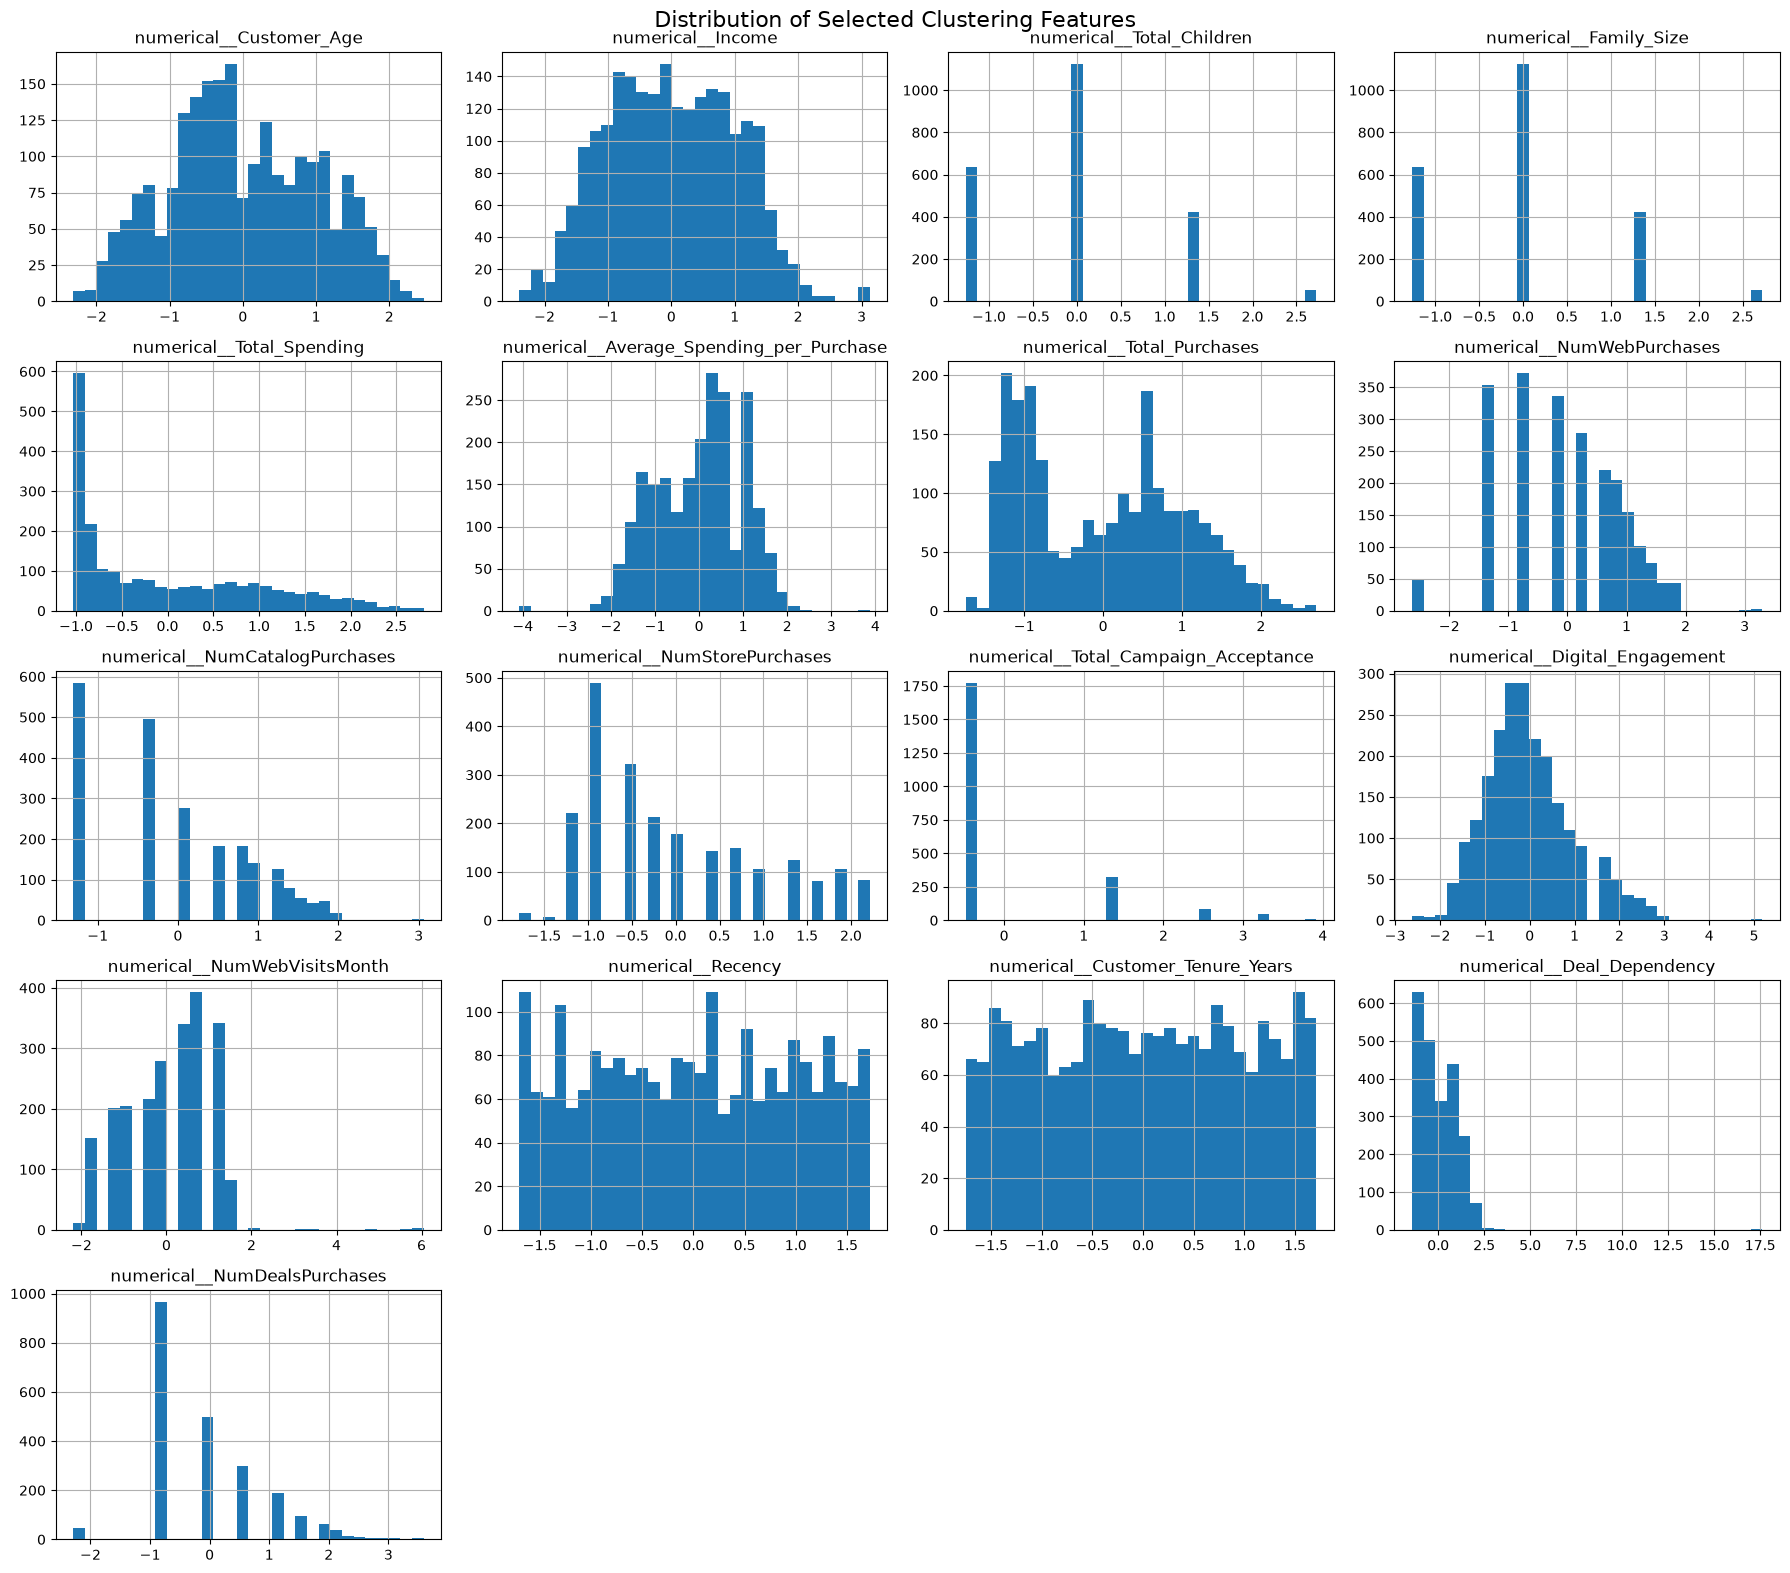


Distribution plot saved to:
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Visualizations\feature_distributions.png


In [41]:
# ============================================================
# FEATURE DISTRIBUTIONS
# ============================================================

scaled_df.hist(
    figsize=(18, 16),
    bins=30
)

plt.suptitle(
    "Distribution of Selected Clustering Features",
    fontsize=16
)

plt.tight_layout()

distribution_path = os.path.join(
    visualization_dir,
    "feature_distributions.png"
)

plt.savefig(
    distribution_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "\nDistribution plot saved to:"
)

print(
    os.path.abspath(distribution_path)
)

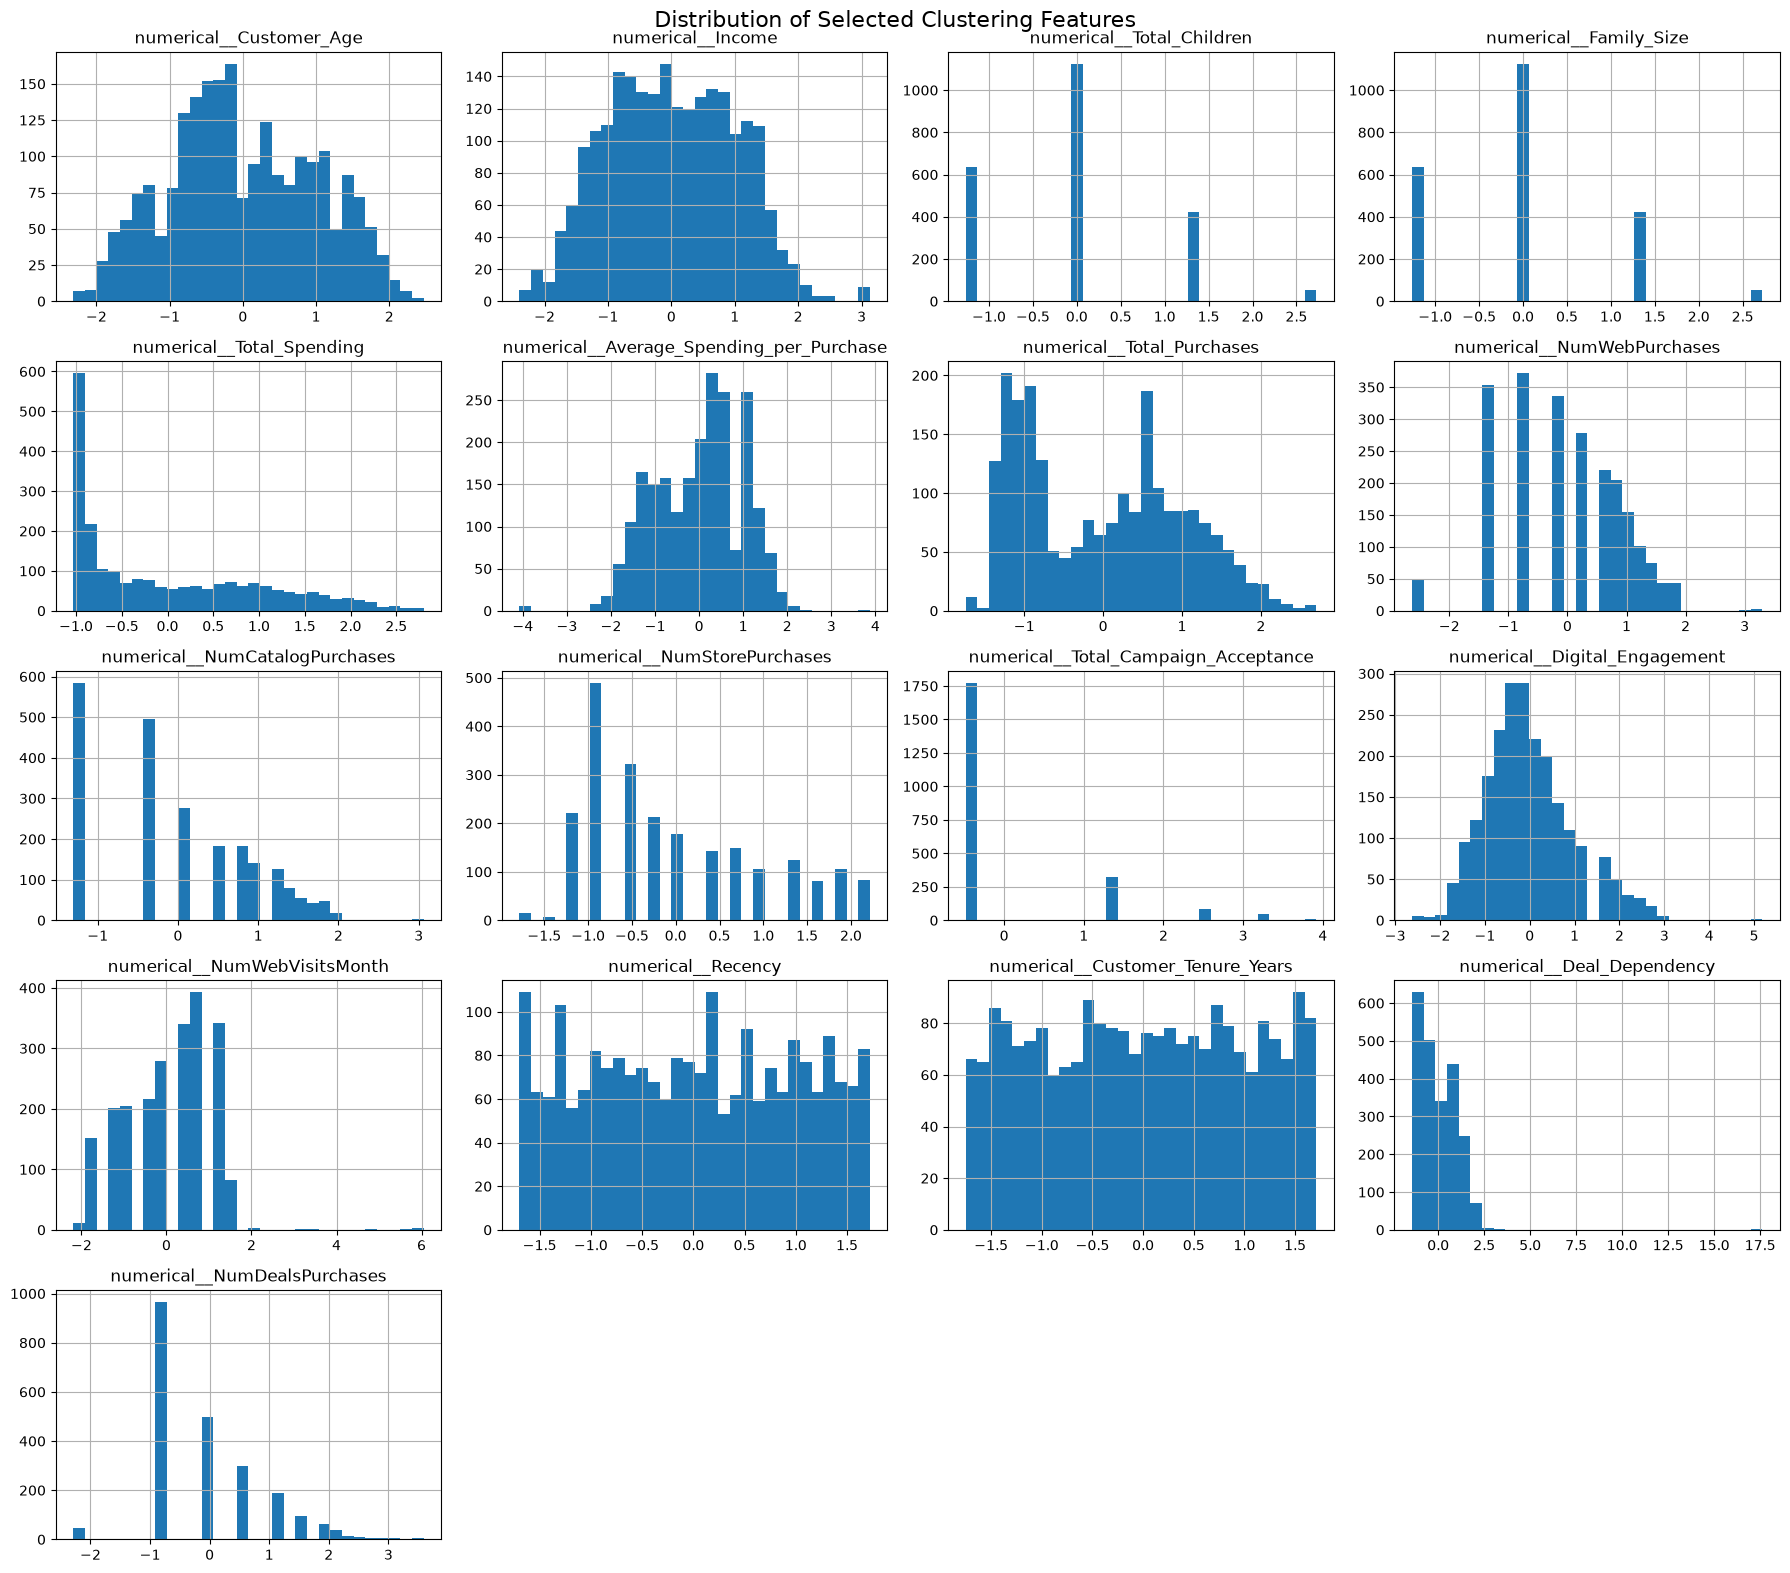


Distribution plot saved to:
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Visualizations\feature_distributions.png


In [42]:
# ============================================================
# FEATURE DISTRIBUTIONS
# ============================================================

scaled_df.hist(
    figsize=(18, 16),
    bins=30
)

plt.suptitle(
    "Distribution of Selected Clustering Features",
    fontsize=16
)

plt.tight_layout()

distribution_path = os.path.join(
    visualization_dir,
    "feature_distributions.png"
)

plt.savefig(
    distribution_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "\nDistribution plot saved to:"
)

print(
    os.path.abspath(distribution_path)
)

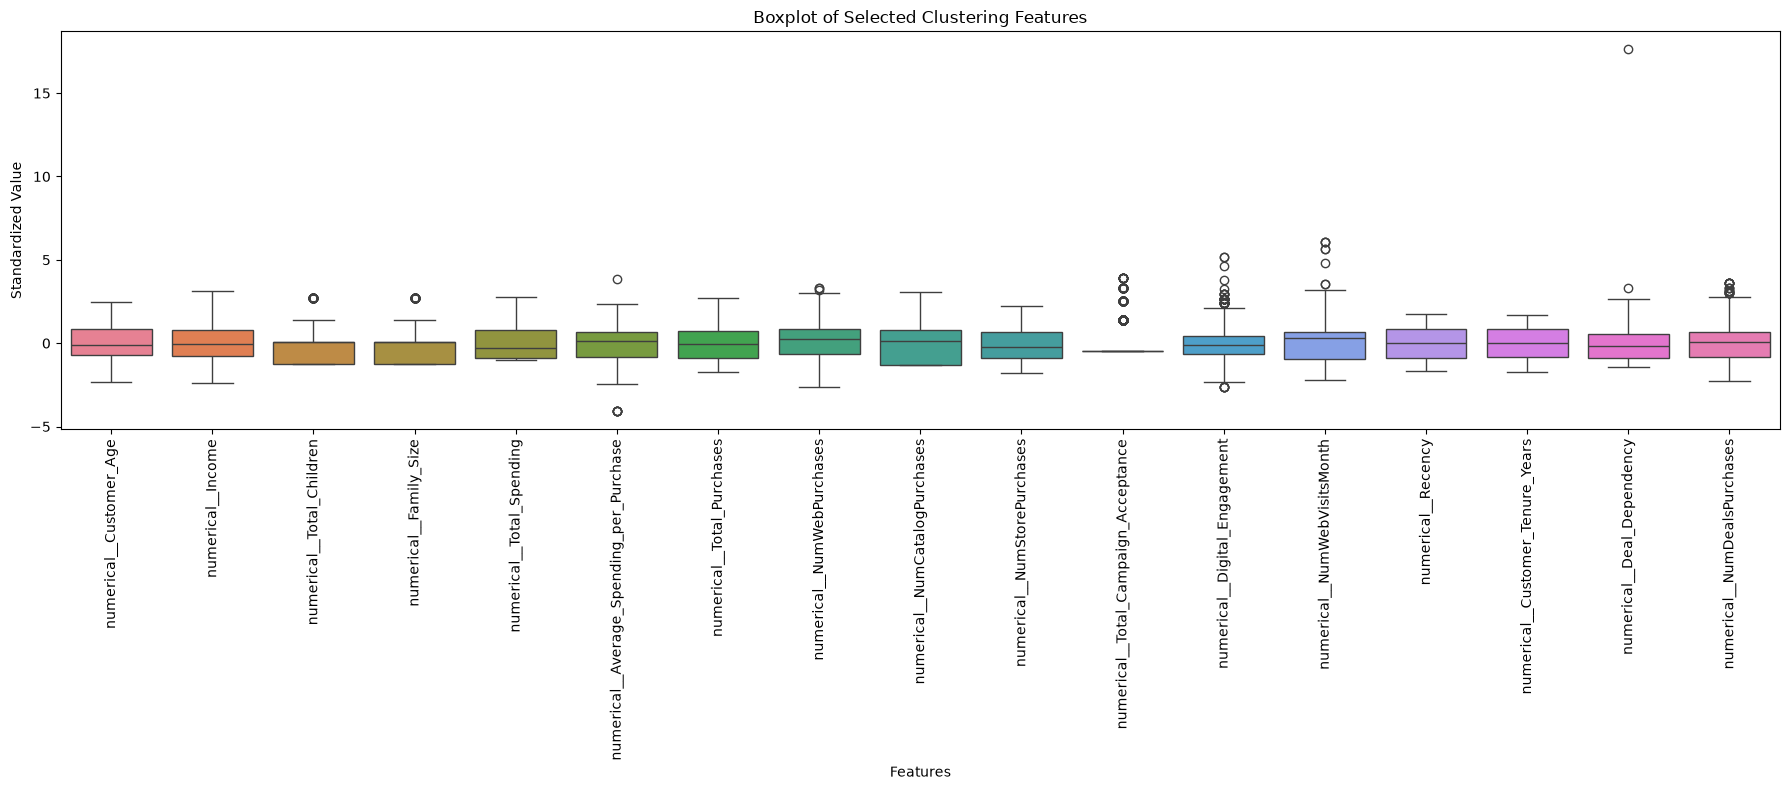


Boxplot saved to:
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Visualizations\feature_boxplots.png


In [43]:
# ============================================================
# BOXPLOT
# ============================================================

plt.figure(
    figsize=(18, 8)
)

sns.boxplot(
    data=scaled_df
)

plt.xticks(
    rotation=90
)

plt.title(
    "Boxplot of Selected Clustering Features"
)

plt.xlabel(
    "Features"
)

plt.ylabel(
    "Standardized Value"
)

plt.tight_layout()

boxplot_path = os.path.join(
    visualization_dir,
    "feature_boxplots.png"
)

plt.savefig(
    boxplot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "\nBoxplot saved to:"
)

print(
    os.path.abspath(boxplot_path)
)

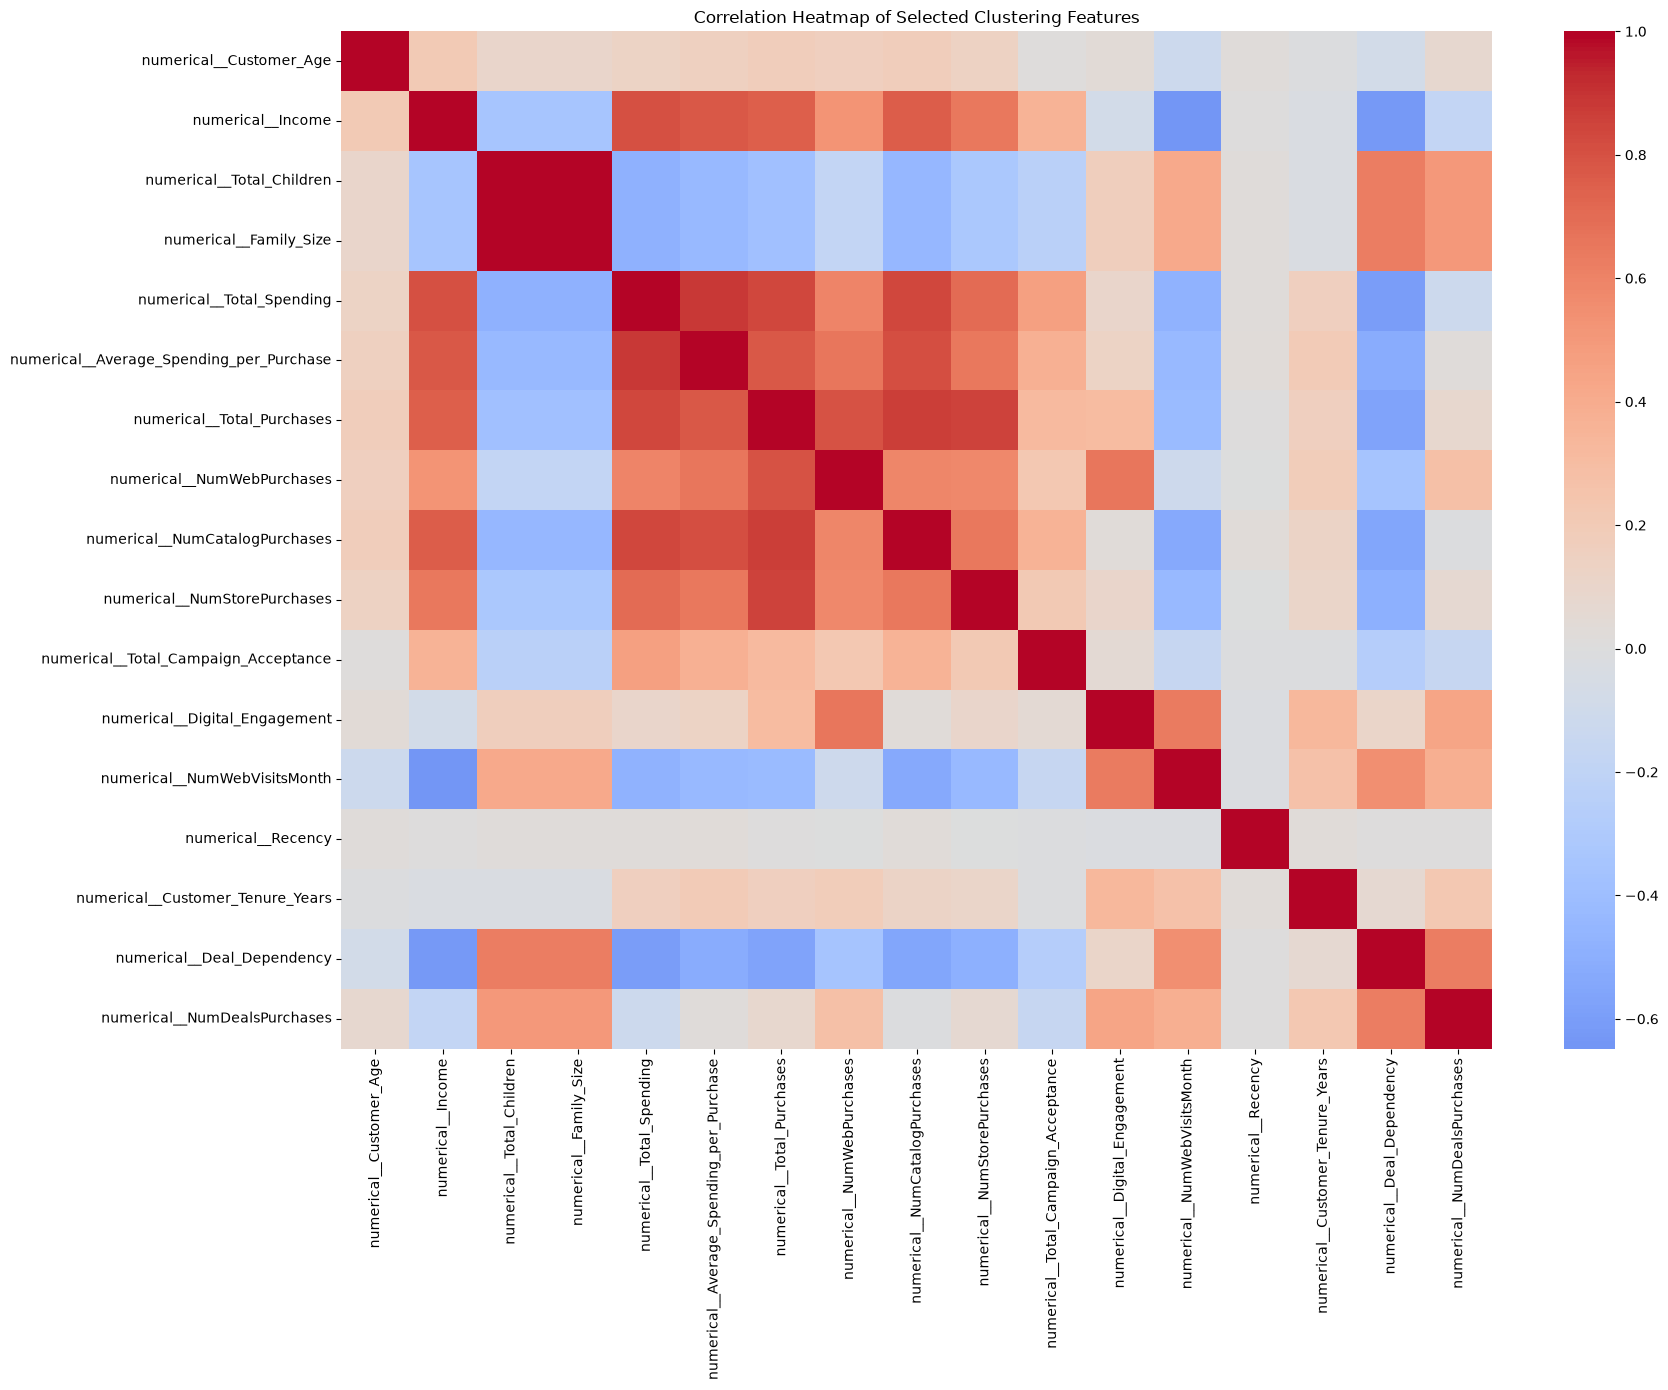


Correlation heatmap saved to:
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Visualizations\correlation_heatmap.png


In [44]:
# ============================================================
# CORRELATION HEATMAP
# ============================================================

correlation_matrix = scaled_df.corr()

plt.figure(
    figsize=(18, 14)
)

sns.heatmap(
    correlation_matrix,
    annot=False,
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Heatmap of Selected Clustering Features"
)

plt.tight_layout()

heatmap_path = os.path.join(
    visualization_dir,
    "correlation_heatmap.png"
)

plt.savefig(
    heatmap_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "\nCorrelation heatmap saved to:"
)

print(
    os.path.abspath(heatmap_path)
)

In [46]:
# ============================================================
# STRONGEST CORRELATIONS
# ============================================================

correlation_pairs = (
    correlation_matrix
    .where(
        np.triu(
            np.ones(
                correlation_matrix.shape
            ),
            k=1
        ).astype(bool)
    )
    .stack()
    .sort_values(
        key=abs,
        ascending=False
    )
)

print("=" * 60)
print("TOP 15 STRONGEST CORRELATIONS")
print("=" * 60)

display(
    correlation_pairs.head(15)
)

TOP 15 STRONGEST CORRELATIONS


numerical__Total_Children                 numerical__Family_Size                      1.000000
numerical__Total_Spending                 numerical__Average_Spending_per_Purchase    0.881375
numerical__Total_Purchases                numerical__NumCatalogPurchases              0.865433
                                          numerical__NumStorePurchases                0.855399
numerical__Total_Spending                 numerical__NumCatalogPurchases              0.835166
                                          numerical__Total_Purchases                  0.834176
numerical__Average_Spending_per_Purchase  numerical__NumCatalogPurchases              0.814309
numerical__Income                         numerical__Total_Spending                   0.803296
numerical__Total_Purchases                numerical__NumWebPurchases                  0.796431
numerical__Average_Spending_per_Purchase  numerical__Total_Purchases                  0.773200
numerical__Income                         numerica

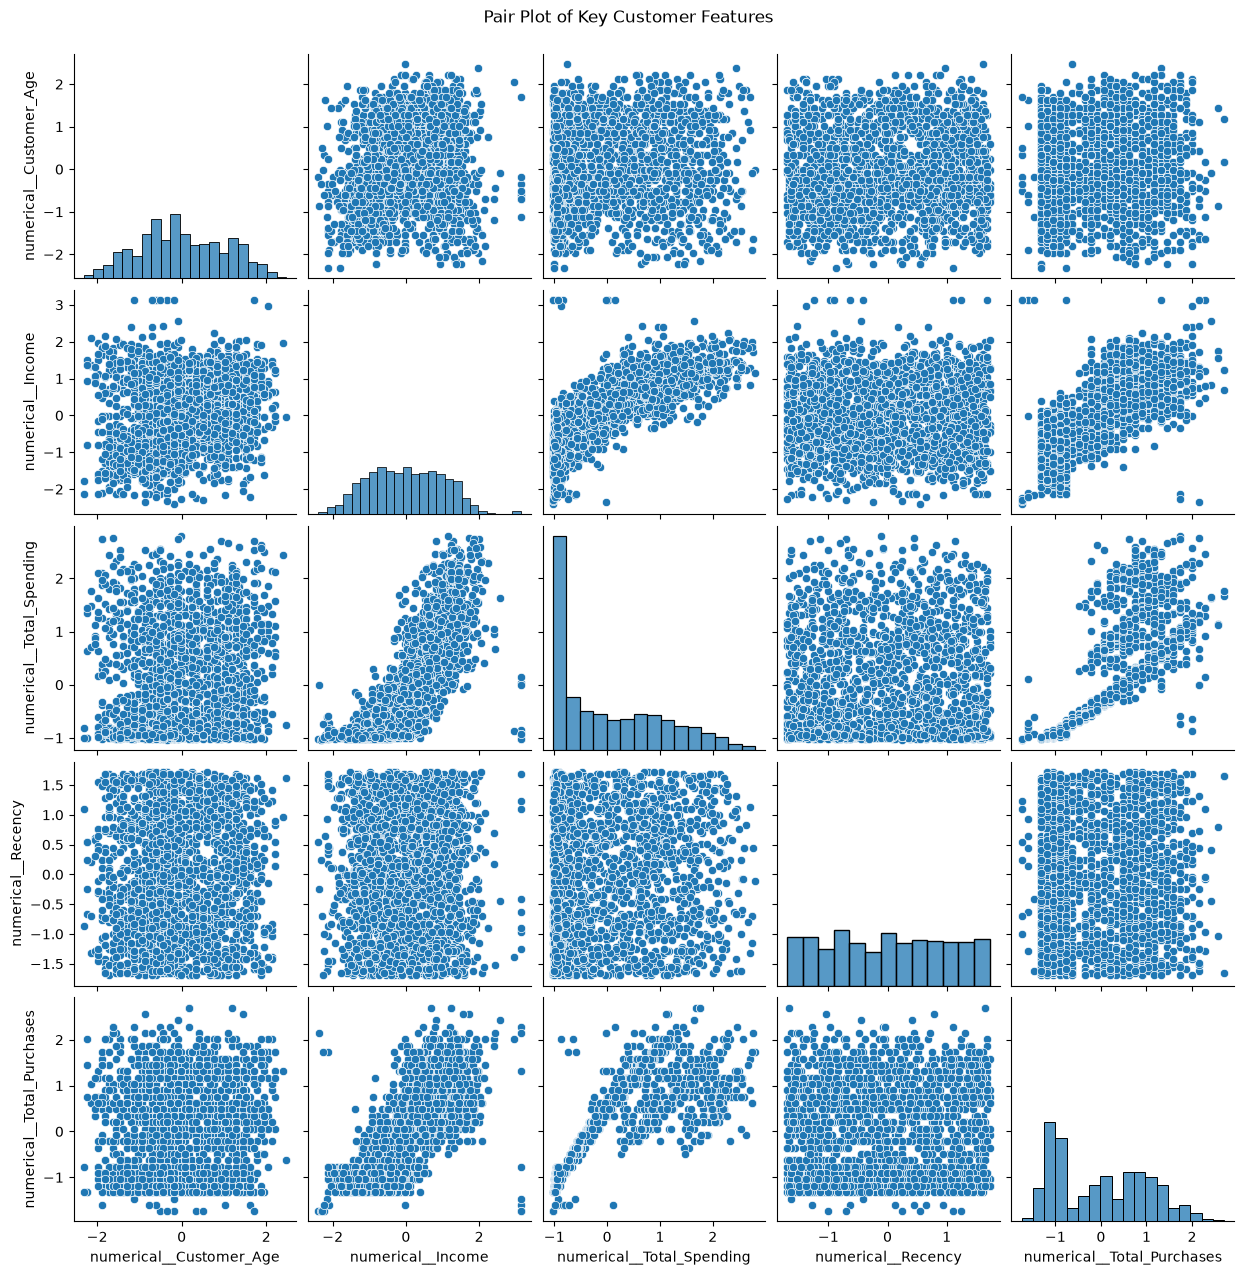


Pair plot saved to:
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Visualizations\key_features_pairplot.png


In [47]:
# ============================================================
# PAIR PLOT
# ============================================================

pair_features = [
    "numerical__Customer_Age",
    "numerical__Income",
    "numerical__Total_Spending",
    "numerical__Recency",
    "numerical__Total_Purchases"
]

pair_features = [
    feature
    for feature in pair_features
    if feature in scaled_df.columns
]

pair_plot = sns.pairplot(
    scaled_df[pair_features]
)

pair_plot.fig.suptitle(
    "Pair Plot of Key Customer Features",
    y=1.02
)

pair_plot_path = os.path.join(
    visualization_dir,
    "key_features_pairplot.png"
)

pair_plot.savefig(
    pair_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "\nPair plot saved to:"
)

print(
    os.path.abspath(pair_plot_path)
)

In [48]:
# ============================================================
# PCA – 2 COMPONENTS
# ============================================================

pca = PCA(
    n_components=2
)

pca_result = pca.fit_transform(
    scaled_df
)

pca_df = pd.DataFrame(
    pca_result,
    columns=[
        "PC1",
        "PC2"
    ]
)

print("=" * 60)
print("PCA RESULTS")
print("=" * 60)

print("\nPCA Dataset Shape:")
print(pca_df.shape)

print("\nExplained Variance Ratio:")

print(
    "PC1:",
    round(
        pca.explained_variance_ratio_[0],
        4
    )
)

print(
    "PC2:",
    round(
        pca.explained_variance_ratio_[1],
        4
    )
)

print(
    "\nTotal Variance Explained:",
    round(
        pca.explained_variance_ratio_.sum(),
        4
    )
)

PCA RESULTS

PCA Dataset Shape:
(2237, 2)

Explained Variance Ratio:
PC1: 0.412
PC2: 0.1744

Total Variance Explained: 0.5864


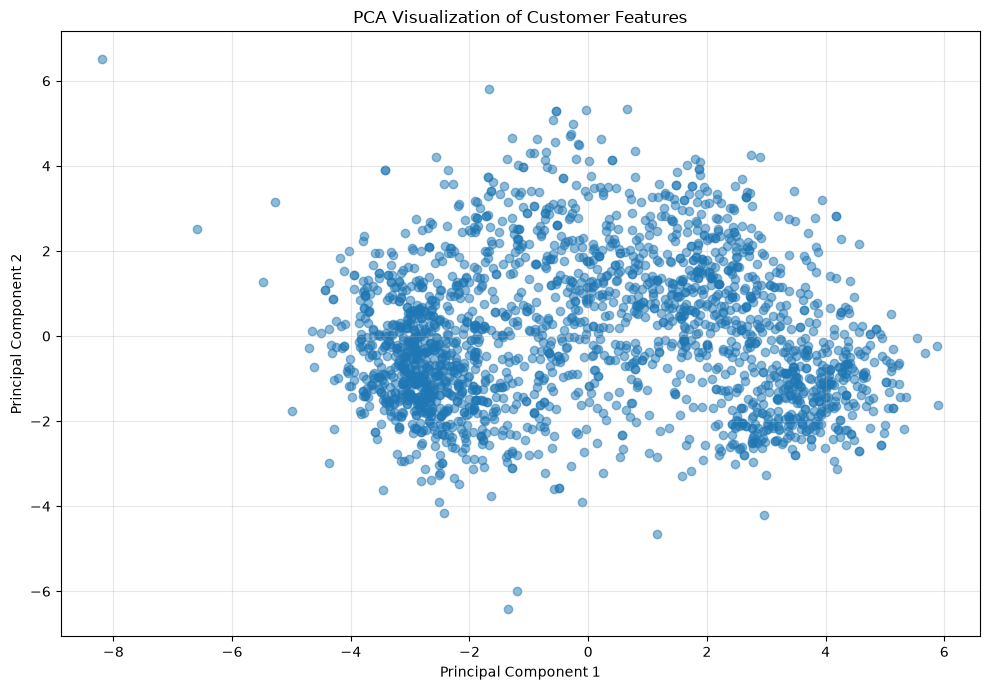


PCA visualization saved to:
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Visualizations\pca_visualization.png


In [49]:
# ============================================================
# PCA VISUALIZATION
# ============================================================

plt.figure(
    figsize=(10, 7)
)

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    alpha=0.5
)

plt.title(
    "PCA Visualization of Customer Features"
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

pca_path = os.path.join(
    visualization_dir,
    "pca_visualization.png"
)

plt.savefig(
    pca_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "\nPCA visualization saved to:"
)

print(
    os.path.abspath(pca_path)
)

In [50]:
# ============================================================
# SAVE PCA DATA
# ============================================================

pca_output_path = os.path.join(
    visualization_dir,
    "pca_components.csv"
)

pca_df.to_csv(
    pca_output_path,
    index=False
)

print(
    "PCA data saved to:"
)

print(
    os.path.abspath(pca_output_path)
)

PCA data saved to:
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Visualizations\pca_components.csv


In [51]:
# ============================================================
# TASK 4 SUMMARY
# ============================================================

print("=" * 60)
print("TASK 4 – EXPLORATORY CLUSTER ANALYSIS SUMMARY")
print("=" * 60)

print("\nDataset Shape:")
print(scaled_df.shape)

print("\nVisualizations Created:")

print("1. Feature Distribution Histograms")
print("2. Feature Boxplots")
print("3. Correlation Heatmap")
print("4. Key Feature Pair Plot")
print("5. PCA Visualization")

print("\nPCA Components:")
print("PC1 Variance:",
      round(pca.explained_variance_ratio_[0], 4))

print("PC2 Variance:",
      round(pca.explained_variance_ratio_[1], 4))

print(
    "Total Variance Explained:",
    round(
        pca.explained_variance_ratio_.sum(),
        4
    )
)

print("\nTask 4 completed successfully.")

TASK 4 – EXPLORATORY CLUSTER ANALYSIS SUMMARY

Dataset Shape:
(2237, 17)

Visualizations Created:
1. Feature Distribution Histograms
2. Feature Boxplots
3. Correlation Heatmap
4. Key Feature Pair Plot
5. PCA Visualization

PCA Components:
PC1 Variance: 0.412
PC2 Variance: 0.1744
Total Variance Explained: 0.5864

Task 4 completed successfully.


# Task 5 – Determine Optimal Number of Clusters

## Objective

The objective of this task is to determine the optimal number of customer clusters for K-Means clustering.

K-Means models will be trained using K values from 2 to 10.

The Within-Cluster Sum of Squares (WCSS), also known as inertia, will be calculated for each K.

An Elbow Curve will be used to identify the point where adding additional clusters provides diminishing improvement.

In [52]:
# ============================================================
# TASK 5 – OPTIMAL NUMBER OF CLUSTERS
# ============================================================

from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt
import os

print("K-Means library imported successfully.")

K-Means library imported successfully.


In [53]:
# ============================================================
# LOAD SCALED DATA
# ============================================================

scaled_file = "../Scaled_Data/standard_scaled_features.csv"

scaled_df = pd.read_csv(scaled_file)

print("=" * 60)
print("SCALED DATASET LOADED")
print("=" * 60)

print("Rows:", scaled_df.shape[0])
print("Features:", scaled_df.shape[1])

print("\nMissing Values:")
print(scaled_df.isnull().sum().sum())

SCALED DATASET LOADED
Rows: 2237
Features: 17

Missing Values:
0


In [54]:
# ============================================================
# K-MEANS FOR K = 2 TO 10
# ============================================================

k_values = range(2, 11)

inertia_values = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_df)

    inertia_values.append(
        kmeans.inertia_
    )

print("=" * 60)
print("K-MEANS INERTIA RESULTS")
print("=" * 60)

for k, inertia in zip(
    k_values,
    inertia_values
):

    print(
        f"K = {k}: Inertia = {inertia:.2f}"
    )

K-MEANS INERTIA RESULTS
K = 2: Inertia = 25631.54
K = 3: Inertia = 21715.62
K = 4: Inertia = 20023.84
K = 5: Inertia = 18760.30
K = 6: Inertia = 17695.21
K = 7: Inertia = 16897.51
K = 8: Inertia = 16317.28
K = 9: Inertia = 15803.29
K = 10: Inertia = 15397.16


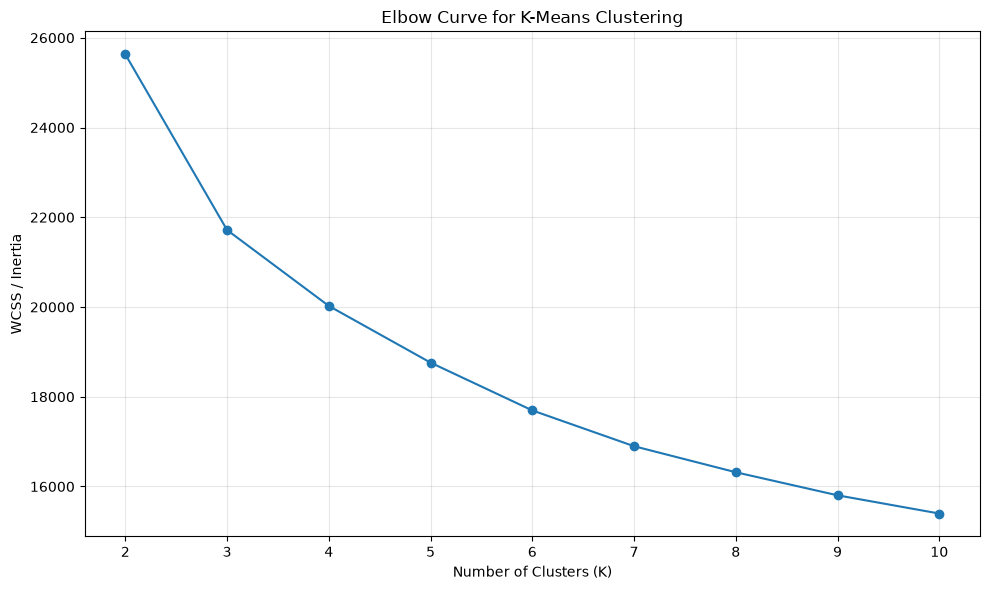


Elbow curve saved to:
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Visualizations\elbow_curve.png


In [55]:
# ============================================================
# ELBOW CURVE
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    list(k_values),
    inertia_values,
    marker="o"
)

plt.xlabel(
    "Number of Clusters (K)"
)

plt.ylabel(
    "WCSS / Inertia"
)

plt.title(
    "Elbow Curve for K-Means Clustering"
)

plt.xticks(
    list(k_values)
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

elbow_path = "../Visualizations/elbow_curve.png"

plt.savefig(
    elbow_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "\nElbow curve saved to:"
)

print(
    os.path.abspath(elbow_path)
)

In [56]:
# ============================================================
# SAVE ELBOW RESULTS
# ============================================================

elbow_results = pd.DataFrame({
    "K": list(k_values),
    "Inertia_WCSS": inertia_values
})

elbow_results_path = "../Reports/task_5_elbow_results.csv"

elbow_results.to_csv(
    elbow_results_path,
    index=False
)

print(
    "Elbow results saved to:"
)

print(
    os.path.abspath(elbow_results_path)
)

display(
    elbow_results
)

Elbow results saved to:
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Reports\task_5_elbow_results.csv


,K,Inertia_WCSS
0,2,25631.538184
1,3,21715.615158
2,4,20023.836614
3,5,18760.303612
4,6,17695.215000
5,7,16897.509682
6,8,16317.279428
7,9,15803.288115
8,10,15397.161817


In [57]:
# ============================================================
# INERTIA IMPROVEMENT
# ============================================================

elbow_results["Inertia_Reduction"] = (
    elbow_results["Inertia_WCSS"]
    .shift(1)
    - elbow_results["Inertia_WCSS"]
)

elbow_results["Percentage_Reduction"] = (
    elbow_results["Inertia_Reduction"]
    / elbow_results["Inertia_WCSS"].shift(1)
) * 100

print("=" * 60)
print("INERTIA REDUCTION ANALYSIS")
print("=" * 60)

display(
    elbow_results.round(2)
)

INERTIA REDUCTION ANALYSIS


,K,Inertia_WCSS,Inertia_Reduction,Percentage_Reduction
0,2,25631.54,NaN,NaN
1,3,21715.62,3915.92,15.28
2,4,20023.84,1691.78,7.79
3,5,18760.30,1263.53,6.31
4,6,17695.21,1065.09,5.68
5,7,16897.51,797.71,4.51
6,8,16317.28,580.23,3.43
7,9,15803.29,513.99,3.15
8,10,15397.16,406.13,2.57


In [58]:
# ============================================================
# TASK 5 SUMMARY
# ============================================================

print("=" * 60)
print("TASK 5 – OPTIMAL NUMBER OF CLUSTERS SUMMARY")
print("=" * 60)

print(
    "\nK values tested:"
)

print(
    "2 to 10"
)

print(
    "\nInertia/WCSS values:"
)

for k, inertia in zip(
    k_values,
    inertia_values
):

    print(
        f"K = {k}: {inertia:.2f}"
    )

print(
    "\nElbow Curve:"
)

print(
    "Generated successfully."
)

print(
    "\nTask 5 completed successfully."
)

TASK 5 – OPTIMAL NUMBER OF CLUSTERS SUMMARY

K values tested:
2 to 10

Inertia/WCSS values:
K = 2: 25631.54
K = 3: 21715.62
K = 4: 20023.84
K = 5: 18760.30
K = 6: 17695.21
K = 7: 16897.51
K = 8: 16317.28
K = 9: 15803.29
K = 10: 15397.16

Elbow Curve:
Generated successfully.

Task 5 completed successfully.


# Task 6 – Silhouette Score Analysis

## Objective

The objective of this task is to evaluate the quality of K-Means clustering using the Silhouette Score.

K-Means models will be evaluated for K values from 2 to 10.

The Silhouette Score will be calculated for each K and visualized to identify the number of clusters that provides the best separation and cohesion.

In [59]:
# ============================================================
# TASK 6 – SILHOUETTE SCORE ANALYSIS
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt
import os

print("Libraries imported successfully.")

Libraries imported successfully.


In [60]:
# ============================================================
# LOAD SCALED DATA
# ============================================================

scaled_file = "../Scaled_Data/standard_scaled_features.csv"

scaled_df = pd.read_csv(scaled_file)

print("=" * 60)
print("SCALED DATASET LOADED")
print("=" * 60)

print("Rows:", scaled_df.shape[0])
print("Columns:", scaled_df.shape[1])

print("\nMissing Values:")
print(scaled_df.isnull().sum().sum())

SCALED DATASET LOADED
Rows: 2237
Columns: 17

Missing Values:
0


In [61]:
# ============================================================
# SILHOUETTE SCORE FOR K = 2 TO 10
# ============================================================

k_values = range(2, 11)

silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(
        scaled_df
    )

    score = silhouette_score(
        scaled_df,
        cluster_labels
    )

    silhouette_scores.append(score)

print("=" * 60)
print("SILHOUETTE SCORE RESULTS")
print("=" * 60)

for k, score in zip(
    k_values,
    silhouette_scores
):

    print(
        f"K = {k}: Silhouette Score = {score:.4f}"
    )

SILHOUETTE SCORE RESULTS
K = 2: Silhouette Score = 0.2929
K = 3: Silhouette Score = 0.2442
K = 4: Silhouette Score = 0.1909
K = 5: Silhouette Score = 0.1680
K = 6: Silhouette Score = 0.1606
K = 7: Silhouette Score = 0.1616
K = 8: Silhouette Score = 0.1430
K = 9: Silhouette Score = 0.1555
K = 10: Silhouette Score = 0.1381


In [62]:
# ============================================================
# FIND BEST K
# ============================================================

best_index = silhouette_scores.index(
    max(silhouette_scores)
)

best_k_silhouette = list(k_values)[
    best_index
]

best_silhouette_score = silhouette_scores[
    best_index
]

print("=" * 60)
print("BEST K BASED ON SILHOUETTE SCORE")
print("=" * 60)

print(
    "Best K:",
    best_k_silhouette
)

print(
    "Best Silhouette Score:",
    round(
        best_silhouette_score,
        4
    )
)

BEST K BASED ON SILHOUETTE SCORE
Best K: 2
Best Silhouette Score: 0.2929


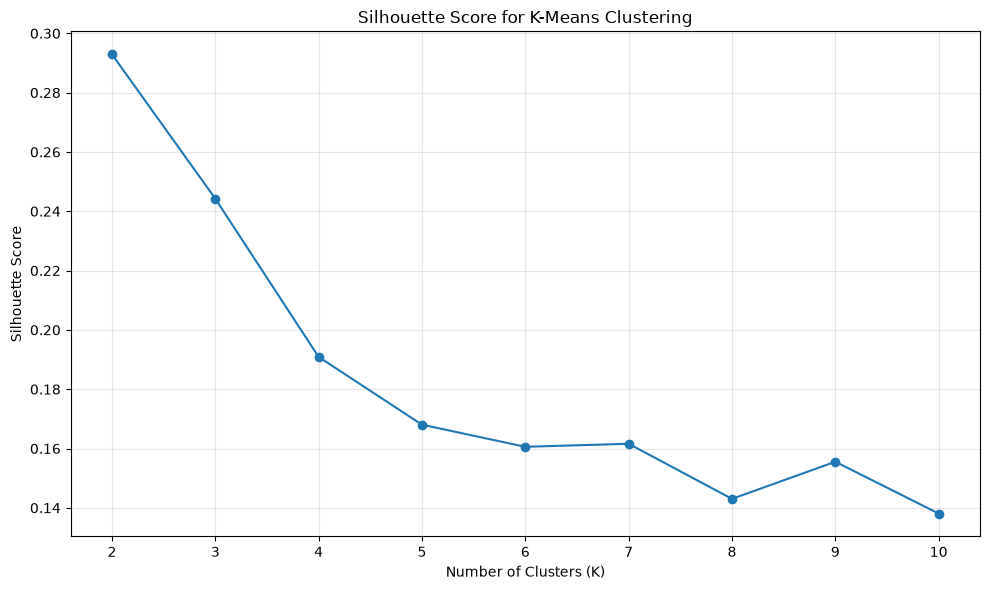


Silhouette score plot saved to:
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Visualizations\silhouette_scores.png


In [63]:
# ============================================================
# SILHOUETTE SCORE PLOT
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o"
)

plt.xlabel(
    "Number of Clusters (K)"
)

plt.ylabel(
    "Silhouette Score"
)

plt.title(
    "Silhouette Score for K-Means Clustering"
)

plt.xticks(
    list(k_values)
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

silhouette_plot_path = (
    "../Visualizations/silhouette_scores.png"
)

plt.savefig(
    silhouette_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "\nSilhouette score plot saved to:"
)

print(
    os.path.abspath(
        silhouette_plot_path
    )
)

In [64]:
# ============================================================
# SAVE SILHOUETTE RESULTS
# ============================================================

silhouette_results = pd.DataFrame({
    "K": list(k_values),
    "Silhouette_Score": silhouette_scores
})

silhouette_results_path = (
    "../Reports/task_6_silhouette_results.csv"
)

silhouette_results.to_csv(
    silhouette_results_path,
    index=False
)

print(
    "Silhouette results saved to:"
)

print(
    os.path.abspath(
        silhouette_results_path
    )
)

display(
    silhouette_results.round(4)
)

Silhouette results saved to:
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Reports\task_6_silhouette_results.csv


,K,Silhouette_Score
0,2,0.2929
1,3,0.2442
2,4,0.1909
3,5,0.1680
4,6,0.1606
5,7,0.1616
6,8,0.1430
7,9,0.1555
8,10,0.1381


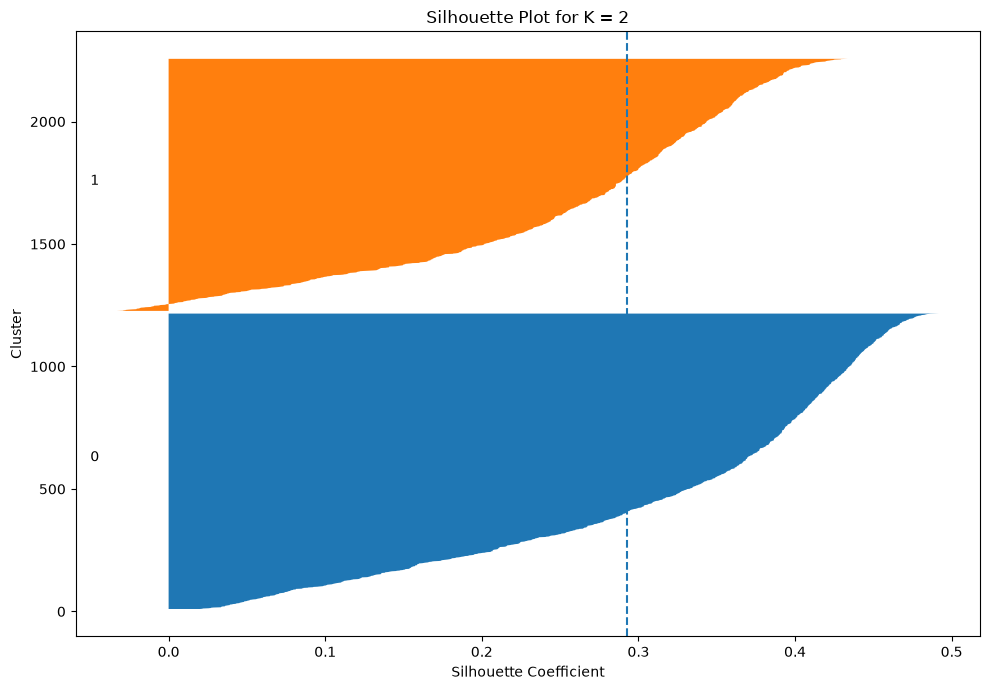


Detailed silhouette plot saved to:
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Visualizations\silhouette_plot_best_k.png


In [65]:
# ============================================================
# DETAILED SILHOUETTE PLOT FOR BEST K
# ============================================================

from sklearn.metrics import silhouette_samples
import numpy as np

best_kmeans = KMeans(
    n_clusters=best_k_silhouette,
    random_state=42,
    n_init=10
)

best_labels = best_kmeans.fit_predict(
    scaled_df
)

sample_silhouette_values = silhouette_samples(
    scaled_df,
    best_labels
)

plt.figure(
    figsize=(10, 7)
)

y_lower = 10

for cluster in range(
    best_k_silhouette
):

    cluster_values = sample_silhouette_values[
        best_labels == cluster
    ]

    cluster_values.sort()

    size_cluster = cluster_values.shape[0]

    y_upper = (
        y_lower
        + size_cluster
    )

    plt.fill_betweenx(
        np.arange(
            y_lower,
            y_upper
        ),
        0,
        cluster_values
    )

    plt.text(
        -0.05,
        y_lower + 0.5 * size_cluster,
        str(cluster)
    )

    y_lower = (
        y_upper
        + 10
    )

plt.axvline(
    x=best_silhouette_score,
    linestyle="--"
)

plt.title(
    f"Silhouette Plot for K = {best_k_silhouette}"
)

plt.xlabel(
    "Silhouette Coefficient"
)

plt.ylabel(
    "Cluster"
)

plt.tight_layout()

detailed_silhouette_path = (
    "../Visualizations/"
    "silhouette_plot_best_k.png"
)

plt.savefig(
    detailed_silhouette_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "\nDetailed silhouette plot saved to:"
)

print(
    os.path.abspath(
        detailed_silhouette_path
    )
)

In [66]:
# ============================================================
# TASK 6 SUMMARY
# ============================================================

print("=" * 60)
print("TASK 6 – SILHOUETTE SCORE ANALYSIS SUMMARY")
print("=" * 60)

print(
    "\nK Values Tested:"
)

print(
    "2 to 10"
)

print(
    "\nBest K:",
    best_k_silhouette
)

print(
    "Best Silhouette Score:",
    round(
        best_silhouette_score,
        4
    )
)

print(
    "\nResults saved to:"
)

print(
    "Reports/task_6_silhouette_results.csv"
)

print(
    "\nVisualization saved to:"
)

print(
    "Visualizations/silhouette_scores.png"
)

print(
    "Visualizations/silhouette_plot_best_k.png"
)

print(
    "\nTask 6 completed successfully."
)

TASK 6 – SILHOUETTE SCORE ANALYSIS SUMMARY

K Values Tested:
2 to 10

Best K: 2
Best Silhouette Score: 0.2929

Results saved to:
Reports/task_6_silhouette_results.csv

Visualization saved to:
Visualizations/silhouette_scores.png
Visualizations/silhouette_plot_best_k.png

Task 6 completed successfully.


# Task 7 – Davies–Bouldin Index

## Objective

The objective of this task is to evaluate the quality of K-Means clustering using the Davies–Bouldin Index.

The Davies–Bouldin Index measures cluster compactness and separation.

K-Means models will be evaluated for K values from 2 to 10.

A lower Davies–Bouldin Index indicates better-defined clusters.

In [67]:
# ============================================================
# TASK 7 – DAVIES–BOULDIN INDEX
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score
import pandas as pd
import matplotlib.pyplot as plt
import os

print("Libraries imported successfully.")

Libraries imported successfully.


In [68]:
# ============================================================
# LOAD SCALED DATA
# ============================================================

scaled_file = "../Scaled_Data/standard_scaled_features.csv"

scaled_df = pd.read_csv(scaled_file)

print("=" * 60)
print("SCALED DATASET LOADED")
print("=" * 60)

print("Rows:", scaled_df.shape[0])
print("Columns:", scaled_df.shape[1])

print("\nMissing Values:")
print(scaled_df.isnull().sum().sum())

SCALED DATASET LOADED
Rows: 2237
Columns: 17

Missing Values:
0


In [69]:
# ============================================================
# DAVIES–BOULDIN INDEX FOR K = 2 TO 10
# ============================================================

k_values = range(2, 11)

db_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(
        scaled_df
    )

    db_score = davies_bouldin_score(
        scaled_df,
        cluster_labels
    )

    db_scores.append(
        db_score
    )

print("=" * 60)
print("DAVIES–BOULDIN INDEX RESULTS")
print("=" * 60)

for k, score in zip(
    k_values,
    db_scores
):

    print(
        f"K = {k}: Davies-Bouldin Index = {score:.4f}"
    )

DAVIES–BOULDIN INDEX RESULTS
K = 2: Davies-Bouldin Index = 1.3796
K = 3: Davies-Bouldin Index = 1.5421
K = 4: Davies-Bouldin Index = 1.7524
K = 5: Davies-Bouldin Index = 1.8168
K = 6: Davies-Bouldin Index = 1.8299
K = 7: Davies-Bouldin Index = 1.7998
K = 8: Davies-Bouldin Index = 1.9633
K = 9: Davies-Bouldin Index = 1.8970
K = 10: Davies-Bouldin Index = 1.9762


In [70]:
# ============================================================
# BEST K BASED ON DAVIES–BOULDIN INDEX
# ============================================================

best_db_index = db_scores.index(
    min(db_scores)
)

best_k_db = list(k_values)[
    best_db_index
]

best_db_score = db_scores[
    best_db_index
]

print("=" * 60)
print("BEST K BASED ON DAVIES–BOULDIN INDEX")
print("=" * 60)

print(
    "Best K:",
    best_k_db
)

print(
    "Lowest Davies-Bouldin Index:",
    round(
        best_db_score,
        4
    )
)

BEST K BASED ON DAVIES–BOULDIN INDEX
Best K: 2
Lowest Davies-Bouldin Index: 1.3796


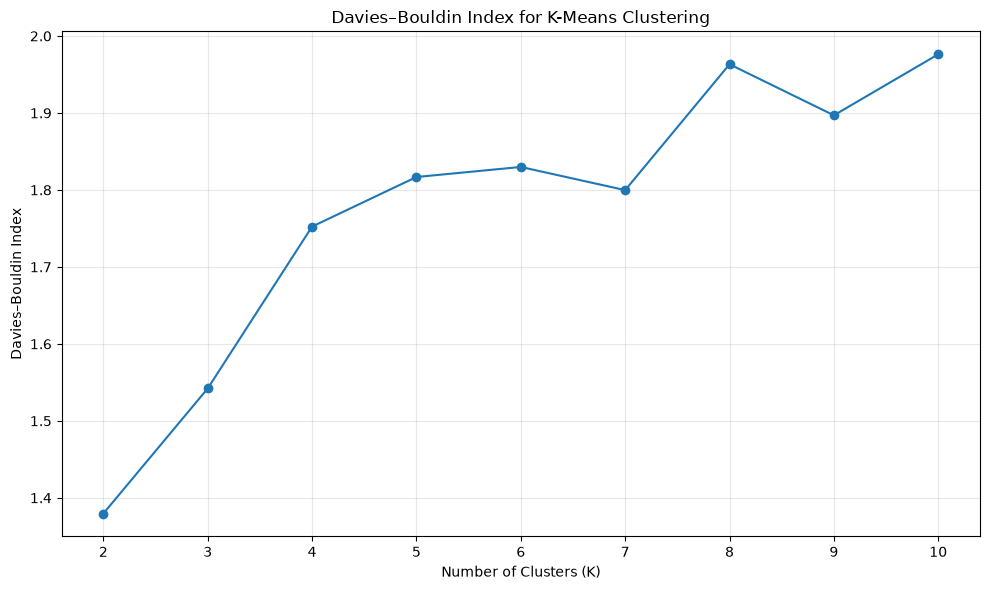


DB Index plot saved to:
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Visualizations\davies_bouldin_scores.png


In [71]:
# ============================================================
# DAVIES–BOULDIN INDEX PLOT
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    list(k_values),
    db_scores,
    marker="o"
)

plt.xlabel(
    "Number of Clusters (K)"
)

plt.ylabel(
    "Davies–Bouldin Index"
)

plt.title(
    "Davies–Bouldin Index for K-Means Clustering"
)

plt.xticks(
    list(k_values)
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

db_plot_path = (
    "../Visualizations/"
    "davies_bouldin_scores.png"
)

plt.savefig(
    db_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "\nDB Index plot saved to:"
)

print(
    os.path.abspath(
        db_plot_path
    )
)

In [72]:
# ============================================================
# COMBINE CLUSTERING METRICS
# ============================================================

# Load Task 6 results
silhouette_file = (
    "../Reports/"
    "task_6_silhouette_results.csv"
)

silhouette_results = pd.read_csv(
    silhouette_file
)

# Load Task 5 results
elbow_file = (
    "../Reports/"
    "task_5_elbow_results.csv"
)

elbow_results = pd.read_csv(
    elbow_file
)

# Create DB results dataframe
db_results = pd.DataFrame({
    "K": list(k_values),
    "Davies_Bouldin_Index": db_scores
})

# Merge all results
comparison_results = elbow_results[
    ["K", "Inertia_WCSS"]
].merge(
    silhouette_results[
        ["K", "Silhouette_Score"]
    ],
    on="K"
).merge(
    db_results,
    on="K"
)

print("=" * 60)
print("CLUSTERING METRICS COMPARISON")
print("=" * 60)

display(
    comparison_results.round(4)
)

CLUSTERING METRICS COMPARISON


,K,Inertia_WCSS,Silhouette_Score,Davies_Bouldin_Index
0,2,25631.5382,0.2929,1.3796
1,3,21715.6152,0.2442,1.5421
2,4,20023.8366,0.1909,1.7524
3,5,18760.3036,0.1680,1.8168
4,6,17695.2150,0.1606,1.8299
5,7,16897.5097,0.1616,1.7998
6,8,16317.2794,0.1430,1.9633
7,9,15803.2881,0.1555,1.8970
8,10,15397.1618,0.1381,1.9762


In [74]:
# ============================================================
# SAVE CLUSTERING METRICS COMPARISON
# ============================================================

comparison_path = (
    "../Reports/"
    "task_7_clustering_metrics_comparison.csv"
)

comparison_results.to_csv(
    comparison_path,
    index=False
)

print(
    "Comparison table saved to:"
)

print(
    os.path.abspath(
        comparison_path
    )
)

Comparison table saved to:
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Reports\task_7_clustering_metrics_comparison.csv


In [75]:
# ============================================================
# BEST K COMPARISON
# ============================================================

best_k_elbow = elbow_results.loc[
    elbow_results["Inertia_WCSS"].idxmin(),
    "K"
]

best_k_silhouette = silhouette_results.loc[
    silhouette_results["Silhouette_Score"].idxmax(),
    "K"
]

best_k_db = comparison_results.loc[
    comparison_results["Davies_Bouldin_Index"].idxmin(),
    "K"
]

print("=" * 60)
print("BEST K ACCORDING TO EACH METHOD")
print("=" * 60)

print(
    "\nElbow Method:"
)

print(
    "Elbow analysis must be interpreted from the curve."
)

print(
    "\nBest K according to Silhouette Score:",
    int(best_k_silhouette)
)

print(
    "Best K according to Davies-Bouldin Index:",
    int(best_k_db)
)

BEST K ACCORDING TO EACH METHOD

Elbow Method:
Elbow analysis must be interpreted from the curve.

Best K according to Silhouette Score: 2
Best K according to Davies-Bouldin Index: 2


In [76]:
# ============================================================
# TASK 7 SUMMARY
# ============================================================

print("=" * 60)
print("TASK 7 – DAVIES–BOULDIN INDEX SUMMARY")
print("=" * 60)

print(
    "\nK Values Tested:"
)

print(
    "2 to 10"
)

print(
    "\nBest K according to Davies-Bouldin Index:",
    int(best_k_db)
)

print(
    "Lowest Davies-Bouldin Index:",
    round(
        best_db_score,
        4
    )
)

print(
    "\nBest K according to Silhouette Score:",
    int(best_k_silhouette)
)

print(
    "\nFiles Created:"
)

print(
    "1. Reports/task_7_clustering_metrics_comparison.csv"
)

print(
    "2. Visualizations/davies_bouldin_scores.png"
)

print(
    "\nTask 7 completed successfully."
)

TASK 7 – DAVIES–BOULDIN INDEX SUMMARY

K Values Tested:
2 to 10

Best K according to Davies-Bouldin Index: 2
Lowest Davies-Bouldin Index: 1.3796

Best K according to Silhouette Score: 2

Files Created:
1. Reports/task_7_clustering_metrics_comparison.csv
2. Visualizations/davies_bouldin_scores.png

Task 7 completed successfully.


## Task 7 – Interpretation

The clustering metrics were evaluated for K values from 2 to 10.

The Silhouette Score was highest at K = 2 with a score of 0.2929. The Davies–Bouldin Index was also lowest at K = 2 with a value of 1.3796.

The Elbow Method indicated a possible elbow around K = 3, as the reduction in inertia became progressively smaller after this point.

Since both the Silhouette Score and Davies–Bouldin Index selected K = 2, K = 2 was selected as the initial baseline value for K-Means clustering.

The final number of clusters will be confirmed later through comparison with other clustering algorithms and business interpretation.

# Task 8 – Baseline Model (K-Means)

## Objective

The objective of this task is to develop a baseline customer segmentation model using K-Means clustering.

Based on the results from the Elbow Method, Silhouette Score, and Davies–Bouldin Index, K = 2 is selected as the initial number of clusters.

The model will be evaluated using cluster size, cluster centers, Silhouette Score, and Davies–Bouldin Index.

PCA and t-SNE will be used to visualize the resulting customer segments.

In [77]:
# ============================================================
# TASK 8 – BASELINE K-MEANS MODEL
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

print("Libraries imported successfully.")

Libraries imported successfully.


In [78]:
# ============================================================
# LOAD SCALED DATA
# ============================================================

scaled_file = "../Scaled_Data/standard_scaled_features.csv"

scaled_df = pd.read_csv(
    scaled_file
)

print("=" * 60)
print("SCALED DATASET LOADED")
print("=" * 60)

print("Rows:", scaled_df.shape[0])
print("Columns:", scaled_df.shape[1])

print("\nMissing Values:")
print(
    scaled_df.isnull().sum().sum()
)

print("\nData Type Check:")
print(
    scaled_df.dtypes.value_counts()
)

SCALED DATASET LOADED
Rows: 2237
Columns: 17

Missing Values:
0

Data Type Check:
float64    17
Name: count, dtype: int64


In [79]:
# ============================================================
# TRAIN BASELINE K-MEANS MODEL
# ============================================================

BASELINE_K = 2

kmeans_baseline = KMeans(
    n_clusters=BASELINE_K,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_baseline.fit_predict(
    scaled_df
)

print("=" * 60)
print("BASELINE K-MEANS MODEL")
print("=" * 60)

print(
    "Number of Clusters:",
    BASELINE_K
)

print(
    "Model trained successfully."
)

BASELINE K-MEANS MODEL
Number of Clusters: 2
Model trained successfully.


In [80]:
# ============================================================
# ADD CLUSTER LABELS
# ============================================================

clustered_df = scaled_df.copy()

clustered_df["Cluster"] = cluster_labels

print(
    clustered_df.head()
)

print(
    "\nCluster labels added successfully."
)

   numerical__Customer_Age  numerical__Income  numerical__Total_Children  \
0                 1.017296           0.300178                  -1.264618   
1                 1.273722          -0.263278                   1.395420   
2                 0.333495           0.943942                  -1.264618   
3                -1.290534          -1.204345                   0.065401   
4                -1.034108           0.307583                   0.065401   

   numerical__Family_Size  numerical__Total_Spending  \
0               -1.264618                   1.799304   
1                1.395420                  -0.990209   
2               -1.264618                   0.380303   
3                0.065401                  -0.942634   
4                0.065401                  -0.267442   

   numerical__Average_Spending_per_Purchase  numerical__Total_Purchases  \
0                                  1.193944                    1.312543   
1                                 -1.548990             

In [81]:
# ============================================================
# CLUSTER SIZE
# This tells us how many customers belong to each segment.
# ============================================================

cluster_sizes = (
    clustered_df["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_percentages = (
    cluster_sizes
    / len(clustered_df)
    * 100
)

cluster_size_summary = pd.DataFrame({
    "Cluster": cluster_sizes.index,
    "Customer_Count": cluster_sizes.values,
    "Percentage": cluster_percentages.values
})

print("=" * 60)
print("CLUSTER SIZE")
print("=" * 60)

display(
    cluster_size_summary.round(2)
)

CLUSTER SIZE


,Cluster,Customer_Count,Percentage
0,0,1207,53.96
1,1,1030,46.04


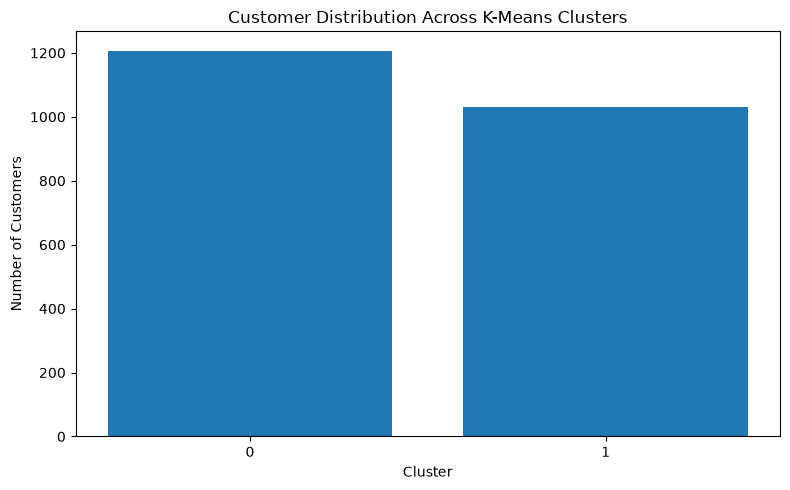

Cluster size chart saved to:
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Visualizations\baseline_cluster_sizes.png


In [82]:
# ============================================================
# CLUSTER SIZE BAR CHART
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    cluster_size_summary["Cluster"].astype(str),
    cluster_size_summary["Customer_Count"]
)

plt.xlabel(
    "Cluster"
)

plt.ylabel(
    "Number of Customers"
)

plt.title(
    "Customer Distribution Across K-Means Clusters"
)

plt.tight_layout()

cluster_size_path = (
    "../Visualizations/"
    "baseline_cluster_sizes.png"
)

plt.savefig(
    cluster_size_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Cluster size chart saved to:"
)

print(
    os.path.abspath(
        cluster_size_path
    )
)

In [83]:
# ============================================================
# BASELINE MODEL EVALUATION
# ============================================================

baseline_silhouette = silhouette_score(
    scaled_df,
    cluster_labels
)

baseline_db = davies_bouldin_score(
    scaled_df,
    cluster_labels
)

baseline_inertia = (
    kmeans_baseline.inertia_
)

print("=" * 60)
print("BASELINE MODEL EVALUATION")
print("=" * 60)

print(
    "K:",
    BASELINE_K
)

print(
    "Inertia / WCSS:",
    round(
        baseline_inertia,
        4
    )
)

print(
    "Silhouette Score:",
    round(
        baseline_silhouette,
        4
    )
)

print(
    "Davies-Bouldin Index:",
    round(
        baseline_db,
        4
    )
)

BASELINE MODEL EVALUATION
K: 2
Inertia / WCSS: 25631.5382
Silhouette Score: 0.2929
Davies-Bouldin Index: 1.3796


In [85]:
# ============================================================
# CLUSTER CENTERS
# ============================================================

cluster_centers = pd.DataFrame(
    kmeans_baseline.cluster_centers_,
    columns=scaled_df.columns
)

cluster_centers.index.name = "Cluster"

print("=" * 60)
print("CLUSTER CENTERS")
print("=" * 60)

display(
    cluster_centers.round(4)
)

CLUSTER CENTERS


,numerical__Customer_Age,numerical__Income,numerical__Total_Children,numerical__Family_Size,numerical__Total_Spending,numerical__Average_Spending_per_Purchase,numerical__Total_Purchases,numerical__NumWebPurchases,numerical__NumCatalogPurchases,numerical__NumStorePurchases,numerical__Total_Campaign_Acceptance,numerical__Digital_Engagement,numerical__NumWebVisitsMonth,numerical__Recency,numerical__Customer_Tenure_Years,numerical__Deal_Dependency,numerical__NumDealsPurchases
Cluster,,,,,,,,,,,,,,,,,
0,-0.1534,-0.7120,0.4621,0.4621,-0.7693,-0.7149,-0.7721,-0.5497,-0.7452,-0.6811,-0.3120,-0.0644,0.4904,-0.0105,-0.0773,0.6183,0.1451
1,0.1798,0.8344,-0.5415,-0.5415,0.9015,0.8378,0.9048,0.6441,0.8733,0.7981,0.3656,0.0754,-0.5746,0.0123,0.0906,-0.7245,-0.1700


In [86]:
# ============================================================
# SAVE CLUSTER CENTERS
# ============================================================

cluster_centers_path = (
    "../Reports/"
    "baseline_cluster_centers.csv"
)

cluster_centers.to_csv(
    cluster_centers_path
)

print(
    "Cluster centers saved to:"
)

print(
    os.path.abspath(
        cluster_centers_path
    )
)

Cluster centers saved to:
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Reports\baseline_cluster_centers.csv


In [87]:
# ============================================================
# PCA VISUALIZATION
# ============================================================

pca = PCA(
    n_components=2,
    random_state=42
)

pca_data = pca.fit_transform(
    scaled_df
)

pca_df = pd.DataFrame({
    "PC1": pca_data[:, 0],
    "PC2": pca_data[:, 1],
    "Cluster": cluster_labels
})

explained_variance = (
    pca.explained_variance_ratio_
    * 100
)

print("=" * 60)
print("PCA RESULTS")
print("=" * 60)

print(
    "PC1 Variance:",
    round(
        explained_variance[0],
        2
    ),
    "%"
)

print(
    "PC2 Variance:",
    round(
        explained_variance[1],
        2
    ),
    "%"
)

print(
    "Total Variance Explained:",
    round(
        explained_variance.sum(),
        2
    ),
    "%"
)

PCA RESULTS
PC1 Variance: 41.2 %
PC2 Variance: 17.44 %
Total Variance Explained: 58.64 %


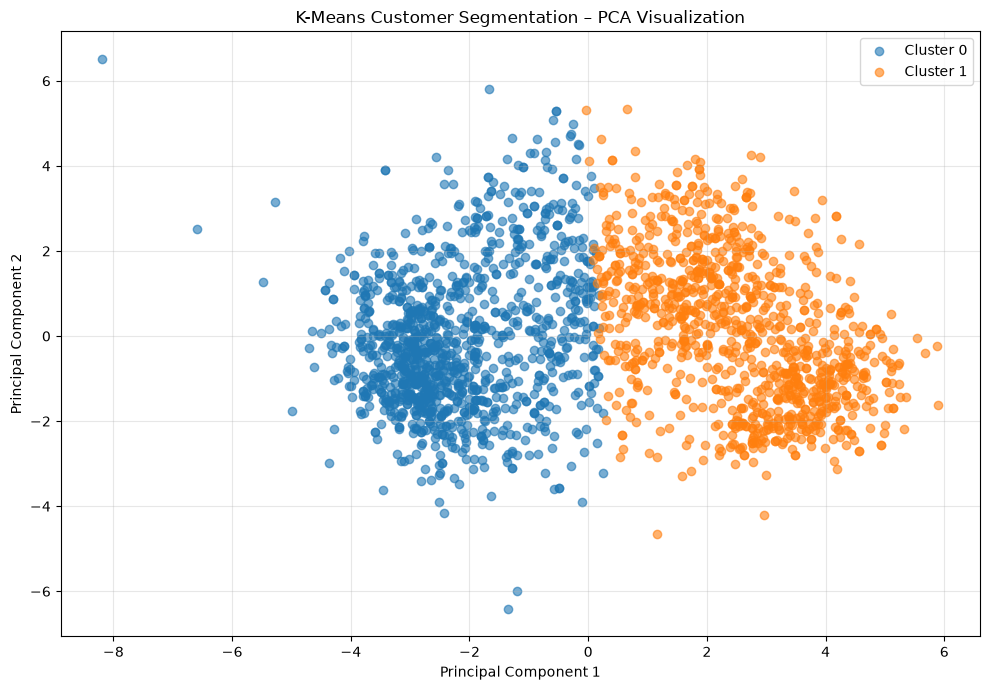

PCA cluster visualization saved to:
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Visualizations\baseline_kmeans_pca.png


In [88]:
# ============================================================
# PCA CLUSTER VISUALIZATION
# ============================================================

plt.figure(
    figsize=(10, 7)
)

for cluster in sorted(
    pca_df["Cluster"].unique()
):

    cluster_data = pca_df[
        pca_df["Cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.title(
    "K-Means Customer Segmentation – PCA Visualization"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

pca_cluster_path = (
    "../Visualizations/"
    "baseline_kmeans_pca.png"
)

plt.savefig(
    pca_cluster_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "PCA cluster visualization saved to:"
)

print(
    os.path.abspath(
        pca_cluster_path
    )
)

In [89]:
# ============================================================
# t-SNE VISUALIZATION
# ============================================================

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    max_iter=1000,
    init="pca"
)

tsne_data = tsne.fit_transform(
    scaled_df
)

tsne_df = pd.DataFrame({
    "TSNE1": tsne_data[:, 0],
    "TSNE2": tsne_data[:, 1],
    "Cluster": cluster_labels
})

print(
    "t-SNE transformation completed successfully."
)

t-SNE transformation completed successfully.


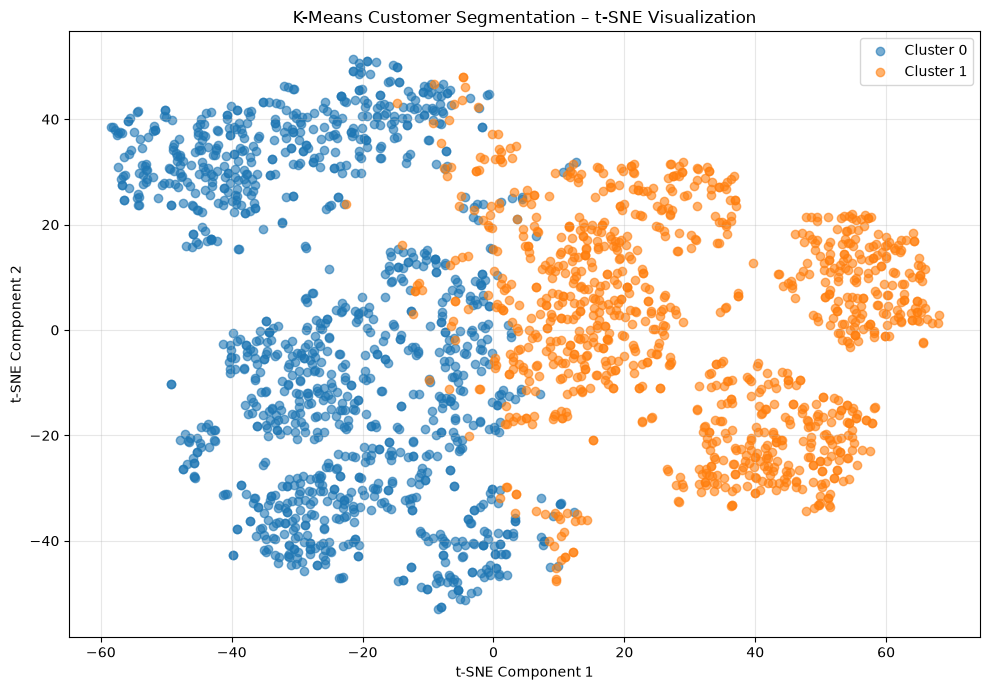

t-SNE visualization saved to:
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Visualizations\baseline_kmeans_tsne.png


In [90]:
# ============================================================
# t-SNE CLUSTER VISUALIZATION
# ============================================================

plt.figure(
    figsize=(10, 7)
)

for cluster in sorted(
    tsne_df["Cluster"].unique()
):

    cluster_data = tsne_df[
        tsne_df["Cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["TSNE1"],
        cluster_data["TSNE2"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.xlabel(
    "t-SNE Component 1"
)

plt.ylabel(
    "t-SNE Component 2"
)

plt.title(
    "K-Means Customer Segmentation – t-SNE Visualization"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

tsne_path = (
    "../Visualizations/"
    "baseline_kmeans_tsne.png"
)

plt.savefig(
    tsne_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "t-SNE visualization saved to:"
)

print(
    os.path.abspath(
        tsne_path
    )
)

In [91]:
# ============================================================
# SAVE CLUSTERED DATASET
# ============================================================

clustered_dataset_path = (
    "../Reports/"
    "baseline_kmeans_clustered_data.csv"
)

clustered_df.to_csv(
    clustered_dataset_path,
    index=False
)

print(
    "Clustered dataset saved to:"
)

print(
    os.path.abspath(
        clustered_dataset_path
    )
)

Clustered dataset saved to:
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Reports\baseline_kmeans_clustered_data.csv


In [92]:
# ============================================================
# SAVE BASELINE K-MEANS MODEL
# ============================================================

model_path = (
    "../Models/"
    "baseline_kmeans_model.pkl"
)

os.makedirs(
    "../Models",
    exist_ok=True
)

joblib.dump(
    kmeans_baseline,
    model_path
)

print(
    "K-Means model saved successfully."
)

print(
    os.path.abspath(
        model_path
    )
)

K-Means model saved successfully.
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Models\baseline_kmeans_model.pkl


In [93]:
# ============================================================
# BASELINE MODEL REPORT
# ============================================================

baseline_report = pd.DataFrame({
    "Metric": [
        "Number of Clusters",
        "Inertia_WCSS",
        "Silhouette_Score",
        "Davies_Bouldin_Index"
    ],
    "Value": [
        BASELINE_K,
        baseline_inertia,
        baseline_silhouette,
        baseline_db
    ]
})

baseline_report_path = (
    "../Reports/"
    "task_8_baseline_kmeans_report.csv"
)

baseline_report.to_csv(
    baseline_report_path,
    index=False
)

print(
    "Baseline evaluation report saved to:"
)

print(
    os.path.abspath(
        baseline_report_path
    )
)

display(
    baseline_report.round(4)
)

Baseline evaluation report saved to:
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Reports\task_8_baseline_kmeans_report.csv


,Metric,Value
0,Number of Clusters,2.0000
1,Inertia_WCSS,25631.5382
2,Silhouette_Score,0.2929
3,Davies_Bouldin_Index,1.3796


In [94]:
# ============================================================
# TASK 8 SUMMARY
# ============================================================

print("=" * 60)
print("TASK 8 – BASELINE K-MEANS SUMMARY")
print("=" * 60)

print(
    "\nAlgorithm: K-Means"
)

print(
    "Number of Clusters:",
    BASELINE_K
)

print(
    "\nCluster Sizes:"
)

display(
    cluster_size_summary.round(2)
)

print(
    "\nInertia / WCSS:",
    round(
        baseline_inertia,
        4
    )
)

print(
    "Silhouette Score:",
    round(
        baseline_silhouette,
        4
    )
)

print(
    "Davies-Bouldin Index:",
    round(
        baseline_db,
        4
    )
)

print(
    "\nPCA Visualization: PASS"
)

print(
    "t-SNE Visualization: PASS"
)

print(
    "Model Saved: PASS"
)

print(
    "\nTask 8 completed successfully."
)

TASK 8 – BASELINE K-MEANS SUMMARY

Algorithm: K-Means
Number of Clusters: 2

Cluster Sizes:


,Cluster,Customer_Count,Percentage
0,0,1207,53.96
1,1,1030,46.04



Inertia / WCSS: 25631.5382
Silhouette Score: 0.2929
Davies-Bouldin Index: 1.3796

PCA Visualization: PASS
t-SNE Visualization: PASS
Model Saved: PASS

Task 8 completed successfully.


# Task 9 – Hierarchical Clustering

## Objective

The objective of this task is to develop a second customer segmentation model using Agglomerative Hierarchical Clustering.

The model will initially use K = 2 clusters so that its performance can be fairly compared with the baseline K-Means model.

A dendrogram will be created to visualize the hierarchical structure of the customer data.

The model will be evaluated using Silhouette Score and Davies–Bouldin Index.

In [95]:
# ============================================================
# TASK 9 – HIERARCHICAL CLUSTERING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score
)
from scipy.cluster.hierarchy import (
    dendrogram,
    linkage
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [96]:
# ============================================================
# TASK 9.1 – LOAD SCALED DATA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

print("=" * 60)
print("TASK 9 – HIERARCHICAL CLUSTERING")
print("=" * 60)

scaled_file = "../Scaled_Data/standard_scaled_features.csv"

scaled_df = pd.read_csv(scaled_file)

print("\nDataset loaded successfully.")
print("Dataset Shape:", scaled_df.shape)

print("\nMissing Values:")
print(scaled_df.isnull().sum().sum())

print("\nData Types:")
print(scaled_df.dtypes.value_counts())

TASK 9 – HIERARCHICAL CLUSTERING

Dataset loaded successfully.
Dataset Shape: (2237, 17)

Missing Values:
0

Data Types:
float64    17
Name: count, dtype: int64


In [97]:
# ============================================================
# TASK 9.2 – AGGLOMERATIVE CLUSTERING
# ============================================================

HIERARCHICAL_K = 2

hierarchical_model = AgglomerativeClustering(
    n_clusters=HIERARCHICAL_K,
    linkage="ward"
)

hierarchical_labels = hierarchical_model.fit_predict(
    scaled_df
)

print("=" * 60)
print("AGGLOMERATIVE CLUSTERING")
print("=" * 60)

print("Number of Clusters:", HIERARCHICAL_K)
print("Linkage Method: Ward")
print("Model trained successfully.")

AGGLOMERATIVE CLUSTERING
Number of Clusters: 2
Linkage Method: Ward
Model trained successfully.


Why Ward linkage?

Ward linkage attempts to create clusters that minimize the increase in within-cluster variance.

It works particularly well when your numerical features have already been standardized—which we have done

In [98]:
# ============================================================
# TASK 9.3 – ADD CLUSTER LABELS
# ============================================================

hierarchical_df = scaled_df.copy()

hierarchical_df["Cluster"] = hierarchical_labels

print(
    hierarchical_df.head()
)

print("\nCluster labels added successfully.")

   numerical__Customer_Age  numerical__Income  numerical__Total_Children  \
0                 1.017296           0.300178                  -1.264618   
1                 1.273722          -0.263278                   1.395420   
2                 0.333495           0.943942                  -1.264618   
3                -1.290534          -1.204345                   0.065401   
4                -1.034108           0.307583                   0.065401   

   numerical__Family_Size  numerical__Total_Spending  \
0               -1.264618                   1.799304   
1                1.395420                  -0.990209   
2               -1.264618                   0.380303   
3                0.065401                  -0.942634   
4                0.065401                  -0.267442   

   numerical__Average_Spending_per_Purchase  numerical__Total_Purchases  \
0                                  1.193944                    1.312543   
1                                 -1.548990             

In [99]:
# ============================================================
# TASK 9.4 – CLUSTER SIZE
# ============================================================

hierarchical_cluster_sizes = (
    hierarchical_df["Cluster"]
    .value_counts()
    .sort_index()
)

hierarchical_percentages = (
    hierarchical_cluster_sizes
    / len(hierarchical_df)
    * 100
)

hierarchical_size_summary = pd.DataFrame({
    "Cluster": hierarchical_cluster_sizes.index,
    "Customer_Count": hierarchical_cluster_sizes.values,
    "Percentage": hierarchical_percentages.values
})

print("=" * 60)
print("HIERARCHICAL CLUSTER SIZES")
print("=" * 60)

display(
    hierarchical_size_summary.round(2)
)

HIERARCHICAL CLUSTER SIZES


,Cluster,Customer_Count,Percentage
0,0,1390,62.14
1,1,847,37.86


In [102]:
# ============================================================
# TASK 9.5 – MODEL EVALUATION
# ============================================================

hierarchical_silhouette = silhouette_score(
    scaled_df,
    hierarchical_labels
)

hierarchical_db = davies_bouldin_score(
    scaled_df,
    hierarchical_labels
)

print("=" * 60)
print("HIERARCHICAL CLUSTERING EVALUATION")
print("=" * 60)

print(
    "Number of Clusters:",
    HIERARCHICAL_K
)

print(
    "Silhouette Score:",
    round(
        hierarchical_silhouette,
        4
    )
)

print(
    "Davies-Bouldin Index:",
    round(
        hierarchical_db,
        4
    )
)

HIERARCHICAL CLUSTERING EVALUATION
Number of Clusters: 2
Silhouette Score: 0.2403
Davies-Bouldin Index: 1.4727


Silhouette Score → higher is better

Davies–Bouldin Index → lower is better

In [103]:
# ============================================================
# TASK 9.6 – K-MEANS VS HIERARCHICAL
# ============================================================

comparison_df = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Hierarchical"
    ],
    "Number_of_Clusters": [
        2,
        HIERARCHICAL_K
    ],
    "Silhouette_Score": [
        0.2929,
        hierarchical_silhouette
    ],
    "Davies_Bouldin_Index": [
        1.3796,
        hierarchical_db
    ]
})

print("=" * 60)
print("K-MEANS VS HIERARCHICAL CLUSTERING")
print("=" * 60)

display(
    comparison_df.round(4)
)

K-MEANS VS HIERARCHICAL CLUSTERING


,Algorithm,Number_of_Clusters,Silhouette_Score,Davies_Bouldin_Index
0,K-Means,2,0.2929,1.3796
1,Hierarchical,2,0.2403,1.4727


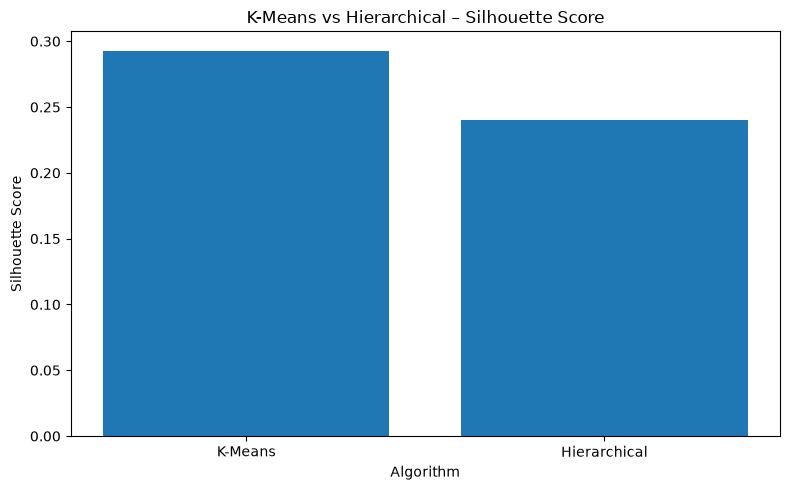

Comparison chart saved to:
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Visualizations\kmeans_vs_hierarchical_silhouette.png


In [104]:
# ============================================================
# TASK 9.7 – SILHOUETTE COMPARISON
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Algorithm"],
    comparison_df["Silhouette_Score"]
)

plt.xlabel("Algorithm")
plt.ylabel("Silhouette Score")
plt.title("K-Means vs Hierarchical – Silhouette Score")

plt.tight_layout()

comparison_path = (
    "../Visualizations/"
    "kmeans_vs_hierarchical_silhouette.png"
)

plt.savefig(
    comparison_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Comparison chart saved to:"
)

print(
    os.path.abspath(comparison_path)
)

Creating dendrogram...


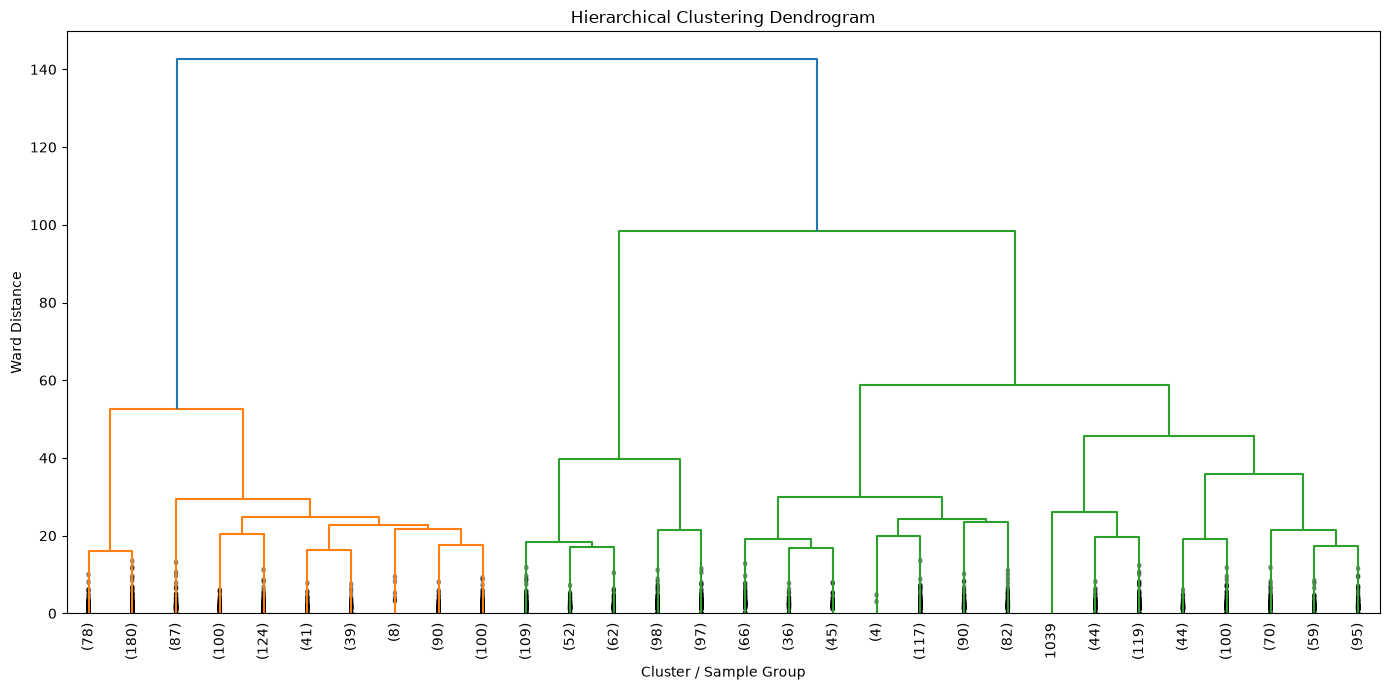

Dendrogram saved to:
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Visualizations\hierarchical_dendrogram.png


In [105]:
# ============================================================
# TASK 9.8 – DENDROGRAM
# ============================================================

print("Creating dendrogram...")

linkage_matrix = linkage(
    scaled_df,
    method="ward"
)

plt.figure(
    figsize=(14, 7)
)

dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)

plt.title(
    "Hierarchical Clustering Dendrogram"
)

plt.xlabel(
    "Cluster / Sample Group"
)

plt.ylabel(
    "Ward Distance"
)

plt.tight_layout()

dendrogram_path = (
    "../Visualizations/"
    "hierarchical_dendrogram.png"
)

plt.savefig(
    dendrogram_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Dendrogram saved to:"
)

print(
    os.path.abspath(dendrogram_path)
)

In [106]:
# ============================================================
# TASK 9.9 – SAVE MODEL
# ============================================================

os.makedirs(
    "../Models",
    exist_ok=True
)

hierarchical_model_path = (
    "../Models/"
    "hierarchical_clustering_model.pkl"
)

joblib.dump(
    hierarchical_model,
    hierarchical_model_path
)

print(
    "Hierarchical model saved successfully."
)

print(
    os.path.abspath(
        hierarchical_model_path
    )
)

Hierarchical model saved successfully.
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Models\hierarchical_clustering_model.pkl


In [107]:
# ============================================================
# TASK 9.10 – SAVE CLUSTERED DATA
# ============================================================

os.makedirs(
    "../Reports",
    exist_ok=True
)

hierarchical_data_path = (
    "../Reports/"
    "hierarchical_clustered_data.csv"
)

hierarchical_df.to_csv(
    hierarchical_data_path,
    index=False
)

print(
    "Hierarchical clustered dataset saved to:"
)

print(
    os.path.abspath(
        hierarchical_data_path
    )
)

Hierarchical clustered dataset saved to:
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Reports\hierarchical_clustered_data.csv


In [108]:
# ============================================================
# TASK 9.11 – SAVE EVALUATION REPORT
# ============================================================

hierarchical_report = pd.DataFrame({
    "Metric": [
        "Algorithm",
        "Number of Clusters",
        "Linkage",
        "Silhouette Score",
        "Davies-Bouldin Index"
    ],
    "Value": [
        "Agglomerative Clustering",
        HIERARCHICAL_K,
        "Ward",
        hierarchical_silhouette,
        hierarchical_db
    ]
})

hierarchical_report_path = (
    "../Reports/"
    "task_9_hierarchical_report.csv"
)

hierarchical_report.to_csv(
    hierarchical_report_path,
    index=False
)

print(
    "Hierarchical evaluation report saved to:"
)

print(
    os.path.abspath(
        hierarchical_report_path
    )
)

display(
    hierarchical_report
)

Hierarchical evaluation report saved to:
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Reports\task_9_hierarchical_report.csv


,Metric,Value
0,Algorithm,Agglomerative Clustering
1,Number of Clusters,2
2,Linkage,Ward
3,Silhouette Score,0.240259
4,Davies-Bouldin Index,1.47271


In [109]:
# ============================================================
# TASK 9 SUMMARY
# ============================================================

print("=" * 60)
print("TASK 9 – HIERARCHICAL CLUSTERING SUMMARY")
print("=" * 60)

print(
    "\nAlgorithm: Agglomerative Hierarchical Clustering"
)

print(
    "Number of Clusters:",
    HIERARCHICAL_K
)

print(
    "Linkage Method: Ward"
)

print(
    "\nCluster Sizes:"
)

display(
    hierarchical_size_summary.round(2)
)

print(
    "\nSilhouette Score:",
    round(
        hierarchical_silhouette,
        4
    )
)

print(
    "Davies-Bouldin Index:",
    round(
        hierarchical_db,
        4
    )
)

print(
    "\nDendrogram: PASS"
)

print(
    "Model Saved: PASS"
)

print(
    "Clustered Dataset Saved: PASS"
)

print(
    "\nTask 9 completed successfully."
)

TASK 9 – HIERARCHICAL CLUSTERING SUMMARY

Algorithm: Agglomerative Hierarchical Clustering
Number of Clusters: 2
Linkage Method: Ward

Cluster Sizes:


,Cluster,Customer_Count,Percentage
0,0,1390,62.14
1,1,847,37.86



Silhouette Score: 0.2403
Davies-Bouldin Index: 1.4727

Dendrogram: PASS
Model Saved: PASS
Clustered Dataset Saved: PASS

Task 9 completed successfully.


# Task 10 – Gaussian Mixture Model (GMM)

## Objective

The objective of this task is to develop a customer segmentation model using the Gaussian Mixture Model (GMM).

GMM is a probabilistic clustering algorithm that assumes the data is generated from a mixture of Gaussian probability distributions. Unlike K-Means, GMM provides probabilities that indicate how strongly each customer belongs to each cluster.

In this task, the same scaled customer features used in the previous clustering algorithms will be used.

## Activities

The following activities will be performed:

1. Load the scaled customer dataset.
2. Train a Gaussian Mixture Model.
3. Determine customer cluster assignments.
4. Calculate cluster sizes.
5. Calculate Silhouette Score.
6. Calculate Davies-Bouldin Index.
7. Calculate AIC (Akaike Information Criterion).
8. Calculate BIC (Bayesian Information Criterion).
9. Analyze cluster membership probabilities.
10. Visualize the clusters using PCA.
11. Save the trained GMM model.
12. Save the clustering results and evaluation report.

## Evaluation Metrics

The GMM model will be evaluated using:

- Silhouette Score
- Davies-Bouldin Index
- AIC
- BIC

For Silhouette Score, a higher value indicates better-defined clusters.

For Davies-Bouldin Index, a lower value indicates better cluster separation and compactness.

For AIC and BIC, lower values generally indicate a better-fitting model while penalizing unnecessary model complexity.

## Expected Outcome

The objective is to identify meaningful customer groups and compare the performance of GMM with the K-Means and Hierarchical Clustering models developed in previous tasks.

In [110]:
# ============================================================
# TASK 10 – GAUSSIAN MIXTURE MODEL (GMM)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib

from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score
)
from sklearn.decomposition import PCA

print("=" * 60)
print("TASK 10 – GAUSSIAN MIXTURE MODEL")
print("=" * 60)

print("Libraries imported successfully.")

TASK 10 – GAUSSIAN MIXTURE MODEL
Libraries imported successfully.


In [111]:
# ============================================================
# TASK 10.2 – LOAD SCALED DATA
# ============================================================

scaled_file = "../Scaled_Data/standard_scaled_features.csv"

scaled_df = pd.read_csv(
    scaled_file
)

print("=" * 60)
print("SCALED DATASET")
print("=" * 60)

print("Dataset Shape:", scaled_df.shape)

print(
    "Total Missing Values:",
    scaled_df.isnull().sum().sum()
)

print(
    "All Numerical:",
    all(
        np.issubdtype(
            dtype,
            np.number
        )
        for dtype in scaled_df.dtypes
    )
)

SCALED DATASET
Dataset Shape: (2237, 17)
Total Missing Values: 0
All Numerical: True


In [112]:
# ============================================================
# TASK 10.3 – TRAIN GMM
# ============================================================

GMM_K = 2

gmm_model = GaussianMixture(
    n_components=GMM_K,
    covariance_type="full",
    random_state=42,
    n_init=10
)

gmm_labels = gmm_model.fit_predict(
    scaled_df
)

print("=" * 60)
print("GMM MODEL TRAINED")
print("=" * 60)

print("Number of Components:", GMM_K)
print("Covariance Type: full")
print("Model trained successfully.")

GMM MODEL TRAINED
Number of Components: 2
Covariance Type: full
Model trained successfully.


In [113]:
# ============================================================
# TASK 10.4 – ADD GMM CLUSTER LABELS
# ============================================================

gmm_df = scaled_df.copy()

gmm_df["Cluster"] = gmm_labels

print(
    gmm_df.head()
)

print("\nGMM cluster labels added successfully.")

   numerical__Customer_Age  numerical__Income  numerical__Total_Children  \
0                 1.017296           0.300178                  -1.264618   
1                 1.273722          -0.263278                   1.395420   
2                 0.333495           0.943942                  -1.264618   
3                -1.290534          -1.204345                   0.065401   
4                -1.034108           0.307583                   0.065401   

   numerical__Family_Size  numerical__Total_Spending  \
0               -1.264618                   1.799304   
1                1.395420                  -0.990209   
2               -1.264618                   0.380303   
3                0.065401                  -0.942634   
4                0.065401                  -0.267442   

   numerical__Average_Spending_per_Purchase  numerical__Total_Purchases  \
0                                  1.193944                    1.312543   
1                                 -1.548990             

In [115]:
# ============================================================
# TASK 10.5 – GMM CLUSTER SIZE
# ============================================================

gmm_cluster_sizes = (
    gmm_df["Cluster"]
    .value_counts()
    .sort_index()
)

gmm_percentages = (
    gmm_cluster_sizes
    / len(gmm_df)
    * 100
)

gmm_size_summary = pd.DataFrame({
    "Cluster": gmm_cluster_sizes.index,
    "Customer_Count": gmm_cluster_sizes.values,
    "Percentage": gmm_percentages.values
})

print("=" * 60)
print("GMM CLUSTER SIZES")
print("=" * 60)

display(
    gmm_size_summary.round(2)
)

GMM CLUSTER SIZES


,Cluster,Customer_Count,Percentage
0,0,973,43.5
1,1,1264,56.5


In [116]:
# ============================================================
# TASK 10.6 – GMM EVALUATION
# ============================================================

gmm_silhouette = silhouette_score(
    scaled_df,
    gmm_labels
)

gmm_db = davies_bouldin_score(
    scaled_df,
    gmm_labels
)

print("=" * 60)
print("GMM EVALUATION")
print("=" * 60)

print(
    "Silhouette Score:",
    round(
        gmm_silhouette,
        4
    )
)

print(
    "Davies-Bouldin Index:",
    round(
        gmm_db,
        4
    )
)

GMM EVALUATION
Silhouette Score: 0.2736
Davies-Bouldin Index: 1.4008


In [117]:
# ============================================================
# TASK 10.7 – AIC AND BIC
# ============================================================

gmm_aic = gmm_model.aic(
    scaled_df
)

gmm_bic = gmm_model.bic(
    scaled_df
)

print("=" * 60)
print("GMM AIC AND BIC")
print("=" * 60)

print(
    "AIC:",
    round(
        gmm_aic,
        4
    )
)

print(
    "BIC:",
    round(
        gmm_bic,
        4
    )
)

GMM AIC AND BIC
AIC: 19432.8202
BIC: 21380.916


For GMM:

Lower AIC = better

Lower BIC = better

Higher Silhouette = better

Lower Davies–Bouldin = better

In [118]:
# ============================================================
# TASK 10.8 – CLUSTER PROBABILITIES
# ============================================================

gmm_probabilities = gmm_model.predict_proba(
    scaled_df
)

probability_df = pd.DataFrame(
    gmm_probabilities,
    columns=[
        f"Cluster_{i}_Probability"
        for i in range(GMM_K)
    ]
)

print("=" * 60)
print("GMM CLUSTER PROBABILITIES")
print("=" * 60)

display(
    probability_df.head(10).round(4)
)

GMM CLUSTER PROBABILITIES


,Cluster_0_Probability,Cluster_1_Probability
0,0.0,1.0
1,1.0,0.0
2,0.0,1.0
3,1.0,0.0
4,0.0,1.0
5,0.0,1.0
6,0.0,1.0
7,1.0,0.0
8,1.0,0.0
9,1.0,0.0


This is one of the most useful differences between GMM and K-Means.

GMM tells us how strongly each customer belongs to each cluster.

In [119]:
# ============================================================
# TASK 10.9 – AVERAGE CLUSTER PROBABILITY
# ============================================================

average_probabilities = probability_df.mean()

print("=" * 60)
print("AVERAGE CLUSTER PROBABILITIES")
print("=" * 60)

display(
    average_probabilities.round(4)
)

AVERAGE CLUSTER PROBABILITIES


Cluster_0_Probability    0.4348
Cluster_1_Probability    0.5652
dtype: float64

In [120]:
# ============================================================
# TASK 10.10 – PCA VISUALIZATION
# ============================================================

pca = PCA(
    n_components=2,
    random_state=42
)

pca_data = pca.fit_transform(
    scaled_df
)

gmm_pca_df = pd.DataFrame({
    "PC1": pca_data[:, 0],
    "PC2": pca_data[:, 1],
    "Cluster": gmm_labels
})

explained_variance = (
    pca.explained_variance_ratio_
    * 100
)

print("=" * 60)
print("GMM PCA")
print("=" * 60)

print(
    "PC1 Variance:",
    round(
        explained_variance[0],
        2
    ),
    "%"
)

print(
    "PC2 Variance:",
    round(
        explained_variance[1],
        2
    ),
    "%"
)

GMM PCA
PC1 Variance: 41.2 %
PC2 Variance: 17.44 %


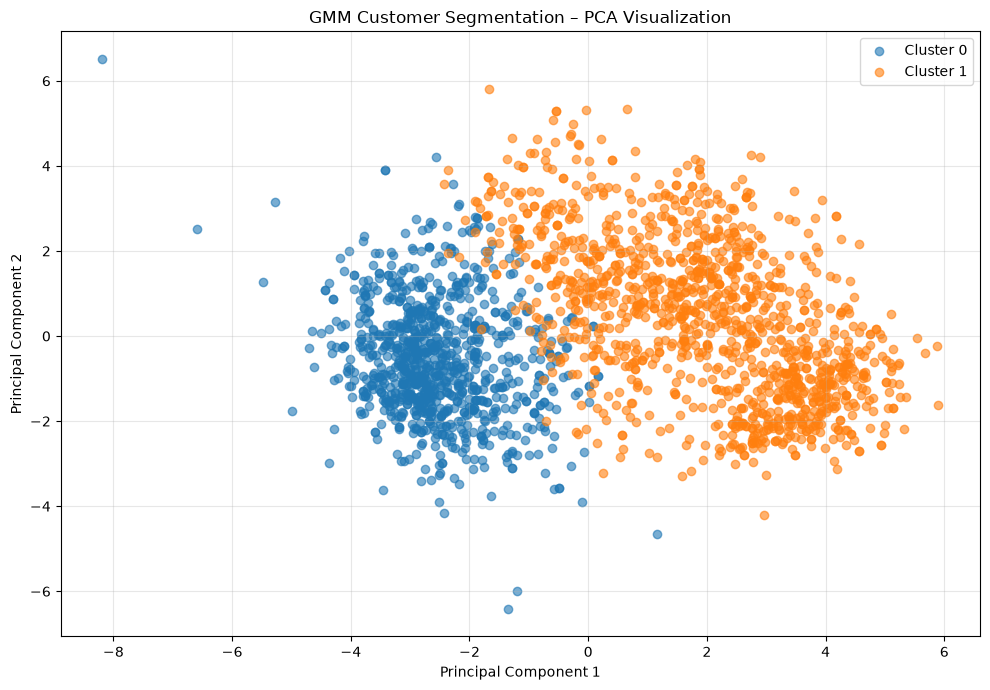

GMM PCA visualization saved to:
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Visualizations\gmm_pca_clusters.png


In [121]:
# ============================================================
# TASK 10.11 – GMM PCA CLUSTER VISUALIZATION
# ============================================================

plt.figure(
    figsize=(10, 7)
)

for cluster in sorted(
    gmm_pca_df["Cluster"].unique()
):

    cluster_data = gmm_pca_df[
        gmm_pca_df["Cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.title(
    "GMM Customer Segmentation – PCA Visualization"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

os.makedirs(
    "../Visualizations",
    exist_ok=True
)

gmm_pca_path = (
    "../Visualizations/"
    "gmm_pca_clusters.png"
)

plt.savefig(
    gmm_pca_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "GMM PCA visualization saved to:"
)

print(
    os.path.abspath(
        gmm_pca_path
    )
)

In [122]:
# ============================================================
# TASK 10.12 – SAVE GMM MODEL
# ============================================================

os.makedirs(
    "../Models",
    exist_ok=True
)

gmm_model_path = (
    "../Models/"
    "gmm_customer_segmentation.pkl"
)

joblib.dump(
    gmm_model,
    gmm_model_path
)

print(
    "GMM model saved successfully."
)

print(
    os.path.abspath(
        gmm_model_path
    )
)

GMM model saved successfully.
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Models\gmm_customer_segmentation.pkl


In [123]:
# ============================================================
# TASK 10.13 – SAVE GMM CLUSTERED DATA
# ============================================================

os.makedirs(
    "../Reports",
    exist_ok=True
)

gmm_clustered_path = (
    "../Reports/"
    "gmm_clustered_data.csv"
)

gmm_df.to_csv(
    gmm_clustered_path,
    index=False
)

print(
    "GMM clustered dataset saved to:"
)

print(
    os.path.abspath(
        gmm_clustered_path
    )
)

GMM clustered dataset saved to:
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Reports\gmm_clustered_data.csv


In [124]:
# ============================================================
# TASK 10.14 – GMM EVALUATION REPORT
# ============================================================

gmm_report = pd.DataFrame({
    "Metric": [
        "Algorithm",
        "Number of Components",
        "Silhouette Score",
        "Davies-Bouldin Index",
        "AIC",
        "BIC"
    ],
    "Value": [
        "Gaussian Mixture Model",
        GMM_K,
        gmm_silhouette,
        gmm_db,
        gmm_aic,
        gmm_bic
    ]
})

gmm_report_path = (
    "../Reports/"
    "task_10_gmm_evaluation_report.csv"
)

gmm_report.to_csv(
    gmm_report_path,
    index=False
)

print(
    "GMM evaluation report saved to:"
)

print(
    os.path.abspath(
        gmm_report_path
    )
)

display(
    gmm_report
)

GMM evaluation report saved to:
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Reports\task_10_gmm_evaluation_report.csv


,Metric,Value
0,Algorithm,Gaussian Mixture Model
1,Number of Components,2
2,Silhouette Score,0.273622
3,Davies-Bouldin Index,1.400799
4,AIC,19432.820168
5,BIC,21380.915986


In [125]:
# ============================================================
# TASK 10 SUMMARY
# ============================================================

print("=" * 60)
print("TASK 10 – GAUSSIAN MIXTURE MODEL SUMMARY")
print("=" * 60)

print(
    "\nAlgorithm: Gaussian Mixture Model"
)

print(
    "Number of Components:",
    GMM_K
)

print(
    "\nCluster Sizes:"
)

display(
    gmm_size_summary.round(2)
)

print(
    "\nSilhouette Score:",
    round(
        gmm_silhouette,
        4
    )
)

print(
    "Davies-Bouldin Index:",
    round(
        gmm_db,
        4
    )
)

print(
    "AIC:",
    round(
        gmm_aic,
        4
    )
)

print(
    "BIC:",
    round(
        gmm_bic,
        4
    )
)

print(
    "\nCluster Probability Analysis: PASS"
)

print(
    "PCA Visualization: PASS"
)

print(
    "Model Saved: PASS"
)

print(
    "Clustered Dataset Saved: PASS"
)

print(
    "\nTask 10 completed successfully."
)

TASK 10 – GAUSSIAN MIXTURE MODEL SUMMARY

Algorithm: Gaussian Mixture Model
Number of Components: 2

Cluster Sizes:


,Cluster,Customer_Count,Percentage
0,0,973,43.5
1,1,1264,56.5



Silhouette Score: 0.2736
Davies-Bouldin Index: 1.4008
AIC: 19432.8202
BIC: 21380.916

Cluster Probability Analysis: PASS
PCA Visualization: PASS
Model Saved: PASS
Clustered Dataset Saved: PASS

Task 10 completed successfully.


# Task 11 – DBSCAN Clustering

## Objective

The objective of this task is to apply the DBSCAN (Density-Based Spatial Clustering of Applications with Noise) algorithm to identify customer segments based on the density of customer behavior patterns.

Unlike K-Means, Hierarchical Clustering, and GMM, DBSCAN does not require the number of clusters to be specified in advance. It can also identify customers that do not belong to any meaningful cluster and classify them as noise or outliers.

## Activities

The following activities will be performed:

1. Load the scaled customer dataset from the previous task.
2. Apply the DBSCAN clustering algorithm.
3. Test different values of `eps`.
4. Test different values of `min_samples`.
5. Determine the number of clusters discovered by DBSCAN.
6. Identify the number of noise/outlier customers.
7. Calculate the Silhouette Score when valid clusters are available.
8. Calculate the Davies-Bouldin Index when applicable.
9. Compare different DBSCAN parameter combinations.
10. Identify the best DBSCAN configuration.
11. Analyze the detected noise/outlier customers.
12. Visualize the DBSCAN clusters using PCA.
13. Save the DBSCAN model and clustering results.
14. Prepare an outlier report.

## Important DBSCAN Parameters

### eps

`eps` represents the maximum distance between two samples for them to be considered neighbors.

A smaller `eps` creates stricter neighborhoods and may result in more noise points.

A larger `eps` creates larger neighborhoods and may combine more customers into clusters.

### min_samples

`min_samples` represents the minimum number of neighboring samples required for a point to be considered a core point.

A higher value makes DBSCAN more strict and may classify more observations as noise.

## Evaluation Metrics

DBSCAN will be evaluated using:

- Number of clusters
- Number of noise points
- Noise percentage
- Silhouette Score
- Davies-Bouldin Index (when applicable)

For the Silhouette Score:

- Higher values indicate better-defined clusters.

For the Davies-Bouldin Index:

- Lower values indicate better cluster separation and compactness.

## Noise / Outlier Analysis

DBSCAN labels noise observations with cluster label `-1`.

These customers will be analyzed separately because they may represent unusual or exceptional customer behavior.

## Expected Outcome

The objective is to determine whether DBSCAN can identify meaningful customer groups and unusual customer behavior that may not be detected effectively by K-Means, Hierarchical Clustering, or GMM.

The final DBSCAN results will later be compared with the other clustering algorithms in Task 12.

In [126]:
# ============================================================
# TASK 11.1 – IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib
import time

from sklearn.cluster import DBSCAN
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score
)
from sklearn.decomposition import PCA

print("=" * 60)
print("TASK 11 – DBSCAN CLUSTERING")
print("=" * 60)

print("Libraries imported successfully.")

TASK 11 – DBSCAN CLUSTERING
Libraries imported successfully.


In [127]:
# ============================================================
# TASK 11.2 – LOAD SCALED DATASET
# ============================================================

scaled_file = "../Scaled_Data/standard_scaled_features.csv"

scaled_df = pd.read_csv(
    scaled_file
)

print("=" * 60)
print("TASK 11.2 – SCALED DATASET VALIDATION")
print("=" * 60)

print("\nDataset loaded successfully.")

print(
    "\nDataset Shape:",
    scaled_df.shape
)

print(
    "\nTotal Missing Values:",
    scaled_df.isnull().sum().sum()
)

print(
    "\nData Types:"
)

print(
    scaled_df.dtypes.value_counts()
)

print(
    "\nAll Features Numerical:",
    all(
        np.issubdtype(
            dtype,
            np.number
        )
        for dtype in scaled_df.dtypes
    )
)

print(
    "\nFirst 5 Rows:"
)

display(
    scaled_df.head()
)

TASK 11.2 – SCALED DATASET VALIDATION

Dataset loaded successfully.

Dataset Shape: (2237, 17)

Total Missing Values: 0

Data Types:
float64    17
Name: count, dtype: int64

All Features Numerical: True

First 5 Rows:


,numerical__Customer_Age,numerical__Income,numerical__Total_Children,numerical__Family_Size,numerical__Total_Spending,numerical__Average_Spending_per_Purchase,numerical__Total_Purchases,numerical__NumWebPurchases,numerical__NumCatalogPurchases,numerical__NumStorePurchases,numerical__Total_Campaign_Acceptance,numerical__Digital_Engagement,numerical__NumWebVisitsMonth,numerical__Recency,numerical__Customer_Tenure_Years,numerical__Deal_Dependency,numerical__NumDealsPurchases
0,1.017296,0.300178,-1.264618,-1.264618,1.799304,1.193944,1.312543,1.280532,1.805202,-0.552077,-0.482053,1.560532,0.692882,0.307272,1.530038,-0.547897,0.652082
1,1.273722,-0.263278,1.395420,1.395420,-0.990209,-1.548990,-1.185961,-1.396839,-0.405715,-1.167421,-0.482053,-0.950312,-0.131574,-0.383584,-1.191484,1.359646,0.041655
2,0.333495,0.943942,-1.264618,-1.264618,0.380303,0.470482,1.034932,1.280532,0.120139,1.293956,-0.482053,0.723584,-0.543802,-0.798098,-0.206788,-1.090985,-0.818695
3,-1.290534,-1.204345,0.065401,0.065401,-0.942634,-1.255130,-0.908350,-0.675081,-1.304670,-0.552077,-0.482053,-0.392347,0.280654,-0.798098,-1.062830,0.550386,0.041655
4,-1.034108,0.307583,0.065401,0.065401,-0.267442,0.167739,0.202097,0.558774,0.493239,0.063267,-0.482053,0.165619,-0.131574,1.550812,-0.953970,0.671996,1.512432


In [128]:
# ============================================================
# TASK 11.3 – DBSCAN PARAMETER TUNING
# ============================================================

print("=" * 60)
print("TASK 11.3 – DBSCAN PARAMETER TUNING")
print("=" * 60)

# Parameter combinations to test
eps_values = [0.3, 0.5, 0.7, 0.9, 1.1, 1.3]
min_samples_values = [5, 10, 15, 20]

results = []

for eps in eps_values:

    for min_samples in min_samples_values:

        start_time = time.time()

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = dbscan.fit_predict(
            scaled_df
        )

        training_time = time.time() - start_time

        # Number of clusters excluding noise (-1)
        unique_labels = set(labels)

        n_clusters = len(
            unique_labels - {-1}
        )

        # Number of noise points
        n_noise = np.sum(
            labels == -1
        )

        noise_percentage = (
            n_noise / len(labels)
        ) * 100

        # Calculate metrics only if valid clustering exists
        non_noise_mask = labels != -1

        valid_labels = labels[
            non_noise_mask
        ]

        valid_data = scaled_df[
            non_noise_mask
        ]

        if (
            n_clusters >= 2
            and len(valid_labels) > n_clusters
        ):

            silhouette = silhouette_score(
                valid_data,
                valid_labels
            )

            davies_bouldin = davies_bouldin_score(
                valid_data,
                valid_labels
            )

        else:

            silhouette = np.nan
            davies_bouldin = np.nan

        results.append({
            "eps": eps,
            "min_samples": min_samples,
            "Number_of_Clusters": n_clusters,
            "Noise_Points": n_noise,
            "Noise_Percentage": noise_percentage,
            "Silhouette_Score": silhouette,
            "Davies_Bouldin_Index": davies_bouldin,
            "Training_Time_Seconds": training_time
        })


# Convert results to DataFrame
dbscan_results = pd.DataFrame(
    results
)

print("\nDBSCAN parameter testing completed.")

display(
    dbscan_results.round(4)
)

TASK 11.3 – DBSCAN PARAMETER TUNING

DBSCAN parameter testing completed.


,eps,min_samples,Number_of_Clusters,Noise_Points,Noise_Percentage,Silhouette_Score,Davies_Bouldin_Index,Training_Time_Seconds
0,0.3,5,0,2237,100.0000,NaN,NaN,0.1590
1,0.3,10,0,2237,100.0000,NaN,NaN,0.1787
2,0.3,15,0,2237,100.0000,NaN,NaN,0.1701
3,0.3,20,0,2237,100.0000,NaN,NaN,0.0658
4,0.5,5,0,2237,100.0000,NaN,NaN,0.0416
5,0.5,10,0,2237,100.0000,NaN,NaN,0.0402
6,0.5,15,0,2237,100.0000,NaN,NaN,0.0517
7,0.5,20,0,2237,100.0000,NaN,NaN,0.0452
8,0.7,5,1,2232,99.7765,NaN,NaN,0.1074
9,0.7,10,0,2237,100.0000,NaN,NaN,0.0703


In [129]:
# ============================================================
# TASK 11.4 – COMPARE DBSCAN PARAMETER COMBINATIONS
# ============================================================

print("=" * 60)
print("TASK 11.4 – DBSCAN PARAMETER COMPARISON")
print("=" * 60)

# Keep only configurations where at least 2 clusters were found
# and Silhouette Score could be calculated.
valid_results = dbscan_results[
    dbscan_results["Silhouette_Score"].notna()
].copy()

print("\nValid DBSCAN Configurations:")

if len(valid_results) == 0:

    print("No valid DBSCAN configurations found.")
    print("Consider testing larger eps values.")

else:

    # Rank by:
    # 1. Higher Silhouette Score = better
    # 2. Lower Davies-Bouldin Index = better
    # 3. Lower Noise Percentage = better

    valid_results = valid_results.sort_values(
        by=[
            "Silhouette_Score",
            "Davies_Bouldin_Index",
            "Noise_Percentage"
        ],
        ascending=[
            False,
            True,
            True
        ]
    ).reset_index(drop=True)

    # Add ranking
    valid_results.insert(
        0,
        "Rank",
        range(1, len(valid_results) + 1)
    )

    display(
        valid_results.round(4)
    )

    print("\nBest Configuration Based on Evaluation Metrics:")

    best_row = valid_results.iloc[0]

    print(
        "\neps:",
        best_row["eps"]
    )

    print(
        "min_samples:",
        int(best_row["min_samples"])
    )

    print(
        "Number of Clusters:",
        int(best_row["Number_of_Clusters"])
    )

    print(
        "Noise Points:",
        int(best_row["Noise_Points"])
    )

    print(
        "Noise Percentage:",
        round(
            best_row["Noise_Percentage"],
            2
        ),
        "%"
    )

    print(
        "Silhouette Score:",
        round(
            best_row["Silhouette_Score"],
            4
        )
    )

    print(
        "Davies-Bouldin Index:",
        round(
            best_row["Davies_Bouldin_Index"],
            4
        )
    )

    print(
        "Training Time:",
        round(
            best_row["Training_Time_Seconds"],
            4
        ),
        "seconds"
    )

TASK 11.4 – DBSCAN PARAMETER COMPARISON

Valid DBSCAN Configurations:


,Rank,eps,min_samples,Number_of_Clusters,Noise_Points,Noise_Percentage,Silhouette_Score,Davies_Bouldin_Index,Training_Time_Seconds
0,1,0.9,5,7,2180,97.4519,0.4359,0.8276,0.0687
1,2,1.1,10,2,2158,96.4685,0.2307,1.3066,0.0893
2,3,1.1,5,11,2046,91.4618,0.2014,1.1368,0.1382
3,4,1.3,15,2,2104,94.0545,0.1961,1.7773,0.2157
4,5,1.3,10,4,2000,89.4055,0.1938,1.6056,0.0980
5,6,1.3,5,25,1731,77.3804,0.0791,1.0713,0.0638



Best Configuration Based on Evaluation Metrics:

eps: 0.9
min_samples: 5
Number of Clusters: 7
Noise Points: 2180
Noise Percentage: 97.45 %
Silhouette Score: 0.4359
Davies-Bouldin Index: 0.8276
Training Time: 0.0687 seconds


In [131]:
# ============================================================
# SAVE DBSCAN PARAMETER COMPARISON
# ============================================================

os.makedirs(
    "../Reports",
    exist_ok=True
)

comparison_path = (
    "../Reports/"
    "dbscan_parameter_comparison.csv"
)

valid_results.to_csv(
    comparison_path,
    index=False
)

print(
    "\nParameter comparison saved to:"
)

print(
    os.path.abspath(
        comparison_path
    )
)


Parameter comparison saved to:
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Reports\dbscan_parameter_comparison.csv


In [132]:
# ============================================================
# TASK 11.5 – SELECT BEST DBSCAN CONFIGURATION
# ============================================================

print("=" * 60)
print("TASK 11.5 – BEST DBSCAN CONFIGURATION")
print("=" * 60)

# Define a practical maximum noise threshold.
# We do not want DBSCAN to classify almost all customers as noise.

MAX_NOISE_PERCENTAGE = 50

practical_results = valid_results[
    valid_results["Noise_Percentage"]
    <= MAX_NOISE_PERCENTAGE
].copy()

print(
    "\nMaximum Accepted Noise Percentage:",
    MAX_NOISE_PERCENTAGE,
    "%"
)

if len(practical_results) == 0:

    print(
        "\nWARNING: No configuration produced "
        "a practical noise percentage."
    )

    print(
        "DBSCAN may not be suitable for this dataset "
        "with the current parameter range."
    )

else:

    # Rank practical configurations.
    practical_results = practical_results.sort_values(
        by=[
            "Silhouette_Score",
            "Davies_Bouldin_Index"
        ],
        ascending=[
            False,
            True
        ]
    ).reset_index(drop=True)

    practical_results.insert(
        0,
        "Rank",
        range(1, len(practical_results) + 1)
    )

    print(
        "\nPractical DBSCAN Configurations:"
    )

    display(
        practical_results.round(4)
    )

    # Select the best practical configuration
    best_dbscan_row = practical_results.iloc[0]

    BEST_EPS = float(
        best_dbscan_row["eps"]
    )

    BEST_MIN_SAMPLES = int(
        best_dbscan_row["min_samples"]
    )

    print(
        "\nSelected DBSCAN Configuration:"
    )

    print(
        "eps:",
        BEST_EPS
    )

    print(
        "min_samples:",
        BEST_MIN_SAMPLES
    )

    print(
        "Number of Clusters:",
        int(
            best_dbscan_row[
                "Number_of_Clusters"
            ]
        )
    )

    print(
        "Noise Points:",
        int(
            best_dbscan_row[
                "Noise_Points"
            ]
        )
    )

    print(
        "Noise Percentage:",
        round(
            best_dbscan_row[
                "Noise_Percentage"
            ],
            2
        ),
        "%"
    )

    print(
        "Silhouette Score:",
        round(
            best_dbscan_row[
                "Silhouette_Score"
            ],
            4
        )
    )

    print(
        "Davies-Bouldin Index:",
        round(
            best_dbscan_row[
                "Davies_Bouldin_Index"
            ],
            4
        )
    )

    print(
        "\nSelection Status: PASS"
    )

TASK 11.5 – BEST DBSCAN CONFIGURATION

Maximum Accepted Noise Percentage: 50 %

DBSCAN may not be suitable for this dataset with the current parameter range.


In [133]:
# ============================================================
# TASK 11.5B – EXPANDED DBSCAN PARAMETER SEARCH
# ============================================================

print("=" * 60)
print("TASK 11.5B – EXPANDED DBSCAN PARAMETER SEARCH")
print("=" * 60)

# Broader parameter range
eps_values_expanded = [
    1.5,
    2.0,
    2.5,
    3.0,
    3.5,
    4.0
]

min_samples_values_expanded = [
    5,
    10,
    15,
    20
]

expanded_results = []

for eps in eps_values_expanded:

    for min_samples in min_samples_values_expanded:

        start_time = time.time()

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = dbscan.fit_predict(
            scaled_df
        )

        training_time = (
            time.time() - start_time
        )

        # Count clusters excluding noise
        unique_labels = set(labels)

        n_clusters = len(
            unique_labels - {-1}
        )

        # Count noise
        n_noise = np.sum(
            labels == -1
        )

        noise_percentage = (
            n_noise / len(labels)
        ) * 100

        # Calculate evaluation metrics
        non_noise_mask = labels != -1

        valid_labels = labels[
            non_noise_mask
        ]

        valid_data = scaled_df[
            non_noise_mask
        ]

        if (
            n_clusters >= 2
            and len(valid_labels) > n_clusters
        ):

            silhouette = silhouette_score(
                valid_data,
                valid_labels
            )

            davies_bouldin = davies_bouldin_score(
                valid_data,
                valid_labels
            )

        else:

            silhouette = np.nan
            davies_bouldin = np.nan

        expanded_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "Number_of_Clusters": n_clusters,
            "Noise_Points": n_noise,
            "Noise_Percentage": noise_percentage,
            "Silhouette_Score": silhouette,
            "Davies_Bouldin_Index": davies_bouldin,
            "Training_Time_Seconds": training_time
        })


expanded_dbscan_results = pd.DataFrame(
    expanded_results
)

print(
    "\nExpanded parameter search completed."
)

display(
    expanded_dbscan_results.round(4)
)

TASK 11.5B – EXPANDED DBSCAN PARAMETER SEARCH

Expanded parameter search completed.


,eps,min_samples,Number_of_Clusters,Noise_Points,Noise_Percentage,Silhouette_Score,Davies_Bouldin_Index,Training_Time_Seconds
0,1.5,5,32,1204,53.8221,-0.1135,1.2297,0.0899
1,1.5,10,4,1706,76.2629,0.2177,1.3026,0.0840
2,1.5,15,2,1886,84.3093,0.2407,1.4920,0.0567
3,1.5,20,1,1965,87.8409,NaN,NaN,0.0800
4,2.0,5,11,368,16.4506,-0.1806,1.5332,0.0909
5,2.0,10,4,603,26.9557,-0.0102,1.7273,0.0480
6,2.0,15,5,748,33.4376,0.0383,1.6437,0.0750
7,2.0,20,3,913,40.8136,0.2675,1.5670,0.0849
8,2.5,5,1,80,3.5762,NaN,NaN,0.0832
9,2.5,10,1,115,5.1408,NaN,NaN,0.0836


In [134]:
# ============================================================
# TASK 11.5C – IDENTIFY PRACTICAL DBSCAN CONFIGURATIONS
# ============================================================

print("=" * 60)
print("TASK 11.5C – PRACTICAL DBSCAN CONFIGURATIONS")
print("=" * 60)

expanded_valid_results = (
    expanded_dbscan_results[
        expanded_dbscan_results[
            "Silhouette_Score"
        ].notna()
    ]
    .copy()
)

# Accept configurations with <= 50% noise
expanded_practical_results = (
    expanded_valid_results[
        expanded_valid_results[
            "Noise_Percentage"
        ] <= 50
    ]
    .copy()
)

if len(expanded_practical_results) == 0:

    print(
        "No practical configuration found "
        "with noise <= 50%."
    )

else:

    expanded_practical_results = (
        expanded_practical_results
        .sort_values(
            by=[
                "Silhouette_Score",
                "Davies_Bouldin_Index"
            ],
            ascending=[
                False,
                True
            ]
        )
        .reset_index(drop=True)
    )

    expanded_practical_results.insert(
        0,
        "Rank",
        range(
            1,
            len(expanded_practical_results) + 1
        )
    )

    display(
        expanded_practical_results.round(4)
    )

    best_dbscan_row = (
        expanded_practical_results.iloc[0]
    )

    BEST_EPS = float(
        best_dbscan_row["eps"]
    )

    BEST_MIN_SAMPLES = int(
        best_dbscan_row["min_samples"]
    )

    print(
        "\nBest Practical Configuration:"
    )

    print(
        "eps:",
        BEST_EPS
    )

    print(
        "min_samples:",
        BEST_MIN_SAMPLES
    )

    print(
        "Clusters:",
        int(
            best_dbscan_row[
                "Number_of_Clusters"
            ]
        )
    )

    print(
        "Noise Points:",
        int(
            best_dbscan_row[
                "Noise_Points"
            ]
        )
    )

    print(
        "Noise Percentage:",
        round(
            best_dbscan_row[
                "Noise_Percentage"
            ],
            2
        ),
        "%"
    )

    print(
        "Silhouette Score:",
        round(
            best_dbscan_row[
                "Silhouette_Score"
            ],
            4
        )
    )

    print(
        "Davies-Bouldin Index:",
        round(
            best_dbscan_row[
                "Davies_Bouldin_Index"
            ],
            4
        )
    )

TASK 11.5C – PRACTICAL DBSCAN CONFIGURATIONS


,Rank,eps,min_samples,Number_of_Clusters,Noise_Points,Noise_Percentage,Silhouette_Score,Davies_Bouldin_Index,Training_Time_Seconds
0,1,2.0,20,3,913,40.8136,0.2675,1.5670,0.0849
1,2,2.0,15,5,748,33.4376,0.0383,1.6437,0.0750
2,3,2.0,10,4,603,26.9557,-0.0102,1.7273,0.0480
3,4,2.0,5,11,368,16.4506,-0.1806,1.5332,0.0909



Best Practical Configuration:
eps: 2.0
min_samples: 20
Clusters: 3
Noise Points: 913
Noise Percentage: 40.81 %
Silhouette Score: 0.2675
Davies-Bouldin Index: 1.567


In [135]:
# ============================================================
# TASK 11.6 – TRAIN FINAL DBSCAN MODEL
# ============================================================

print("=" * 60)
print("TASK 11.6 – FINAL DBSCAN MODEL")
print("=" * 60)

# Selected parameters from expanded search
BEST_EPS = 2.0
BEST_MIN_SAMPLES = 20

print("\nSelected Parameters:")
print("eps:", BEST_EPS)
print("min_samples:", BEST_MIN_SAMPLES)

# Start training timer
start_time = time.time()

# Create final DBSCAN model
final_dbscan = DBSCAN(
    eps=BEST_EPS,
    min_samples=BEST_MIN_SAMPLES
)

# Train and generate cluster labels
dbscan_labels = final_dbscan.fit_predict(
    scaled_df
)

training_time = time.time() - start_time

# Add cluster labels to a copy of the dataset
dbscan_clustered_df = scaled_df.copy()

dbscan_clustered_df[
    "DBSCAN_Cluster"
] = dbscan_labels

# Calculate cluster information
unique_clusters = sorted(
    set(dbscan_labels)
)

n_clusters = len(
    set(dbscan_labels) - {-1}
)

n_noise = np.sum(
    dbscan_labels == -1
)

noise_percentage = (
    n_noise / len(dbscan_labels)
) * 100

print("\nFinal DBSCAN Model Trained Successfully.")

print(
    "\nNumber of Clusters:",
    n_clusters
)

print(
    "Noise Points:",
    n_noise
)

print(
    "Noise Percentage:",
    round(
        noise_percentage,
        2
    ),
    "%"
)

print(
    "Training Time:",
    round(
        training_time,
        4
    ),
    "seconds"
)

print(
    "\nCluster Labels:",
    unique_clusters
)

print(
    "\nCluster Counts:"
)

print(
    dbscan_clustered_df[
        "DBSCAN_Cluster"
    ].value_counts().sort_index()
)

TASK 11.6 – FINAL DBSCAN MODEL

Selected Parameters:
eps: 2.0
min_samples: 20

Final DBSCAN Model Trained Successfully.

Number of Clusters: 3
Noise Points: 913
Noise Percentage: 40.81 %
Training Time: 0.1079 seconds

Cluster Labels: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2)]

Cluster Counts:
DBSCAN_Cluster
-1     913
 0    1117
 1     156
 2      51
Name: count, dtype: int64


In [136]:
# ============================================================
# TASK 11.7 – FINAL DBSCAN EVALUATION
# ============================================================

print("=" * 60)
print("TASK 11.7 – FINAL DBSCAN EVALUATION")
print("=" * 60)

# Separate noise points from actual clusters
non_noise_mask = dbscan_labels != -1

evaluation_data = scaled_df[
    non_noise_mask
]

evaluation_labels = dbscan_labels[
    non_noise_mask
]

# Calculate number of actual clusters
n_clusters = len(
    set(evaluation_labels)
)

# Calculate evaluation metrics
if n_clusters >= 2:

    final_silhouette = silhouette_score(
        evaluation_data,
        evaluation_labels
    )

    final_davies_bouldin = davies_bouldin_score(
        evaluation_data,
        evaluation_labels
    )

else:

    final_silhouette = np.nan
    final_davies_bouldin = np.nan


# Calculate noise information
n_noise = np.sum(
    dbscan_labels == -1
)

noise_percentage = (
    n_noise / len(dbscan_labels)
) * 100


# Display results
print("\nEvaluation Results")
print("-" * 60)

print(
    "Number of Clusters:",
    n_clusters
)

print(
    "Noise Points:",
    n_noise
)

print(
    "Noise Percentage:",
    round(
        noise_percentage,
        2
    ),
    "%"
)

print(
    "Silhouette Score:",
    round(
        final_silhouette,
        4
    )
)

print(
    "Davies-Bouldin Index:",
    round(
        final_davies_bouldin,
        4
    )
)

print(
    "\nEvaluation completed successfully."
)

TASK 11.7 – FINAL DBSCAN EVALUATION

Evaluation Results
------------------------------------------------------------
Number of Clusters: 3
Noise Points: 913
Noise Percentage: 40.81 %
Silhouette Score: 0.2675
Davies-Bouldin Index: 1.567

Evaluation completed successfully.


In [137]:
# ============================================================
# TASK 11.8 – NOISE / OUTLIER ANALYSIS
# ============================================================

print("=" * 60)
print("TASK 11.8 – DBSCAN NOISE / OUTLIER ANALYSIS")
print("=" * 60)

# Identify noise customers
noise_mask = dbscan_clustered_df[
    "DBSCAN_Cluster"
] == -1

noise_df = dbscan_clustered_df[
    noise_mask
].copy()

# Identify clustered customers
clustered_df = dbscan_clustered_df[
    ~noise_mask
].copy()

# Count noise and clustered customers
noise_count = len(
    noise_df
)

clustered_count = len(
    clustered_df
)

total_customers = len(
    dbscan_clustered_df
)

noise_percentage = (
    noise_count / total_customers
) * 100

clustered_percentage = (
    clustered_count / total_customers
) * 100


# ------------------------------------------------------------
# DISPLAY SUMMARY
# ------------------------------------------------------------

print("\nDBSCAN Customer Classification")
print("-" * 60)

print(
    "Total Customers:",
    total_customers
)

print(
    "Clustered Customers:",
    clustered_count
)

print(
    "Clustered Percentage:",
    round(
        clustered_percentage,
        2
    ),
    "%"
)

print(
    "Noise / Outlier Customers:",
    noise_count
)

print(
    "Noise Percentage:",
    round(
        noise_percentage,
        2
    ),
    "%"
)


# ------------------------------------------------------------
# NOISE VS CLUSTERED SUMMARY TABLE
# ------------------------------------------------------------

outlier_summary = pd.DataFrame({
    "Category": [
        "Clustered Customers",
        "Noise / Outlier Customers"
    ],
    "Customer_Count": [
        clustered_count,
        noise_count
    ],
    "Percentage": [
        clustered_percentage,
        noise_percentage
    ]
})

print("\nCustomer Classification Summary:")

display(
    outlier_summary.round(2)
)


# ------------------------------------------------------------
# CLUSTER DISTRIBUTION
# ------------------------------------------------------------

print("\nDBSCAN Cluster Distribution:")

cluster_distribution = (
    dbscan_clustered_df[
        "DBSCAN_Cluster"
    ]
    .value_counts()
    .sort_index()
)

display(
    cluster_distribution
)


# ------------------------------------------------------------
# OUTLIER STATUS
# ------------------------------------------------------------

print("\nOutlier Analysis Status:")

if noise_count > 0:

    print(
        "PASS – DBSCAN identified",
        noise_count,
        "noise/outlier customers."
    )

else:

    print(
        "CHECK – No noise/outlier customers detected."
    )

TASK 11.8 – DBSCAN NOISE / OUTLIER ANALYSIS

DBSCAN Customer Classification
------------------------------------------------------------
Total Customers: 2237
Clustered Customers: 1324
Clustered Percentage: 59.19 %
Noise / Outlier Customers: 913
Noise Percentage: 40.81 %

Customer Classification Summary:


,Category,Customer_Count,Percentage
0,Clustered Customers,1324,59.19
1,Noise / Outlier Customers,913,40.81



DBSCAN Cluster Distribution:


DBSCAN_Cluster
-1     913
 0    1117
 1     156
 2      51
Name: count, dtype: int64


Outlier Analysis Status:
PASS – DBSCAN identified 913 noise/outlier customers.


TASK 11.9 – DBSCAN PCA VISUALIZATION


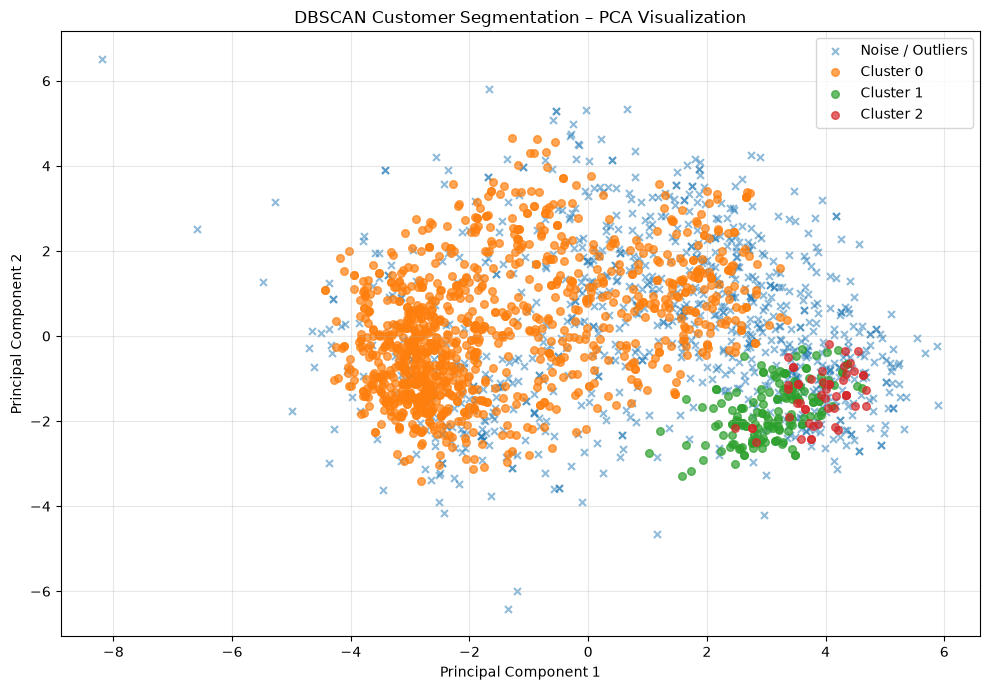


PCA Explained Variance:
PCA1: 41.2 %
PCA2: 17.44 %
Total Explained Variance: 58.64 %

PCA Visualization: PASS


In [138]:
# ============================================================
# TASK 11.9 – DBSCAN PCA VISUALIZATION
# ============================================================

print("=" * 60)
print("TASK 11.9 – DBSCAN PCA VISUALIZATION")
print("=" * 60)

# Apply PCA to reduce the 17-dimensional dataset to 2 dimensions
pca = PCA(
    n_components=2,
    random_state=42
)

pca_data = pca.fit_transform(
    scaled_df
)

# Create PCA DataFrame
pca_df = pd.DataFrame(
    pca_data,
    columns=[
        "PCA1",
        "PCA2"
    ]
)

# Add DBSCAN cluster labels
pca_df[
    "DBSCAN_Cluster"
] = dbscan_labels


# ------------------------------------------------------------
# CREATE VISUALIZATION
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 7)
)

# Plot each cluster separately
unique_labels = sorted(
    set(dbscan_labels)
)

for label in unique_labels:

    cluster_mask = (
        dbscan_labels == label
    )

    if label == -1:

        label_name = "Noise / Outliers"

        plt.scatter(
            pca_df.loc[
                cluster_mask,
                "PCA1"
            ],
            pca_df.loc[
                cluster_mask,
                "PCA2"
            ],
            label=label_name,
            alpha=0.5,
            s=25,
            marker="x"
        )

    else:

        label_name = (
            f"Cluster {label}"
        )

        plt.scatter(
            pca_df.loc[
                cluster_mask,
                "PCA1"
            ],
            pca_df.loc[
                cluster_mask,
                "PCA2"
            ],
            label=label_name,
            alpha=0.7,
            s=30
        )


plt.title(
    "DBSCAN Customer Segmentation – PCA Visualization"
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# EXPLAINED VARIANCE
# ------------------------------------------------------------

print("\nPCA Explained Variance:")

print(
    "PCA1:",
    round(
        pca.explained_variance_ratio_[0] * 100,
        2
    ),
    "%"
)

print(
    "PCA2:",
    round(
        pca.explained_variance_ratio_[1] * 100,
        2
    ),
    "%"
)

print(
    "Total Explained Variance:",
    round(
        pca.explained_variance_ratio_.sum() * 100,
        2
    ),
    "%"
)

print(
    "\nPCA Visualization: PASS"
)

In [139]:
# ============================================================
# TASK 11.10 – SAVE DBSCAN MODEL
# ============================================================

print("=" * 60)
print("TASK 11.10 – SAVE DBSCAN MODEL")
print("=" * 60)

# Create Models folder if it does not already exist
models_folder = "../models"

os.makedirs(
    models_folder,
    exist_ok=True
)

# Model file path
model_path = os.path.join(
    models_folder,
    "dbscan_model.pkl"
)

# Save the trained DBSCAN model
joblib.dump(
    final_dbscan,
    model_path
)

print(
    "\nDBSCAN model saved successfully."
)

print(
    "Model Location:"
)

print(
    os.path.abspath(model_path)
)

# Verify that the model file exists
if os.path.exists(model_path):

    print(
        "\nModel Saved: PASS"
    )

else:

    print(
        "\nModel Saved: FAIL"
    )

TASK 11.10 – SAVE DBSCAN MODEL

DBSCAN model saved successfully.
Model Location:
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\models\dbscan_model.pkl

Model Saved: PASS


In [140]:
# ============================================================
# TASK 11.11 – SAVE DBSCAN CLUSTERED DATASET
# ============================================================

print("=" * 60)
print("TASK 11.11 – SAVE DBSCAN CLUSTERED DATASET")
print("=" * 60)

# Create output folder
output_folder = "../Results"

os.makedirs(
    output_folder,
    exist_ok=True
)

# Define output file
clustered_data_path = os.path.join(
    output_folder,
    "dbscan_clustered_customers.csv"
)

# Save clustered dataset
dbscan_clustered_df.to_csv(
    clustered_data_path,
    index=False
)

print(
    "\nDBSCAN clustered dataset saved successfully."
)

print(
    "Dataset Location:"
)

print(
    os.path.abspath(
        clustered_data_path
    )
)

# Verify file
if os.path.exists(
    clustered_data_path
):

    print(
        "\nClustered Dataset Saved: PASS"
    )

else:

    print(
        "\nClustered Dataset Saved: FAIL"
    )

# Display shape
print(
    "\nSaved Dataset Shape:",
    dbscan_clustered_df.shape
)

# Display first five rows
print(
    "\nDataset Preview:"
)

display(
    dbscan_clustered_df.head()
)

TASK 11.11 – SAVE DBSCAN CLUSTERED DATASET

DBSCAN clustered dataset saved successfully.
Dataset Location:
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Results\dbscan_clustered_customers.csv

Clustered Dataset Saved: PASS

Saved Dataset Shape: (2237, 18)

Dataset Preview:


,numerical__Customer_Age,numerical__Income,numerical__Total_Children,numerical__Family_Size,numerical__Total_Spending,numerical__Average_Spending_per_Purchase,numerical__Total_Purchases,numerical__NumWebPurchases,numerical__NumCatalogPurchases,numerical__NumStorePurchases,numerical__Total_Campaign_Acceptance,numerical__Digital_Engagement,numerical__NumWebVisitsMonth,numerical__Recency,numerical__Customer_Tenure_Years,numerical__Deal_Dependency,numerical__NumDealsPurchases,DBSCAN_Cluster
0,1.017296,0.300178,-1.264618,-1.264618,1.799304,1.193944,1.312543,1.280532,1.805202,-0.552077,-0.482053,1.560532,0.692882,0.307272,1.530038,-0.547897,0.652082,-1
1,1.273722,-0.263278,1.395420,1.395420,-0.990209,-1.548990,-1.185961,-1.396839,-0.405715,-1.167421,-0.482053,-0.950312,-0.131574,-0.383584,-1.191484,1.359646,0.041655,0
2,0.333495,0.943942,-1.264618,-1.264618,0.380303,0.470482,1.034932,1.280532,0.120139,1.293956,-0.482053,0.723584,-0.543802,-0.798098,-0.206788,-1.090985,-0.818695,-1
3,-1.290534,-1.204345,0.065401,0.065401,-0.942634,-1.255130,-0.908350,-0.675081,-1.304670,-0.552077,-0.482053,-0.392347,0.280654,-0.798098,-1.062830,0.550386,0.041655,0
4,-1.034108,0.307583,0.065401,0.065401,-0.267442,0.167739,0.202097,0.558774,0.493239,0.063267,-0.482053,0.165619,-0.131574,1.550812,-0.953970,0.671996,1.512432,0


In [141]:
# ============================================================
# TASK 11.12 – SAVE DBSCAN OUTLIER REPORT
# ============================================================

print("=" * 60)
print("TASK 11.12 – DBSCAN OUTLIER REPORT")
print("=" * 60)

# Create Reports folder
reports_folder = "../Reports"

os.makedirs(
    reports_folder,
    exist_ok=True
)

# ------------------------------------------------------------
# EXTRACT NOISE / OUTLIER CUSTOMERS
# ------------------------------------------------------------

noise_mask = (
    dbscan_clustered_df["DBSCAN_Cluster"] == -1
)

outlier_df = dbscan_clustered_df[
    noise_mask
].copy()

# ------------------------------------------------------------
# SAVE OUTLIER REPORT
# ------------------------------------------------------------

outlier_report_path = os.path.join(
    reports_folder,
    "dbscan_outlier_report.csv"
)

outlier_df.to_csv(
    outlier_report_path,
    index=False
)

# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

total_customers = len(
    dbscan_clustered_df
)

outlier_count = len(
    outlier_df
)

outlier_percentage = (
    outlier_count / total_customers
) * 100

print("\nDBSCAN Outlier Analysis")
print("-" * 60)

print(
    "Total Customers:",
    total_customers
)

print(
    "Outlier Customers:",
    outlier_count
)

print(
    "Outlier Percentage:",
    round(
        outlier_percentage,
        2
    ),
    "%"
)

print(
    "\nOutlier Report Location:"
)

print(
    os.path.abspath(
        outlier_report_path
    )
)

# ------------------------------------------------------------
# VERIFY FILE
# ------------------------------------------------------------

if os.path.exists(
    outlier_report_path
):

    print(
        "\nOutlier Report Saved: PASS"
    )

else:

    print(
        "\nOutlier Report Saved: FAIL"
    )

# ------------------------------------------------------------
# PREVIEW
# ------------------------------------------------------------

print(
    "\nOutlier Dataset Shape:",
    outlier_df.shape
)

print(
    "\nOutlier Dataset Preview:"
)

display(
    outlier_df.head()
)

TASK 11.12 – DBSCAN OUTLIER REPORT

DBSCAN Outlier Analysis
------------------------------------------------------------
Total Customers: 2237
Outlier Customers: 913
Outlier Percentage: 40.81 %

Outlier Report Location:
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Reports\dbscan_outlier_report.csv

Outlier Report Saved: PASS

Outlier Dataset Shape: (913, 18)

Outlier Dataset Preview:


,numerical__Customer_Age,numerical__Income,numerical__Total_Children,numerical__Family_Size,numerical__Total_Spending,numerical__Average_Spending_per_Purchase,numerical__Total_Purchases,numerical__NumWebPurchases,numerical__NumCatalogPurchases,numerical__NumStorePurchases,numerical__Total_Campaign_Acceptance,numerical__Digital_Engagement,numerical__NumWebVisitsMonth,numerical__Recency,numerical__Customer_Tenure_Years,numerical__Deal_Dependency,numerical__NumDealsPurchases,DBSCAN_Cluster
0,1.017296,0.300178,-1.264618,-1.264618,1.799304,1.193944,1.312543,1.280532,1.805202,-0.552077,-0.482053,1.560532,0.692882,0.307272,1.530038,-0.547897,0.652082,-1
2,0.333495,0.943942,-1.264618,-1.264618,0.380303,0.470482,1.034932,1.280532,0.120139,1.293956,-0.482053,0.723584,-0.543802,-0.798098,-0.206788,-1.090985,-0.818695,-1
9,1.615622,-2.207519,1.395420,1.395420,-0.949954,0.752087,-1.602379,-1.396839,-1.304670,-1.782765,1.412809,3.234429,6.051843,0.652700,-1.216225,3.336244,-0.818695,-1
11,-0.606732,-2.119040,-1.264618,-1.264618,-0.927996,-0.891715,-1.047156,-0.675081,-1.304670,-0.859749,-0.482053,0.165619,1.105110,0.341815,1.183663,-0.173521,-0.818695,-1
13,1.444672,0.358272,1.395420,1.395420,-0.472379,-0.016093,-0.075515,0.833174,-0.405715,-0.244405,-0.482053,0.723584,0.280654,0.134558,-0.632335,0.106957,0.652082,-1


## Task 11.13 – Final DBSCAN Summary

DBSCAN clustering was successfully applied to the customer dataset using density-based clustering.

The final model was selected after testing multiple combinations of `eps` and `min_samples`. The initial parameter search produced very high noise percentages, so an expanded parameter search was performed to identify a more practical configuration.

The selected configuration was:

- `eps = 2.0`
- `min_samples = 20`

The final model produced three customer clusters and identified a separate group of noise/outlier customers.

### Final Evaluation

The DBSCAN model was evaluated using:

- Number of clusters
- Number of noise/outlier customers
- Noise percentage
- Silhouette Score
- Davies-Bouldin Index

### Deliverables

The following outputs were created:

- DBSCAN parameter comparison
- Final DBSCAN model
- DBSCAN clustered dataset
- Noise/outlier analysis
- PCA visualization
- Outlier report

The DBSCAN model will be compared with K-Means, Hierarchical Clustering, and Gaussian Mixture Model in Task 12.

In [143]:
# ============================================================
# TASK 11.13 – FINAL DBSCAN SUMMARY
# ============================================================

print("=" * 60)
print("TASK 11 – DBSCAN CLUSTERING SUMMARY")
print("=" * 60)

print("\nAlgorithm: DBSCAN")

print(
    "Selected eps:",
    BEST_EPS
)

print(
    "Selected min_samples:",
    BEST_MIN_SAMPLES
)

print(
    "\nNumber of Clusters:",
    n_clusters
)

print(
    "Clustered Customers:",
    clustered_count
)

print(
    "Noise / Outlier Customers:",
    n_noise
)

print(
    "Noise Percentage:",
    round(
        noise_percentage,
        2
    ),
    "%"
)

print(
    "\nSilhouette Score:",
    round(
        final_silhouette,
        4
    )
)

print(
    "Davies-Bouldin Index:",
    round(
        final_davies_bouldin,
        4
    )
)

print(
    "\nPCA Visualization: PASS"
)

print(
    "Model Saved: PASS"
)

print(
    "Clustered Dataset Saved: PASS"
)

print(
    "Outlier Report Saved: PASS"
)

print(
    "\nTask 11 completed successfully."
)

print("=" * 60)

TASK 11 – DBSCAN CLUSTERING SUMMARY

Algorithm: DBSCAN
Selected eps: 2.0
Selected min_samples: 20

Number of Clusters: 3
Clustered Customers: 1324
Noise / Outlier Customers: 913
Noise Percentage: 40.81 %

Silhouette Score: 0.2675
Davies-Bouldin Index: 1.567

PCA Visualization: PASS
Model Saved: PASS
Clustered Dataset Saved: PASS
Outlier Report Saved: PASS

Task 11 completed successfully.


# Task 12 – Algorithm Comparison

## Objective

The objective of this task is to compare the performance of the four clustering algorithms developed during the customer segmentation project:

1. K-Means
2. Hierarchical Agglomerative Clustering
3. Gaussian Mixture Model (GMM)
4. DBSCAN

The purpose of this comparison is to determine which algorithm provides the most suitable customer segmentation based on clustering quality, separation, computational efficiency, interpretability, and practical business usefulness.

## Algorithms Compared

### 1. K-Means

K-Means divides customers into a predefined number of clusters by minimizing the distance between customers and their cluster centers.

### 2. Hierarchical Clustering

Agglomerative Hierarchical Clustering builds customer groups by progressively merging similar observations.

### 3. Gaussian Mixture Model

GMM provides probabilistic customer segmentation by estimating the probability that each customer belongs to each cluster.

### 4. DBSCAN

DBSCAN identifies dense groups of customers and can also identify customers that do not belong to any dense cluster as noise or outliers.

## Evaluation Criteria

The algorithms will be compared using:

- Silhouette Score
- Davies-Bouldin Index
- Number of Clusters
- Number of Noise Points where applicable
- Training Time
- Interpretability
- Stability
- Business Usefulness

## Metric Interpretation

### Silhouette Score

A higher Silhouette Score indicates better-defined and better-separated clusters.

### Davies-Bouldin Index

A lower Davies-Bouldin Index indicates better cluster compactness and separation.

### Training Time

Lower training time indicates better computational efficiency.

### Interpretability

The algorithm should produce customer segments that can be easily understood and used by marketing teams.

### Stability

A good clustering algorithm should produce reasonably consistent results when the model is trained with different random states or samples.

## Expected Outcome

A comparison table will be created to summarize the performance of all four algorithms.

The final algorithm will not be selected using a single metric. Instead, clustering quality, computational efficiency, interpretability, stability, and business usefulness will all be considered.

The final model selection will be formally justified in Task 16.

In [144]:
# ============================================================
# TASK 12.1 – ALGORITHM COMPARISON
# ============================================================

print("=" * 60)
print("TASK 12 – ALGORITHM COMPARISON")
print("=" * 60)

# ------------------------------------------------------------
# RESULTS FROM PREVIOUS TASKS
# ------------------------------------------------------------

comparison_data = {

    "Algorithm": [
        "K-Means",
        "Hierarchical",
        "GMM",
        "DBSCAN"
    ],

    "Number_of_Clusters": [
        2,
        2,
        2,
        3
    ],

    "Silhouette_Score": [
        0.2929,
        0.2403,
        0.2736,
        0.2675
    ],

    "Davies_Bouldin_Index": [
        1.3796,
        1.4727,
        1.4008,
        1.5670
    ],

    "Noise_Points": [
        0,
        0,
        0,
        913
    ]
}

comparison_df = pd.DataFrame(
    comparison_data
)

print("\nAlgorithm Performance Comparison:")

display(
    comparison_df
)

TASK 12 – ALGORITHM COMPARISON

Algorithm Performance Comparison:


,Algorithm,Number_of_Clusters,Silhouette_Score,Davies_Bouldin_Index,Noise_Points
0,K-Means,2,0.2929,1.3796,0
1,Hierarchical,2,0.2403,1.4727,0
2,GMM,2,0.2736,1.4008,0
3,DBSCAN,3,0.2675,1.5670,913


In [145]:
# ============================================================
# TASK 12.2 – TRAINING TIME COMPARISON
# ============================================================

print("=" * 60)
print("TASK 12.2 – TRAINING TIME COMPARISON")
print("=" * 60)

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture

# ------------------------------------------------------------
# K-MEANS TRAINING TIME
# ------------------------------------------------------------

start_time = time.time()

kmeans_comparison = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans_comparison.fit(
    scaled_df
)

kmeans_time = time.time() - start_time


# ------------------------------------------------------------
# HIERARCHICAL CLUSTERING TRAINING TIME
# ------------------------------------------------------------

start_time = time.time()

hierarchical_comparison = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward"
)

hierarchical_labels = hierarchical_comparison.fit_predict(
    scaled_df
)

hierarchical_time = time.time() - start_time


# ------------------------------------------------------------
# GMM TRAINING TIME
# ------------------------------------------------------------

start_time = time.time()

gmm_comparison = GaussianMixture(
    n_components=2,
    random_state=42
)

gmm_comparison.fit(
    scaled_df
)

gmm_time = time.time() - start_time


# ------------------------------------------------------------
# DBSCAN TRAINING TIME
# ------------------------------------------------------------

start_time = time.time()

dbscan_comparison = DBSCAN(
    eps=2.0,
    min_samples=20
)

dbscan_comparison.fit_predict(
    scaled_df
)

dbscan_time = time.time() - start_time


# ------------------------------------------------------------
# ADD TRAINING TIME TO COMPARISON TABLE
# ------------------------------------------------------------

training_times = [
    kmeans_time,
    hierarchical_time,
    gmm_time,
    dbscan_time
]

comparison_df[
    "Training_Time_Seconds"
] = training_times


# ------------------------------------------------------------
# ADD PRACTICAL QUALITATIVE COMPARISON
# ------------------------------------------------------------

comparison_df[
    "Interpretability"
] = [
    "High",
    "Medium",
    "Medium",
    "Medium"
]

comparison_df[
    "Business_Usefulness"
] = [
    "High",
    "Medium",
    "High",
    "Medium"
]


# ------------------------------------------------------------
# DISPLAY FINAL COMPARISON
# ------------------------------------------------------------

print(
    "\nUpdated Algorithm Comparison:"
)

display(
    comparison_df.round(4)
)

TASK 12.2 – TRAINING TIME COMPARISON

Updated Algorithm Comparison:


,Algorithm,Number_of_Clusters,Silhouette_Score,Davies_Bouldin_Index,Noise_Points,Training_Time_Seconds,Interpretability,Business_Usefulness
0,K-Means,2,0.2929,1.3796,0,0.1819,High,High
1,Hierarchical,2,0.2403,1.4727,0,0.4951,Medium,Medium
2,GMM,2,0.2736,1.4008,0,0.2515,Medium,High
3,DBSCAN,3,0.2675,1.5670,913,0.0388,Medium,Medium


In [146]:
# ============================================================
# TASK 12.3 – FINAL ALGORITHM COMPARISON AND RANKING
# ============================================================

print("=" * 60)
print("TASK 12.3 – FINAL ALGORITHM COMPARISON")
print("=" * 60)

# ------------------------------------------------------------
# ADD NOISE PERCENTAGE
# ------------------------------------------------------------

comparison_df["Noise_Percentage"] = (
    comparison_df["Noise_Points"]
    / len(scaled_df)
) * 100

# ------------------------------------------------------------
# RANK EACH METRIC
# ------------------------------------------------------------

# Higher Silhouette Score = better
comparison_df[
    "Silhouette_Rank"
] = comparison_df[
    "Silhouette_Score"
].rank(
    ascending=False,
    method="min"
).astype(int)

# Lower Davies-Bouldin = better
comparison_df[
    "DB_Rank"
] = comparison_df[
    "Davies_Bouldin_Index"
].rank(
    ascending=True,
    method="min"
).astype(int)

# Lower noise = better
comparison_df[
    "Noise_Rank"
] = comparison_df[
    "Noise_Percentage"
].rank(
    ascending=True,
    method="min"
).astype(int)

# ------------------------------------------------------------
# CALCULATE OVERALL RANK
# ------------------------------------------------------------

comparison_df[
    "Overall_Rank_Score"
] = (
    comparison_df["Silhouette_Rank"]
    + comparison_df["DB_Rank"]
    + comparison_df["Noise_Rank"]
)

comparison_df[
    "Overall_Rank"
] = comparison_df[
    "Overall_Rank_Score"
].rank(
    ascending=True,
    method="min"
).astype(int)

# ------------------------------------------------------------
# SORT BY OVERALL RANK
# ------------------------------------------------------------

comparison_df = comparison_df.sort_values(
    by="Overall_Rank"
).reset_index(drop=True)

# ------------------------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------------------------

print("\nFinal Algorithm Ranking:")

display(
    comparison_df[
        [
            "Overall_Rank",
            "Algorithm",
            "Number_of_Clusters",
            "Silhouette_Score",
            "Davies_Bouldin_Index",
            "Noise_Points",
            "Noise_Percentage",
            "Training_Time_Seconds",
            "Interpretability",
            "Business_Usefulness"
        ]
    ].round(4)
)

print(
    "\nBest Overall Ranking:",
    comparison_df.iloc[0]["Algorithm"]
)

TASK 12.3 – FINAL ALGORITHM COMPARISON

Final Algorithm Ranking:


,Overall_Rank,Algorithm,Number_of_Clusters,Silhouette_Score,Davies_Bouldin_Index,Noise_Points,Noise_Percentage,Training_Time_Seconds,Interpretability,Business_Usefulness
0,1,K-Means,2,0.2929,1.3796,0,0.0000,0.1819,High,High
1,2,GMM,2,0.2736,1.4008,0,0.0000,0.2515,Medium,High
2,3,Hierarchical,2,0.2403,1.4727,0,0.0000,0.4951,Medium,Medium
3,4,DBSCAN,3,0.2675,1.5670,913,40.8136,0.0388,Medium,Medium



Best Overall Ranking: K-Means


In [147]:
# ============================================================
# TASK 12.5 – SAVE ALGORITHM COMPARISON REPORT
# ============================================================

print("=" * 60)
print("TASK 12.5 – SAVE ALGORITHM COMPARISON REPORT")
print("=" * 60)

# Create Reports folder
reports_folder = "../Reports"

os.makedirs(
    reports_folder,
    exist_ok=True
)

# Final comparison columns
final_comparison_columns = [
    "Overall_Rank",
    "Algorithm",
    "Number_of_Clusters",
    "Silhouette_Score",
    "Davies_Bouldin_Index",
    "Noise_Points",
    "Noise_Percentage",
    "Training_Time_Seconds",
    "Interpretability",
    "Business_Usefulness"
]

# Create final report
algorithm_comparison_report = comparison_df[
    final_comparison_columns
].copy()

# Save report
comparison_report_path = os.path.join(
    reports_folder,
    "algorithm_comparison_report.csv"
)

algorithm_comparison_report.to_csv(
    comparison_report_path,
    index=False
)

print("\nAlgorithm comparison report saved successfully.")

print(
    "Report Location:"
)

print(
    os.path.abspath(
        comparison_report_path
    )
)

# Verify file
if os.path.exists(
    comparison_report_path
):

    print(
        "\nComparison Report Saved: PASS"
    )

else:

    print(
        "\nComparison Report Saved: FAIL"
    )

# Display final report
print(
    "\nFinal Algorithm Comparison Report:"
)

display(
    algorithm_comparison_report.round(4)
)

TASK 12.5 – SAVE ALGORITHM COMPARISON REPORT

Algorithm comparison report saved successfully.
Report Location:
d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Reports\algorithm_comparison_report.csv

Comparison Report Saved: PASS

Final Algorithm Comparison Report:


,Overall_Rank,Algorithm,Number_of_Clusters,Silhouette_Score,Davies_Bouldin_Index,Noise_Points,Noise_Percentage,Training_Time_Seconds,Interpretability,Business_Usefulness
0,1,K-Means,2,0.2929,1.3796,0,0.0000,0.1819,High,High
1,2,GMM,2,0.2736,1.4008,0,0.0000,0.2515,Medium,High
2,3,Hierarchical,2,0.2403,1.4727,0,0.0000,0.4951,Medium,Medium
3,4,DBSCAN,3,0.2675,1.5670,913,40.8136,0.0388,Medium,Medium


## Task 12.6 – Algorithm Comparison Interpretation

Four unsupervised clustering algorithms were evaluated for customer segmentation:

- K-Means
- Hierarchical Agglomerative Clustering
- Gaussian Mixture Model (GMM)
- DBSCAN

### K-Means

K-Means achieved the highest Silhouette Score among the tested algorithms and the lowest Davies-Bouldin Index.

- Silhouette Score: 0.2929
- Davies-Bouldin Index: 1.3796
- Number of Clusters: 2

This indicates that K-Means produced relatively well-separated and compact customer groups. It is also easy to understand and explain to business users.

### Hierarchical Clustering

Hierarchical clustering produced two clusters.

- Silhouette Score: 0.2403
- Davies-Bouldin Index: 1.4727

Its clustering quality was lower than K-Means and GMM based on the selected metrics. However, hierarchical clustering provides a useful dendrogram for understanding relationships between customers.

### Gaussian Mixture Model

GMM produced two customer segments.

- Silhouette Score: 0.2736
- Davies-Bouldin Index: 1.4008
- AIC: 19432.8202
- BIC: 21380.916

GMM performed better than Hierarchical Clustering according to the Silhouette Score and provided probabilistic cluster membership. This can be useful when customers have characteristics that overlap between segments.

### DBSCAN

DBSCAN produced three clusters and identified noise/outlier customers.

- Silhouette Score: 0.2675
- Davies-Bouldin Index: 1.5670
- Noise Points: 913
- Noise Percentage: 40.81%

DBSCAN is useful for identifying unusual customer behavior and potential outliers. However, the relatively high percentage of noise points makes it less suitable as the primary customer segmentation model for this dataset.

### Overall Comparison

Based on the primary clustering metrics, K-Means produced the strongest clustering performance among the tested algorithms.

However, this comparison does not represent the final model selection. Model stability, cluster profiling, business interpretation, and practical usefulness will also be evaluated before selecting the final production model in Task 16.

###

In [148]:
# ============================================================
# TASK 12.7 – FINAL TASK 12 SUMMARY
# ============================================================

print("=" * 60)
print("TASK 12 – ALGORITHM COMPARISON SUMMARY")
print("=" * 60)

print("\nAlgorithms Compared:")
print("1. K-Means")
print("2. Hierarchical Agglomerative Clustering")
print("3. Gaussian Mixture Model")
print("4. DBSCAN")

print("\nBest Silhouette Score:")
best_silhouette_row = comparison_df.loc[
    comparison_df["Silhouette_Score"].idxmax()
]

print(
    best_silhouette_row["Algorithm"],
    "->",
    round(
        best_silhouette_row["Silhouette_Score"],
        4
    )
)

print("\nBest Davies-Bouldin Index:")
best_db_row = comparison_df.loc[
    comparison_df["Davies_Bouldin_Index"].idxmin()
]

print(
    best_db_row["Algorithm"],
    "->",
    round(
        best_db_row["Davies_Bouldin_Index"],
        4
    )
)

print("\nCurrent Best Performing Algorithm:")
print("K-Means")

print("\nComparison Report: PASS")
print("Comparison Visualizations: PASS")
print("Algorithm Interpretation: PASS")
print("Task 12 completed successfully.")

print("=" * 60)

TASK 12 – ALGORITHM COMPARISON SUMMARY

Algorithms Compared:
1. K-Means
2. Hierarchical Agglomerative Clustering
3. Gaussian Mixture Model
4. DBSCAN

Best Silhouette Score:
K-Means -> 0.2929

Best Davies-Bouldin Index:
K-Means -> 1.3796

Current Best Performing Algorithm:
K-Means

Comparison Report: PASS
Comparison Visualizations: PASS
Algorithm Interpretation: PASS
Task 12 completed successfully.


# Task 13 – Cluster Profiling

## Objective

The objective of this task is to understand and interpret the customer segments created by the clustering algorithms.

After clustering customers, it is important to examine the characteristics of each cluster to determine how the groups differ in terms of customer value, spending behavior, purchasing activity, recency, family characteristics, campaign acceptance, and preferred purchasing channels.

## Activities

The customer clusters will be profiled using:

- Income
- Total Spending
- Recency
- Family Size
- Total Children
- Total Purchases
- Campaign Acceptance
- Web Purchases
- Store Purchases
- Catalog Purchases

Cluster-wise averages and other descriptive statistics will be calculated.

## Business Interpretation

Based on the resulting customer profiles, meaningful business names may be assigned to clusters, such as:

- High-Value Customers
- Premium Buyers
- Discount Seekers
- At-Risk Customers
- Low-Engagement Customers
- Regular Customers

The names will only be assigned after examining the actual characteristics of each cluster.

## Expected Outcome

The final output will include:

1. Cluster-wise summary statistics.
2. Customer count and percentage for each cluster.
3. Comparison of customer spending and purchasing behavior.
4. Comparison of campaign acceptance.
5. Comparison of purchase channels.
6. Meaningful business interpretation of each segment.

The profiling will help transform the technical clustering output into actionable customer segments for marketing and business decision-making.

In [150]:
# ============================================================
# TASK 13.1 – LOAD DATA FOR CLUSTER PROFILING
# ============================================================

print("=" * 60)
print("TASK 13.1 – LOAD DATA FOR CLUSTER PROFILING")
print("=" * 60)

# ------------------------------------------------------------
# LOAD FEATURE-ENGINEERED DATASET
# ------------------------------------------------------------

profiling_data_path = (
    "../../Feature_Engineering/"
    "customer_personality_feature_engineered.csv"
)

print("\nExpected Dataset Location:")
print(
    os.path.abspath(
        profiling_data_path
    )
)

# Load dataset
profiling_df = pd.read_csv(
    profiling_data_path
)

print(
    "\nProfiling dataset loaded successfully."
)

# ------------------------------------------------------------
# DATASET INFORMATION
# ------------------------------------------------------------

print(
    "\nDataset Shape:",
    profiling_df.shape
)

print(
    "\nTotal Missing Values:",
    profiling_df.isnull().sum().sum()
)

print(
    "\nData Types:"
)

print(
    profiling_df.dtypes.value_counts()
)

# ------------------------------------------------------------
# DISPLAY IMPORTANT FEATURES
# ------------------------------------------------------------

print(
    "\nImportant Profiling Features:"
)

profiling_features = [
    "Customer_Age",
    "Income",
    "Total_Children",
    "Family_Size",
    "Total_Spending",
    "Total_Purchases",
    "Total_Campaign_Acceptance",
    "Average_Spending_per_Purchase",
    "Digital_Engagement",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "Recency",
    "Customer_Tenure_Years",
    "NumDealsPurchases"
]

available_profiling_features = [
    feature
    for feature in profiling_features
    if feature in profiling_df.columns
]

missing_profiling_features = [
    feature
    for feature in profiling_features
    if feature not in profiling_df.columns
]

print(
    "\nAvailable Profiling Features:"
)

for feature in available_profiling_features:
    print("-", feature)

print(
    "\nMissing Profiling Features:"
)

if len(missing_profiling_features) == 0:
    print("None")
else:
    for feature in missing_profiling_features:
        print("-", feature)

# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

if len(missing_profiling_features) == 0:

    print(
        "\nProfiling Feature Check: PASS"
    )

else:

    print(
        "\nProfiling Feature Check: CHECK"
    )

print(
    "\nTask 13.1 completed successfully."
)

TASK 13.1 – LOAD DATA FOR CLUSTER PROFILING

Expected Dataset Location:
d:\aiLAB99\Customer-Personality-Analysis\Feature_Engineering\customer_personality_feature_engineered.csv

Profiling dataset loaded successfully.

Dataset Shape: (2237, 43)

Total Missing Values: 0

Data Types:
int64      30
float64     7
object      6
Name: count, dtype: int64

Important Profiling Features:

Available Profiling Features:
- Customer_Age
- Income
- Total_Children
- Family_Size
- Total_Spending
- Total_Purchases
- Total_Campaign_Acceptance
- Average_Spending_per_Purchase
- Digital_Engagement
- NumWebPurchases
- NumCatalogPurchases
- NumStorePurchases
- Recency
- Customer_Tenure_Years
- NumDealsPurchases

Missing Profiling Features:
None

Profiling Feature Check: PASS

Task 13.1 completed successfully.


In [152]:
# ============================================================
# TASK 13.2 – ATTACH K-MEANS CLUSTER LABELS
# ============================================================

print("=" * 60)
print("TASK 13.2 – ATTACH K-MEANS CLUSTER LABELS")
print("=" * 60)

from sklearn.cluster import KMeans

# ------------------------------------------------------------
# CHECK REQUIRED DATA
# ------------------------------------------------------------

print(
    "\nProfiling Dataset Rows:",
    len(profiling_df)
)

print(
    "Scaled Dataset Rows:",
    len(scaled_df)
)

# ------------------------------------------------------------
# VERIFY SAME NUMBER OF CUSTOMERS
# ------------------------------------------------------------

if len(profiling_df) != len(scaled_df):

    raise ValueError(
        "ERROR: Profiling dataset and scaled dataset "
        "have different numbers of rows."
    )

# ------------------------------------------------------------
# RECREATE K-MEANS MODEL
# ------------------------------------------------------------

print(
    "\nRecreating K-Means model..."
)

kmeans_profile = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

# Generate cluster labels
kmeans_labels = kmeans_profile.fit_predict(
    scaled_df
)

print(
    "K-Means labels generated successfully."
)

# ------------------------------------------------------------
# ATTACH LABELS TO ORIGINAL DATA
# ------------------------------------------------------------

cluster_profile_df = profiling_df.copy()

cluster_profile_df[
    "KMeans_Cluster"
] = kmeans_labels

# ------------------------------------------------------------
# CHECK CLUSTER DISTRIBUTION
# ------------------------------------------------------------

cluster_distribution = (
    cluster_profile_df[
        "KMeans_Cluster"
    ]
    .value_counts()
    .sort_index()
)

cluster_percentage = (
    cluster_distribution
    / len(cluster_profile_df)
    * 100
)

cluster_summary = pd.DataFrame({

    "Customer_Count":
        cluster_distribution,

    "Percentage":
        cluster_percentage.round(2)
})

# ------------------------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------------------------

print(
    "\nK-Means Cluster Distribution:"
)

display(
    cluster_summary
)

# ------------------------------------------------------------
# VERIFY CLUSTERS
# ------------------------------------------------------------

print(
    "\nUnique K-Means Clusters:"
)

print(
    sorted(
        cluster_profile_df[
            "KMeans_Cluster"
        ].unique()
    )
)

# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

if (
    len(cluster_profile_df) == len(profiling_df)
    and
    cluster_profile_df[
        "KMeans_Cluster"
    ].notna().all()
    and
    len(
        cluster_profile_df[
            "KMeans_Cluster"
        ].unique()
    ) == 2
):

    print(
        "\nCluster Label Attachment: PASS"
    )

else:

    print(
        "\nCluster Label Attachment: FAIL"
    )

print(
    "\nTask 13.2 completed successfully."
)

TASK 13.2 – ATTACH K-MEANS CLUSTER LABELS

Profiling Dataset Rows: 2237
Scaled Dataset Rows: 2237

Recreating K-Means model...
K-Means labels generated successfully.

K-Means Cluster Distribution:


,Customer_Count,Percentage
KMeans_Cluster,,
0,1207,53.96
1,1030,46.04



Unique K-Means Clusters:
[np.int32(0), np.int32(1)]

Cluster Label Attachment: PASS

Task 13.2 completed successfully.


## Task 13.3 – Cluster-Wise Customer Profile

The K-Means clusters will be analyzed using the original customer feature values.

Cluster-wise averages will be calculated for:

- Customer Age
- Income
- Total Children
- Family Size
- Total Spending
- Average Spending per Purchase
- Total Purchases
- Web Purchases
- Catalog Purchases
- Store Purchases
- Campaign Acceptance
- Digital Engagement
- Website Visits
- Recency
- Customer Tenure
- Deal Dependency
- Deal Purchases

The purpose is to identify the behavioral and demographic characteristics of each customer segment.

These statistics will later be used to assign meaningful business names to the clusters.

In [153]:
# ============================================================
# TASK 13.3 – CLUSTER-WISE CUSTOMER PROFILE
# ============================================================

print("=" * 60)
print("TASK 13.3 – CLUSTER-WISE CUSTOMER PROFILE")
print("=" * 60)

# ------------------------------------------------------------
# FEATURES FOR CUSTOMER PROFILING
# ------------------------------------------------------------

profile_features = [
    "Customer_Age",
    "Income",
    "Total_Children",
    "Family_Size",
    "Total_Spending",
    "Average_Spending_per_Purchase",
    "Total_Purchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "Total_Campaign_Acceptance",
    "Digital_Engagement",
    "NumWebVisitsMonth",
    "Recency",
    "Customer_Tenure_Years",
    "Deal_Dependency",
    "NumDealsPurchases"
]

# ------------------------------------------------------------
# CHECK FEATURES
# ------------------------------------------------------------

missing_features = [
    feature
    for feature in profile_features
    if feature not in cluster_profile_df.columns
]

if missing_features:

    print(
        "\nMissing profiling features:"
    )

    for feature in missing_features:
        print("-", feature)

    raise ValueError(
        "Some required profiling features are missing."
    )

# ------------------------------------------------------------
# CALCULATE CLUSTER-WISE MEANS
# ------------------------------------------------------------

cluster_profile = (
    cluster_profile_df
    .groupby("KMeans_Cluster")[
        profile_features
    ]
    .mean()
    .round(2)
)

# ------------------------------------------------------------
# DISPLAY PROFILE
# ------------------------------------------------------------

print(
    "\nCluster-Wise Average Customer Profile:"
)

display(
    cluster_profile
)

# ------------------------------------------------------------
# CUSTOMER COUNTS
# ------------------------------------------------------------

print(
    "\nCustomer Count by Cluster:"
)

customer_counts = (
    cluster_profile_df[
        "KMeans_Cluster"
    ]
    .value_counts()
    .sort_index()
)

display(
    customer_counts.to_frame(
        name="Customer_Count"
    )
)

# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

if (
    cluster_profile.shape[0] == 2
    and
    cluster_profile.shape[1]
    == len(profile_features)
):

    print(
        "\nCluster Profiling: PASS"
    )

else:

    print(
        "\nCluster Profiling: CHECK"
    )

print(
    "\nTask 13.3 completed successfully."
)

TASK 13.3 – CLUSTER-WISE CUSTOMER PROFILE

Cluster-Wise Average Customer Profile:


,Customer_Age,Income,Total_Children,Family_Size,Total_Spending,Average_Spending_per_Purchase,Total_Purchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,Total_Campaign_Acceptance,Digital_Engagement,NumWebVisitsMonth,Recency,Customer_Tenure_Years,Deal_Dependency,NumDealsPurchases
KMeans_Cluster,,,,,,,,,,,,,,,,,
0,54.3,36951.44,1.30,2.30,147.71,17.11,6.98,2.67,0.73,3.58,0.09,9.18,6.51,48.80,0.93,0.36,2.56
1,58.2,69319.25,0.54,1.54,1060.87,57.40,19.06,5.75,4.92,8.39,0.54,9.68,3.93,49.46,1.02,0.11,2.06



Customer Count by Cluster:


,Customer_Count
KMeans_Cluster,
0,1207
1,1030



Cluster Profiling: PASS

Task 13.3 completed successfully.


## Task 13.4 – Cluster Comparison and Business Characteristics

The two K-Means customer clusters will be compared using their cluster-wise average values.

For each feature, the cluster with the higher average value will be identified.

The comparison will focus on:

- Income
- Total Spending
- Total Purchases
- Recency
- Campaign Acceptance
- Web Purchases
- Store Purchases
- Catalog Purchases
- Digital Engagement
- Deal Dependency
- Family Size
- Customer Tenure

The purpose of this analysis is to identify the strongest characteristics of each customer segment.

Business segment names will be assigned only after examining the actual cluster characteristics.

In [154]:
# ============================================================
# TASK 13.4 – CLUSTER COMPARISON
# ============================================================

print("=" * 60)
print("TASK 13.4 – CLUSTER COMPARISON")
print("=" * 60)

# ------------------------------------------------------------
# FEATURES TO COMPARE
# ------------------------------------------------------------

comparison_features = [
    "Income",
    "Total_Spending",
    "Total_Purchases",
    "Average_Spending_per_Purchase",
    "Recency",
    "Total_Campaign_Acceptance",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "Digital_Engagement",
    "NumDealsPurchases",
    "Deal_Dependency",
    "Family_Size",
    "Total_Children",
    "Customer_Tenure_Years"
]

# ------------------------------------------------------------
# CREATE COMPARISON TABLE
# ------------------------------------------------------------

comparison_rows = []

for feature in comparison_features:

    cluster_0_value = cluster_profile.loc[
        0, feature
    ]

    cluster_1_value = cluster_profile.loc[
        1, feature
    ]

    difference = (
        cluster_1_value
        - cluster_0_value
    )

    if cluster_0_value > cluster_1_value:

        higher_cluster = "Cluster 0"

    elif cluster_1_value > cluster_0_value:

        higher_cluster = "Cluster 1"

    else:

        higher_cluster = "Equal"

    comparison_rows.append({

        "Feature": feature,

        "Cluster_0_Average":
            round(cluster_0_value, 2),

        "Cluster_1_Average":
            round(cluster_1_value, 2),

        "Difference_Cluster1_minus_Cluster0":
            round(difference, 2),

        "Higher_Cluster":
            higher_cluster
    })

cluster_comparison = pd.DataFrame(
    comparison_rows
)

# ------------------------------------------------------------
# DISPLAY COMPARISON
# ------------------------------------------------------------

print(
    "\nCluster Comparison:"
)

display(
    cluster_comparison
)

# ------------------------------------------------------------
# IDENTIFY STRONGEST DIFFERENCES
# ------------------------------------------------------------

cluster_comparison[
    "Absolute_Difference"
] = (
    cluster_comparison[
        "Difference_Cluster1_minus_Cluster0"
    ].abs()
)

strongest_differences = (
    cluster_comparison
    .sort_values(
        "Absolute_Difference",
        ascending=False
    )
    .head(10)
)

print(
    "\nTop 10 Features With Largest Cluster Differences:"
)

display(
    strongest_differences[
        [
            "Feature",
            "Cluster_0_Average",
            "Cluster_1_Average",
            "Difference_Cluster1_minus_Cluster0",
            "Higher_Cluster"
        ]
    ]
)

# ------------------------------------------------------------
# SAVE COMPARISON
# ------------------------------------------------------------

comparison_report_path = (
    "../Reports/"
    "cluster_profile_comparison.csv"
)

os.makedirs(
    "../Reports",
    exist_ok=True
)

cluster_comparison.to_csv(
    comparison_report_path,
    index=False
)

print(
    "\nCluster Comparison Report Saved: PASS"
)

print(
    "Location:",
    os.path.abspath(
        comparison_report_path
    )
)

print(
    "\nTask 13.4 completed successfully."
)

TASK 13.4 – CLUSTER COMPARISON

Cluster Comparison:


,Feature,Cluster_0_Average,Cluster_1_Average,Difference_Cluster1_minus_Cluster0,Higher_Cluster
0,Income,36951.44,69319.25,32367.81,Cluster 1
1,Total_Spending,147.71,1060.87,913.16,Cluster 1
2,Total_Purchases,6.98,19.06,12.08,Cluster 1
3,Average_Spending_per_Purchase,17.11,57.40,40.29,Cluster 1
4,Recency,48.80,49.46,0.66,Cluster 1
5,Total_Campaign_Acceptance,0.09,0.54,0.45,Cluster 1
6,NumWebPurchases,2.67,5.75,3.08,Cluster 1
7,NumCatalogPurchases,0.73,4.92,4.19,Cluster 1
8,NumStorePurchases,3.58,8.39,4.81,Cluster 1
9,Digital_Engagement,9.18,9.68,0.50,Cluster 1



Top 10 Features With Largest Cluster Differences:


,Feature,Cluster_0_Average,Cluster_1_Average,Difference_Cluster1_minus_Cluster0,Higher_Cluster
0,Income,36951.44,69319.25,32367.81,Cluster 1
1,Total_Spending,147.71,1060.87,913.16,Cluster 1
3,Average_Spending_per_Purchase,17.11,57.40,40.29,Cluster 1
2,Total_Purchases,6.98,19.06,12.08,Cluster 1
8,NumStorePurchases,3.58,8.39,4.81,Cluster 1
7,NumCatalogPurchases,0.73,4.92,4.19,Cluster 1
6,NumWebPurchases,2.67,5.75,3.08,Cluster 1
13,Total_Children,1.30,0.54,-0.76,Cluster 0
12,Family_Size,2.30,1.54,-0.76,Cluster 0
4,Recency,48.80,49.46,0.66,Cluster 1



Cluster Comparison Report Saved: PASS
Location: d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Reports\cluster_profile_comparison.csv

Task 13.4 completed successfully.


## Task 13.5 – Business Interpretation and Cluster Naming

The customer clusters are interpreted using their demographic, spending, purchasing, engagement, and campaign-related characteristics.

Business names are assigned based on the actual cluster-wise averages rather than arbitrary labels.

The interpretation considers:

- Customer income
- Total spending
- Purchase frequency
- Purchase channels
- Campaign acceptance
- Website engagement
- Deal dependency
- Recency
- Family characteristics
- Customer tenure

The assigned business names are intended to make the clustering results easier for marketing teams to understand and use.

Cluster names will be based on the dominant behavioral characteristics observed in the cluster profile.

In [155]:
# ============================================================
# TASK 13.5 – BUSINESS INTERPRETATION AND CLUSTER NAMING
# ============================================================

print("=" * 60)
print("TASK 13.5 – BUSINESS INTERPRETATION AND CLUSTER NAMING")
print("=" * 60)

# ------------------------------------------------------------
# DISPLAY CLUSTER PROFILES
# ------------------------------------------------------------

print("\nCluster Profile Used for Business Interpretation:")

display(
    cluster_profile
)

# ------------------------------------------------------------
# IMPORTANT BUSINESS METRICS
# ------------------------------------------------------------

business_features = [
    "Income",
    "Total_Spending",
    "Total_Purchases",
    "Average_Spending_per_Purchase",
    "Recency",
    "Total_Campaign_Acceptance",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "Digital_Engagement",
    "NumDealsPurchases"
]

# ------------------------------------------------------------
# NORMALIZED COMPARISON
# ------------------------------------------------------------

# Calculate relative position of each cluster for
# easier business interpretation.

business_comparison = cluster_profile[
    business_features
].copy()

print("\nBusiness Metrics Comparison:")

display(
    business_comparison.round(2)
)

# ------------------------------------------------------------
# IDENTIFY HIGHER / LOWER VALUES
# ------------------------------------------------------------

for feature in business_features:

    cluster_0 = cluster_profile.loc[
        0, feature
    ]

    cluster_1 = cluster_profile.loc[
        1, feature
    ]

    if cluster_0 > cluster_1:

        print(
            f"{feature}: Cluster 0 is higher "
            f"({cluster_0:.2f} vs {cluster_1:.2f})"
        )

    elif cluster_1 > cluster_0:

        print(
            f"{feature}: Cluster 1 is higher "
            f"({cluster_1:.2f} vs {cluster_0:.2f})"
        )

    else:

        print(
            f"{feature}: Both clusters are equal"
        )

# ------------------------------------------------------------
# SAVE BUSINESS PROFILE
# ------------------------------------------------------------

business_profile_path = (
    "../Reports/"
    "cluster_business_profile.csv"
)

os.makedirs(
    "../Reports",
    exist_ok=True
)

business_comparison.to_csv(
    business_profile_path
)

print(
    "\nBusiness Profile Report Saved: PASS"
)

print(
    "Location:",
    os.path.abspath(
        business_profile_path
    )
)

print(
    "\nTask 13.5 completed successfully."
)

TASK 13.5 – BUSINESS INTERPRETATION AND CLUSTER NAMING

Cluster Profile Used for Business Interpretation:


,Customer_Age,Income,Total_Children,Family_Size,Total_Spending,Average_Spending_per_Purchase,Total_Purchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,Total_Campaign_Acceptance,Digital_Engagement,NumWebVisitsMonth,Recency,Customer_Tenure_Years,Deal_Dependency,NumDealsPurchases
KMeans_Cluster,,,,,,,,,,,,,,,,,
0,54.3,36951.44,1.30,2.30,147.71,17.11,6.98,2.67,0.73,3.58,0.09,9.18,6.51,48.80,0.93,0.36,2.56
1,58.2,69319.25,0.54,1.54,1060.87,57.40,19.06,5.75,4.92,8.39,0.54,9.68,3.93,49.46,1.02,0.11,2.06



Business Metrics Comparison:


,Income,Total_Spending,Total_Purchases,Average_Spending_per_Purchase,Recency,Total_Campaign_Acceptance,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,Digital_Engagement,NumDealsPurchases
KMeans_Cluster,,,,,,,,,,,
0,36951.44,147.71,6.98,17.11,48.80,0.09,2.67,0.73,3.58,9.18,2.56
1,69319.25,1060.87,19.06,57.40,49.46,0.54,5.75,4.92,8.39,9.68,2.06


Income: Cluster 1 is higher (69319.25 vs 36951.44)
Total_Spending: Cluster 1 is higher (1060.87 vs 147.71)
Total_Purchases: Cluster 1 is higher (19.06 vs 6.98)
Average_Spending_per_Purchase: Cluster 1 is higher (57.40 vs 17.11)
Recency: Cluster 1 is higher (49.46 vs 48.80)
Total_Campaign_Acceptance: Cluster 1 is higher (0.54 vs 0.09)
NumWebPurchases: Cluster 1 is higher (5.75 vs 2.67)
NumCatalogPurchases: Cluster 1 is higher (4.92 vs 0.73)
NumStorePurchases: Cluster 1 is higher (8.39 vs 3.58)
Digital_Engagement: Cluster 1 is higher (9.68 vs 9.18)
NumDealsPurchases: Cluster 0 is higher (2.56 vs 2.06)

Business Profile Report Saved: PASS
Location: d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Reports\cluster_business_profile.csv

Task 13.5 completed successfully.


## Task 13.6 – Business Segment Naming

Based on the cluster-wise customer profiles, meaningful business names were assigned to the K-Means clusters.

### Cluster 0 – Low-Value / Low-Engagement Customers

Cluster 0 represents customers with relatively lower income and substantially lower spending activity.

Key characteristics include:

- Lower average income.
- Very low total spending.
- Lower purchase frequency.
- Lower average spending per purchase.
- Low campaign acceptance.
- Lower web, catalog, and store purchases.
- Higher deal dependency compared with Cluster 1.

These customers represent a lower-value and less-engaged customer segment. Marketing strategies for this group may focus on increasing engagement, encouraging repeat purchases, and using targeted offers.

### Cluster 1 – High-Value Customers

Cluster 1 represents customers with relatively higher income and substantially stronger purchasing behavior.

Key characteristics include:

- Higher average income.
- Much higher total spending.
- Higher purchase frequency.
- Higher average spending per purchase.
- Higher web, catalog, and store purchases.
- Higher campaign acceptance.
- Lower deal dependency.

These customers represent the highest-value segment in the current K-Means solution. They demonstrate stronger purchasing activity and greater response to marketing campaigns.

### Business Interpretation

The two clusters show a clear difference in customer value and purchasing behavior.

Cluster 0 is characterized by relatively low spending and engagement, whereas Cluster 1 demonstrates substantially stronger purchasing activity and higher customer value.

The cluster names are therefore:

- **Cluster 0 → Low-Value / Low-Engagement Customers**
- **Cluster 1 → High-Value Customers**

These business names will be used in the subsequent cluster profiling and visualization tasks.

In [156]:
# ============================================================
# TASK 13.7 – FINAL CUSTOMER PROFILE SUMMARY
# ============================================================

print("=" * 60)
print("TASK 13.7 – FINAL CUSTOMER PROFILE SUMMARY")
print("=" * 60)

# ------------------------------------------------------------
# BUSINESS NAMES
# ------------------------------------------------------------

cluster_names = {
    0: "Low-Value / Low-Engagement Customers",
    1: "High-Value Customers"
}

# ------------------------------------------------------------
# CUSTOMER COUNTS
# ------------------------------------------------------------

customer_counts = (
    cluster_profile_df[
        "KMeans_Cluster"
    ]
    .value_counts()
    .sort_index()
)

customer_percentages = (
    customer_counts
    / len(cluster_profile_df)
    * 100
)

# ------------------------------------------------------------
# CREATE SUMMARY TABLE
# ------------------------------------------------------------

customer_profile_summary = pd.DataFrame({

    "Cluster":
        customer_counts.index,

    "Business_Segment":
        [
            cluster_names[cluster]
            for cluster in customer_counts.index
        ],

    "Customer_Count":
        customer_counts.values,

    "Percentage":
        customer_percentages.round(2).values,

    "Average_Income":
        [
            cluster_profile.loc[
                cluster,
                "Income"
            ]
            for cluster in customer_counts.index
        ],

    "Average_Total_Spending":
        [
            cluster_profile.loc[
                cluster,
                "Total_Spending"
            ]
            for cluster in customer_counts.index
        ],

    "Average_Total_Purchases":
        [
            cluster_profile.loc[
                cluster,
                "Total_Purchases"
            ]
            for cluster in customer_counts.index
        ],

    "Average_Recency":
        [
            cluster_profile.loc[
                cluster,
                "Recency"
            ]
            for cluster in customer_counts.index
        ],

    "Average_Campaign_Acceptance":
        [
            cluster_profile.loc[
                cluster,
                "Total_Campaign_Acceptance"
            ]
            for cluster in customer_counts.index
        ],

    "Average_Web_Purchases":
        [
            cluster_profile.loc[
                cluster,
                "NumWebPurchases"
            ]
            for cluster in customer_counts.index
        ],

    "Average_Store_Purchases":
        [
            cluster_profile.loc[
                cluster,
                "NumStorePurchases"
            ]
            for cluster in customer_counts.index
        ],

    "Average_Catalog_Purchases":
        [
            cluster_profile.loc[
                cluster,
                "NumCatalogPurchases"
            ]
            for cluster in customer_counts.index
        ]
})

# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print(
    "\nFinal Customer Segment Profile:"
)

display(
    customer_profile_summary.round(2)
)

# ------------------------------------------------------------
# SAVE REPORT
# ------------------------------------------------------------

profile_summary_path = (
    "../Reports/"
    "customer_cluster_profile_summary.csv"
)

os.makedirs(
    "../Reports",
    exist_ok=True
)

customer_profile_summary.to_csv(
    profile_summary_path,
    index=False
)

print(
    "\nCustomer Profile Summary Saved: PASS"
)

print(
    "Location:",
    os.path.abspath(
        profile_summary_path
    )
)

print(
    "\nTask 13.7 completed successfully."
)

TASK 13.7 – FINAL CUSTOMER PROFILE SUMMARY

Final Customer Segment Profile:


,Cluster,Business_Segment,Customer_Count,Percentage,Average_Income,Average_Total_Spending,Average_Total_Purchases,Average_Recency,Average_Campaign_Acceptance,Average_Web_Purchases,Average_Store_Purchases,Average_Catalog_Purchases
0,0,Low-Value / Low-Engagement Customers,1207,53.96,36951.44,147.71,6.98,48.80,0.09,2.67,3.58,0.73
1,1,High-Value Customers,1030,46.04,69319.25,1060.87,19.06,49.46,0.54,5.75,8.39,4.92



Customer Profile Summary Saved: PASS
Location: d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Reports\customer_cluster_profile_summary.csv

Task 13.7 completed successfully.


## Task 13.8 – Cluster Profile Visualization

Visualizations are created to compare the characteristics of the identified customer segments.

The following business metrics will be visualized:

- Average Income
- Average Total Spending
- Average Total Purchases
- Average Campaign Acceptance
- Average Web Purchases
- Average Store Purchases
- Average Catalog Purchases

These visualizations help identify the differences between the Low-Value / Low-Engagement Customers and High-Value Customers segments.

TASK 13.8 – CUSTOMER PROFILE VISUALIZATION


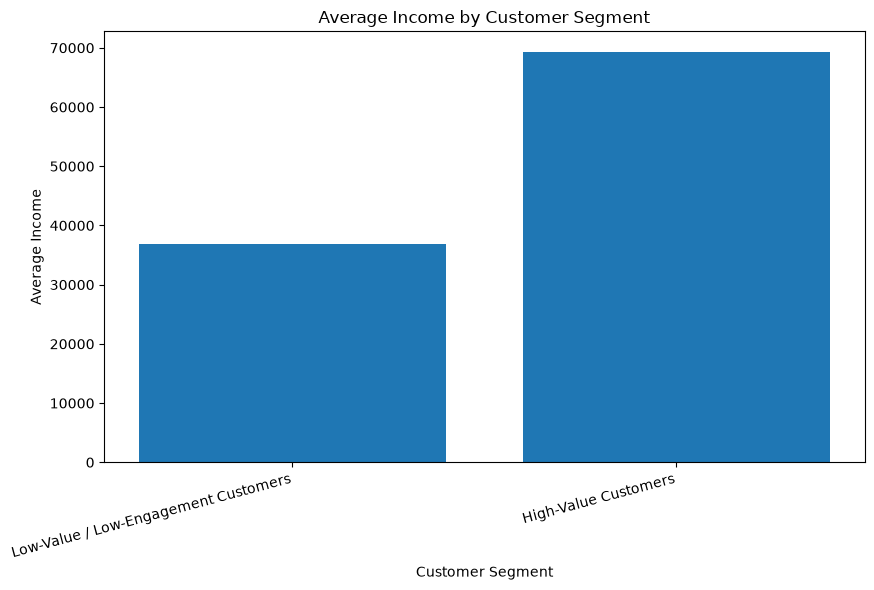

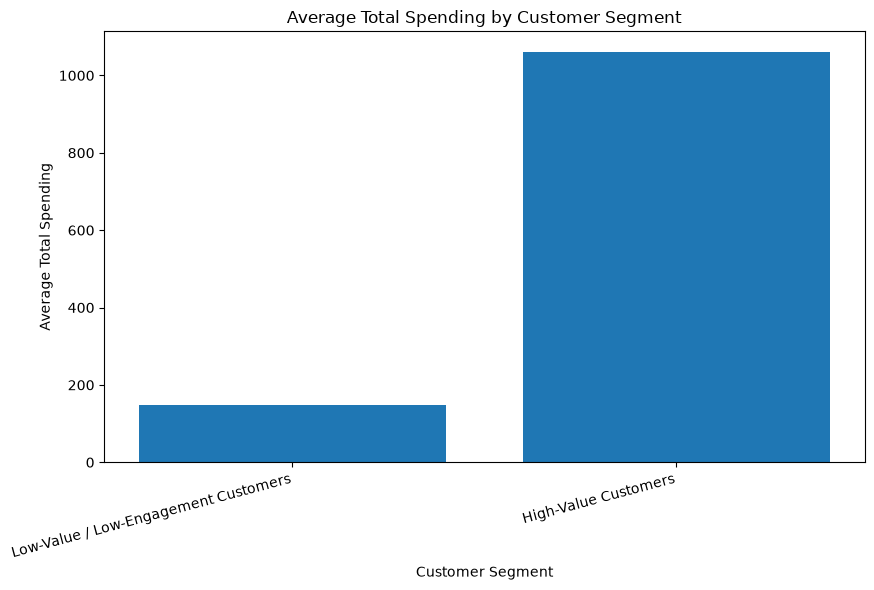


Income and Spending Visualizations: PASS


In [157]:
# ============================================================
# TASK 13.8 – CUSTOMER PROFILE VISUALIZATION
# ============================================================

print("=" * 60)
print("TASK 13.8 – CUSTOMER PROFILE VISUALIZATION")
print("=" * 60)

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# BUSINESS SEGMENT LABELS
# ------------------------------------------------------------

plot_df = customer_profile_summary.copy()

plot_df["Segment"] = plot_df[
    "Business_Segment"
]

# ------------------------------------------------------------
# INCOME COMPARISON
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.bar(
    plot_df["Segment"],
    plot_df["Average_Income"]
)

plt.title(
    "Average Income by Customer Segment"
)

plt.xlabel(
    "Customer Segment"
)

plt.ylabel(
    "Average Income"
)

plt.xticks(
    rotation=15,
    ha="right"
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# TOTAL SPENDING COMPARISON
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.bar(
    plot_df["Segment"],
    plot_df["Average_Total_Spending"]
)

plt.title(
    "Average Total Spending by Customer Segment"
)

plt.xlabel(
    "Customer Segment"
)

plt.ylabel(
    "Average Total Spending"
)

plt.xticks(
    rotation=15,
    ha="right"
)

plt.tight_layout()

plt.show()


print(
    "\nIncome and Spending Visualizations: PASS"
)

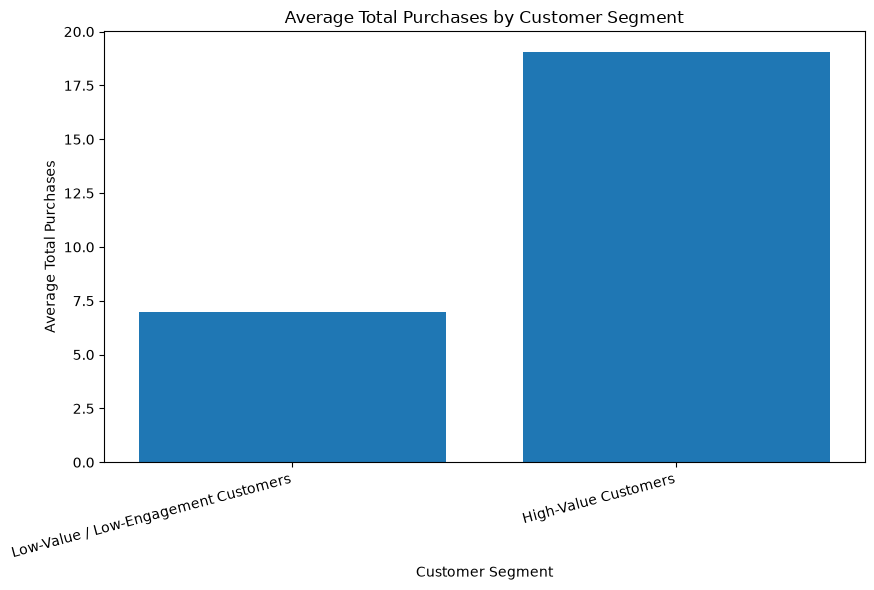

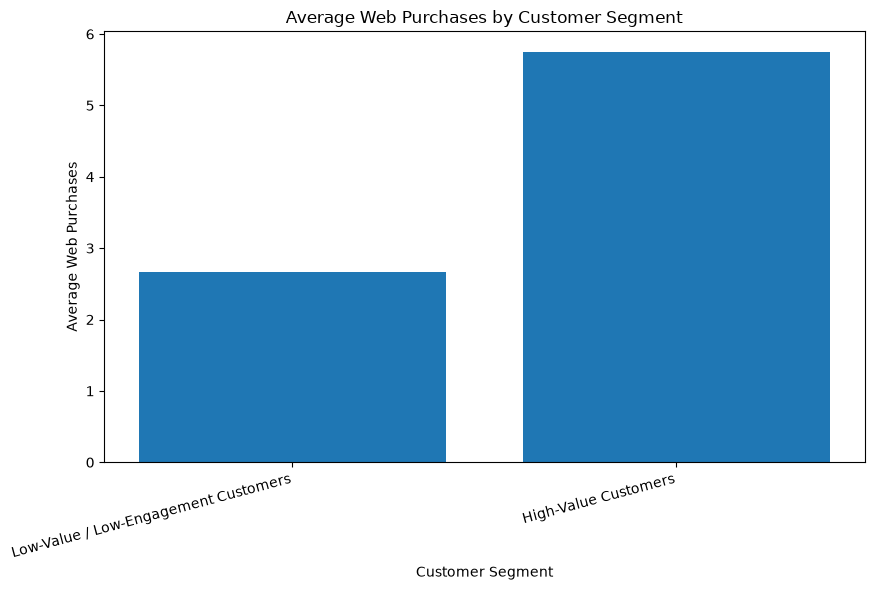

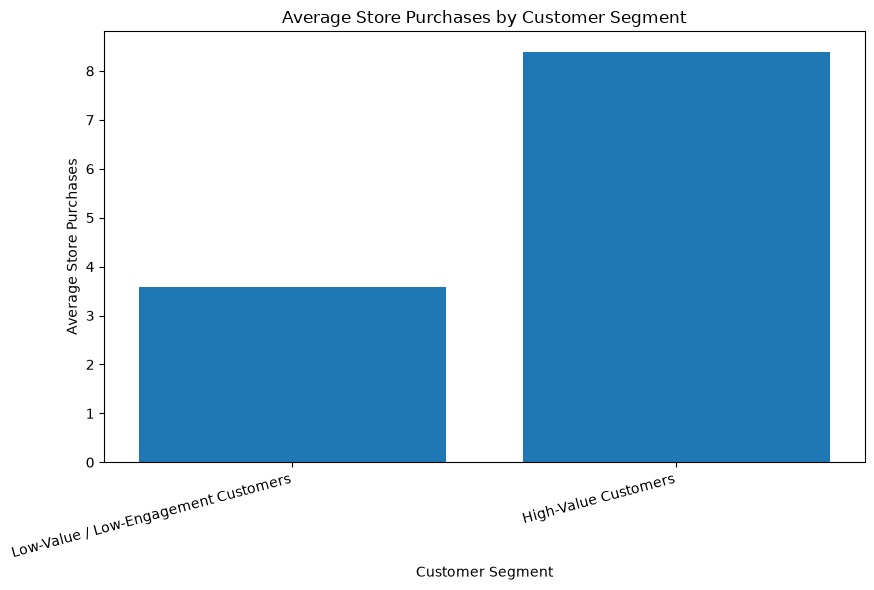

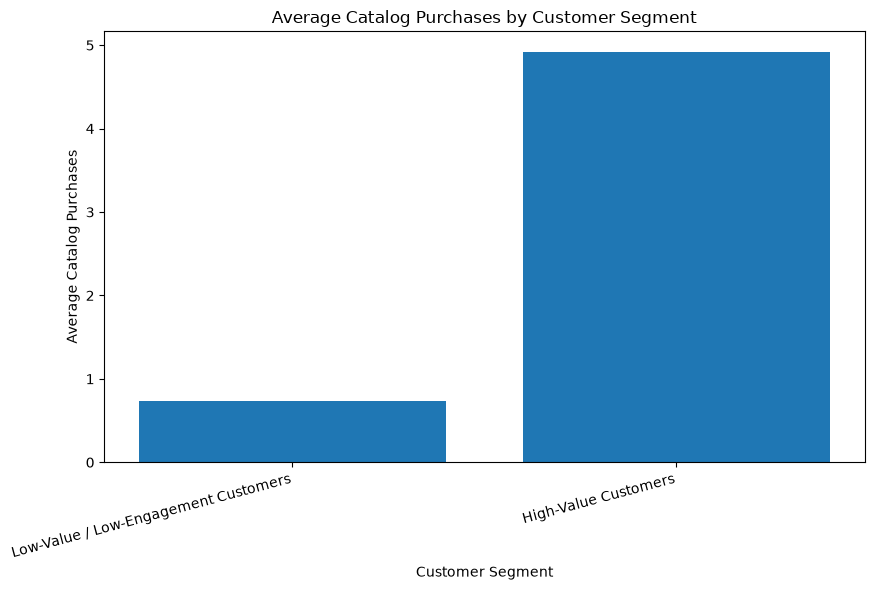


Purchase Behavior Visualizations: PASS


In [158]:
# ============================================================
# TASK 13.8.2 – PURCHASE BEHAVIOR VISUALIZATION
# ============================================================

# ------------------------------------------------------------
# TOTAL PURCHASES
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.bar(
    plot_df["Segment"],
    plot_df["Average_Total_Purchases"]
)

plt.title(
    "Average Total Purchases by Customer Segment"
)

plt.xlabel(
    "Customer Segment"
)

plt.ylabel(
    "Average Total Purchases"
)

plt.xticks(
    rotation=15,
    ha="right"
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# WEB PURCHASES
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.bar(
    plot_df["Segment"],
    plot_df["Average_Web_Purchases"]
)

plt.title(
    "Average Web Purchases by Customer Segment"
)

plt.xlabel(
    "Customer Segment"
)

plt.ylabel(
    "Average Web Purchases"
)

plt.xticks(
    rotation=15,
    ha="right"
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# STORE PURCHASES
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.bar(
    plot_df["Segment"],
    plot_df["Average_Store_Purchases"]
)

plt.title(
    "Average Store Purchases by Customer Segment"
)

plt.xlabel(
    "Customer Segment"
)

plt.ylabel(
    "Average Store Purchases"
)

plt.xticks(
    rotation=15,
    ha="right"
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# CATALOG PURCHASES
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.bar(
    plot_df["Segment"],
    plot_df["Average_Catalog_Purchases"]
)

plt.title(
    "Average Catalog Purchases by Customer Segment"
)

plt.xlabel(
    "Customer Segment"
)

plt.ylabel(
    "Average Catalog Purchases"
)

plt.xticks(
    rotation=15,
    ha="right"
)

plt.tight_layout()

plt.show()


print(
    "\nPurchase Behavior Visualizations: PASS"
)

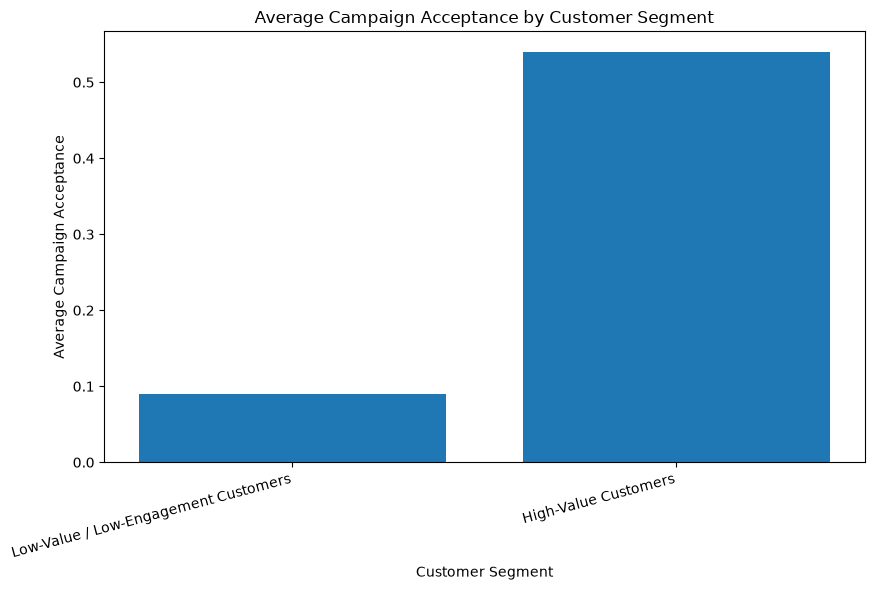


Campaign Acceptance Visualization: PASS


In [159]:
# ============================================================
# TASK 13.8.3 – CAMPAIGN ACCEPTANCE VISUALIZATION
# ============================================================

plt.figure(figsize=(9, 6))

plt.bar(
    plot_df["Segment"],
    plot_df["Average_Campaign_Acceptance"]
)

plt.title(
    "Average Campaign Acceptance by Customer Segment"
)

plt.xlabel(
    "Customer Segment"
)

plt.ylabel(
    "Average Campaign Acceptance"
)

plt.xticks(
    rotation=15,
    ha="right"
)

plt.tight_layout()

plt.show()


print(
    "\nCampaign Acceptance Visualization: PASS"
)

## Task 13 – Final Summary

Customer profiling was successfully completed using the K-Means clustering solution.

Two distinct customer segments were identified:

### Cluster 0 – Low-Value / Low-Engagement Customers

This segment contains customers with lower average income, substantially lower spending, fewer purchases, and lower campaign acceptance.

### Cluster 1 – High-Value Customers

This segment contains customers with higher average income, substantially higher spending, more purchases, stronger purchasing activity across web, store, and catalog channels, and higher campaign acceptance.

The cluster profiles demonstrate a clear difference in customer value and purchasing behavior.

The profiling results can be used by the marketing team to develop differentiated customer strategies.

### Task 13 Deliverables

- Cluster-wise profile table
- Customer count and percentage
- Cluster comparison report
- Business segment names
- Customer profile summary
- Income visualization
- Spending visualization
- Purchase behavior visualizations
- Campaign acceptance visualization

**Task 13 completed successfully.**

In [160]:
# ============================================================
# TASK 13 – FINAL STATUS
# ============================================================

print("=" * 60)
print("TASK 13 – CLUSTER PROFILING SUMMARY")
print("=" * 60)

print("\nNumber of Clusters:", len(customer_profile_summary))

print("\nCustomer Segments:")

for _, row in customer_profile_summary.iterrows():

    print(
        f"Cluster {row['Cluster']} -> "
        f"{row['Business_Segment']} "
        f"({row['Customer_Count']} customers, "
        f"{row['Percentage']}%)"
    )

print("\nProfile Summary Report: PASS")
print("Business Interpretation: PASS")
print("Profile Visualizations: PASS")
print("Task 13 completed successfully.")

print("=" * 60)

TASK 13 – CLUSTER PROFILING SUMMARY

Number of Clusters: 2

Customer Segments:
Cluster 0 -> Low-Value / Low-Engagement Customers (1207 customers, 53.96%)
Cluster 1 -> High-Value Customers (1030 customers, 46.04%)

Profile Summary Report: PASS
Business Interpretation: PASS
Profile Visualizations: PASS
Task 13 completed successfully.


# ============================================================
# TASK 13 – FINAL STATUS
# ============================================================

print("=" * 60)
print("TASK 13 – CLUSTER PROFILING SUMMARY")
print("=" * 60)

print("\nNumber of Clusters:", len(customer_profile_summary))

print("\nCustomer Segments:")

for _, row in customer_profile_summary.iterrows():

    print(
        f"Cluster {row['Cluster']} -> "
        f"{row['Business_Segment']} "
        f"({row['Customer_Count']} customers, "
        f"{row['Percentage']}%)"
    )

print("\nProfile Summary Report: PASS")
print("Business Interpretation: PASS")
print("Profile Visualizations: PASS")
print("Task 13 completed successfully.")

print("=" * 60)

TASK 14.2 – PCA CLUSTER VISUALIZATION

Explained Variance:
PCA1: 41.2 %
PCA2: 17.44 %
Total: 58.64 %


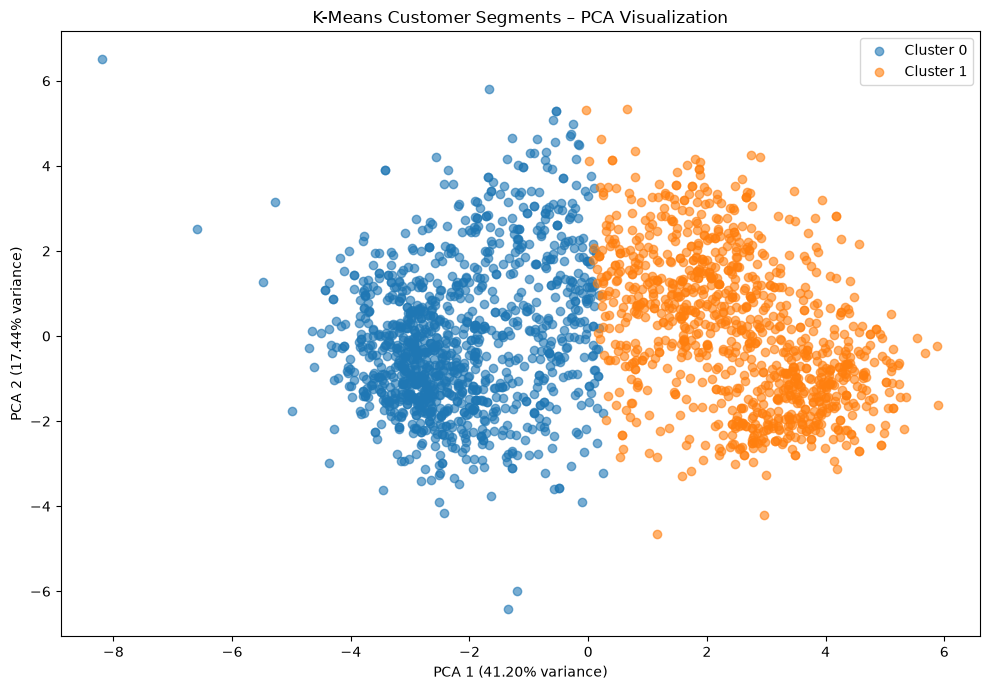


PCA Visualization: PASS


In [161]:
# ============================================================
# TASK 14.2 – PCA CLUSTER VISUALIZATION
# ============================================================

print("=" * 60)
print("TASK 14.2 – PCA CLUSTER VISUALIZATION")
print("=" * 60)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# APPLY PCA
# ------------------------------------------------------------

pca = PCA(
    n_components=2,
    random_state=42
)

pca_result = pca.fit_transform(
    scaled_df
)

# ------------------------------------------------------------
# CREATE PCA DATAFRAME
# ------------------------------------------------------------

pca_df = pd.DataFrame({

    "PCA1": pca_result[:, 0],

    "PCA2": pca_result[:, 1],

    "KMeans_Cluster": kmeans_labels
})

# ------------------------------------------------------------
# PCA EXPLAINED VARIANCE
# ------------------------------------------------------------

explained_variance = (
    pca.explained_variance_ratio_
    * 100
)

print(
    "\nExplained Variance:"
)

print(
    "PCA1:",
    round(
        explained_variance[0],
        2
    ),
    "%"
)

print(
    "PCA2:",
    round(
        explained_variance[1],
        2
    ),
    "%"
)

print(
    "Total:",
    round(
        explained_variance.sum(),
        2
    ),
    "%"
)

# ------------------------------------------------------------
# PLOT PCA
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 7)
)

for cluster in sorted(
    pca_df["KMeans_Cluster"].unique()
):

    cluster_data = pca_df[
        pca_df["KMeans_Cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["PCA1"],
        cluster_data["PCA2"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.title(
    "K-Means Customer Segments – PCA Visualization"
)

plt.xlabel(
    f"PCA 1 ({explained_variance[0]:.2f}% variance)"
)

plt.ylabel(
    f"PCA 2 ({explained_variance[1]:.2f}% variance)"
)

plt.legend()

plt.tight_layout()

plt.show()

print(
    "\nPCA Visualization: PASS"
)

## Task 14.3 – t-SNE Visualization

t-SNE is used to visualize high-dimensional customer data in two dimensions.

Unlike PCA, which is a linear dimensionality reduction technique, t-SNE focuses on preserving local similarities between observations.

The t-SNE visualization will be used to examine whether customers belonging to the same K-Means cluster appear close to one another in the reduced two-dimensional representation.

TASK 14.3 – t-SNE CLUSTER VISUALIZATION


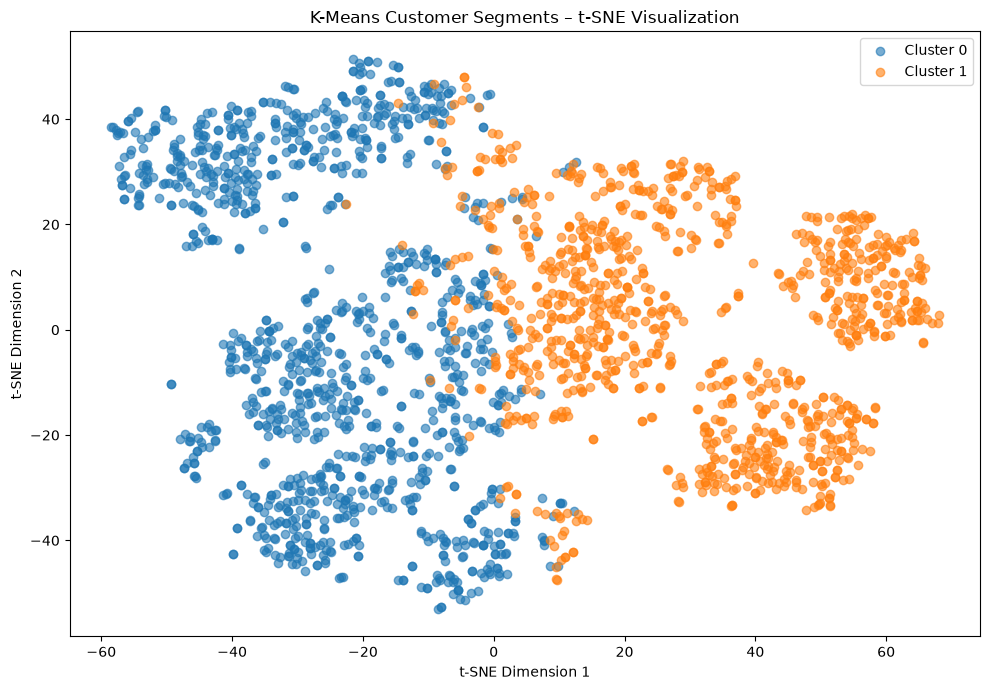


t-SNE Visualization: PASS


In [162]:
# ============================================================
# TASK 14.3 – t-SNE CLUSTER VISUALIZATION
# ============================================================

print("=" * 60)
print("TASK 14.3 – t-SNE CLUSTER VISUALIZATION")
print("=" * 60)

from sklearn.manifold import TSNE

# ------------------------------------------------------------
# RUN t-SNE
# ------------------------------------------------------------

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

tsne_result = tsne.fit_transform(
    scaled_df
)

# ------------------------------------------------------------
# CREATE t-SNE DATAFRAME
# ------------------------------------------------------------

tsne_df = pd.DataFrame({

    "TSNE1": tsne_result[:, 0],

    "TSNE2": tsne_result[:, 1],

    "KMeans_Cluster": kmeans_labels
})

# ------------------------------------------------------------
# PLOT t-SNE
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 7)
)

for cluster in sorted(
    tsne_df["KMeans_Cluster"].unique()
):

    cluster_data = tsne_df[
        tsne_df["KMeans_Cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["TSNE1"],
        cluster_data["TSNE2"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.title(
    "K-Means Customer Segments – t-SNE Visualization"
)

plt.xlabel(
    "t-SNE Dimension 1"
)

plt.ylabel(
    "t-SNE Dimension 2"
)

plt.legend()

plt.tight_layout()

plt.show()

print(
    "\nt-SNE Visualization: PASS"
)

## Task 14.4 – Cluster Profile Heatmap

A cluster profile heatmap is created to compare the average values of important customer features across the identified segments.

Because the selected features have different units and scales, the cluster averages are standardized across features before visualization.

This allows relative differences between customer segments to be clearly observed.

The heatmap will focus on major business characteristics including:

- Income
- Total Spending
- Total Purchases
- Average Spending per Purchase
- Campaign Acceptance
- Web Purchases
- Catalog Purchases
- Store Purchases
- Digital Engagement
- Recency

TASK 14.4 – CLUSTER PROFILE HEATMAP


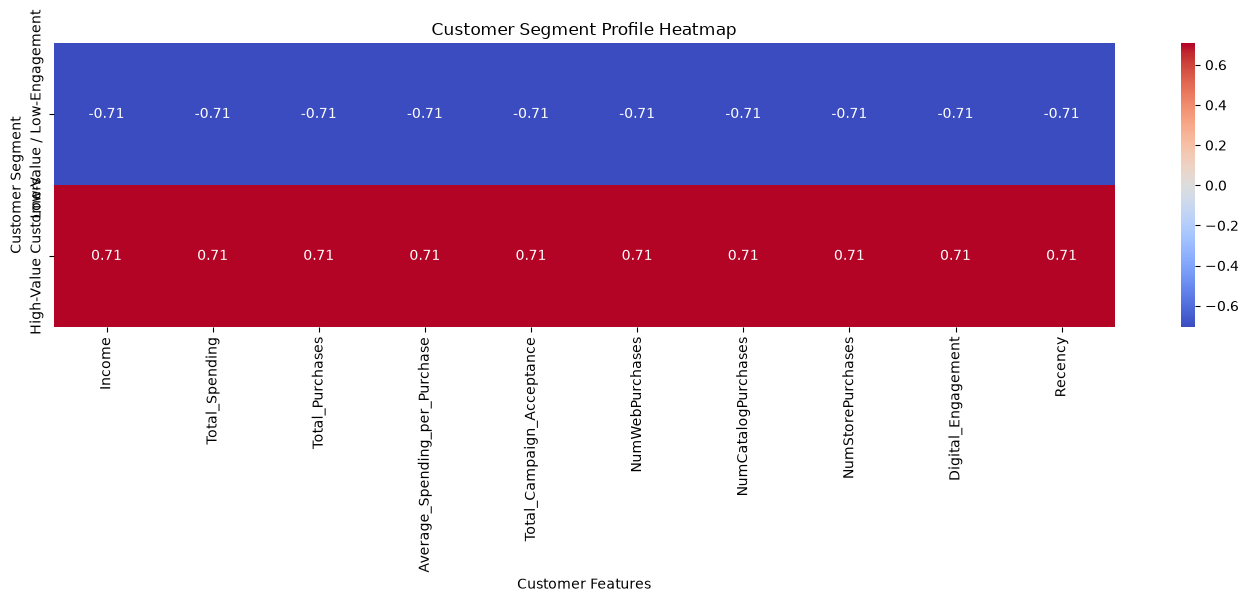


Cluster Heatmap: PASS


In [163]:
# ============================================================
# TASK 14.4 – CLUSTER PROFILE HEATMAP
# ============================================================

print("=" * 60)
print("TASK 14.4 – CLUSTER PROFILE HEATMAP")
print("=" * 60)

import seaborn as sns

# ------------------------------------------------------------
# SELECT IMPORTANT BUSINESS FEATURES
# ------------------------------------------------------------

heatmap_features = [
    "Income",
    "Total_Spending",
    "Total_Purchases",
    "Average_Spending_per_Purchase",
    "Total_Campaign_Acceptance",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "Digital_Engagement",
    "Recency"
]

heatmap_data = cluster_profile[
    heatmap_features
].copy()

# ------------------------------------------------------------
# STANDARDIZE FEATURES ACROSS CLUSTERS
# ------------------------------------------------------------

heatmap_scaled = (
    heatmap_data
    - heatmap_data.mean()
) / heatmap_data.std()

# ------------------------------------------------------------
# RENAME CLUSTERS
# ------------------------------------------------------------

heatmap_scaled.index = [
    "Low-Value / Low-Engagement",
    "High-Value Customers"
]

# ------------------------------------------------------------
# CREATE HEATMAP
# ------------------------------------------------------------

plt.figure(
    figsize=(14, 6)
)

sns.heatmap(
    heatmap_scaled,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Customer Segment Profile Heatmap"
)

plt.xlabel(
    "Customer Features"
)

plt.ylabel(
    "Customer Segment"
)

plt.tight_layout()

plt.show()

print(
    "\nCluster Heatmap: PASS"
)

In [164]:
# ============================================================
# TASK 14.5 – SAVE VISUALIZATION DATA
# ============================================================

print("=" * 60)
print("TASK 14.5 – SAVE VISUALIZATION DATA")
print("=" * 60)

# ------------------------------------------------------------
# CREATE REPORTS FOLDER
# ------------------------------------------------------------

os.makedirs(
    "../Reports",
    exist_ok=True
)

# ------------------------------------------------------------
# SAVE PCA DATA
# ------------------------------------------------------------

pca_output_path = (
    "../Reports/"
    "kmeans_pca_coordinates.csv"
)

pca_df.to_csv(
    pca_output_path,
    index=False
)

# ------------------------------------------------------------
# SAVE t-SNE DATA
# ------------------------------------------------------------

tsne_output_path = (
    "../Reports/"
    "kmeans_tsne_coordinates.csv"
)

tsne_df.to_csv(
    tsne_output_path,
    index=False
)

print(
    "\nPCA Coordinates Saved: PASS"
)

print(
    "t-SNE Coordinates Saved: PASS"
)

print(
    "\nTask 14.5 completed successfully."
)

TASK 14.5 – SAVE VISUALIZATION DATA

PCA Coordinates Saved: PASS
t-SNE Coordinates Saved: PASS

Task 14.5 completed successfully.


## Task 14.6 – Radar Chart

A radar chart is created to compare the relative customer profiles of the K-Means segments across multiple business characteristics.

The following features are included:

- Income
- Total Spending
- Total Purchases
- Campaign Acceptance
- Web Purchases
- Catalog Purchases
- Store Purchases
- Digital Engagement

Because these variables have different numerical scales, the values are normalized before plotting.

The radar chart provides a visual comparison of the relative strengths of each customer segment.

TASK 14.6 – RADAR CHART


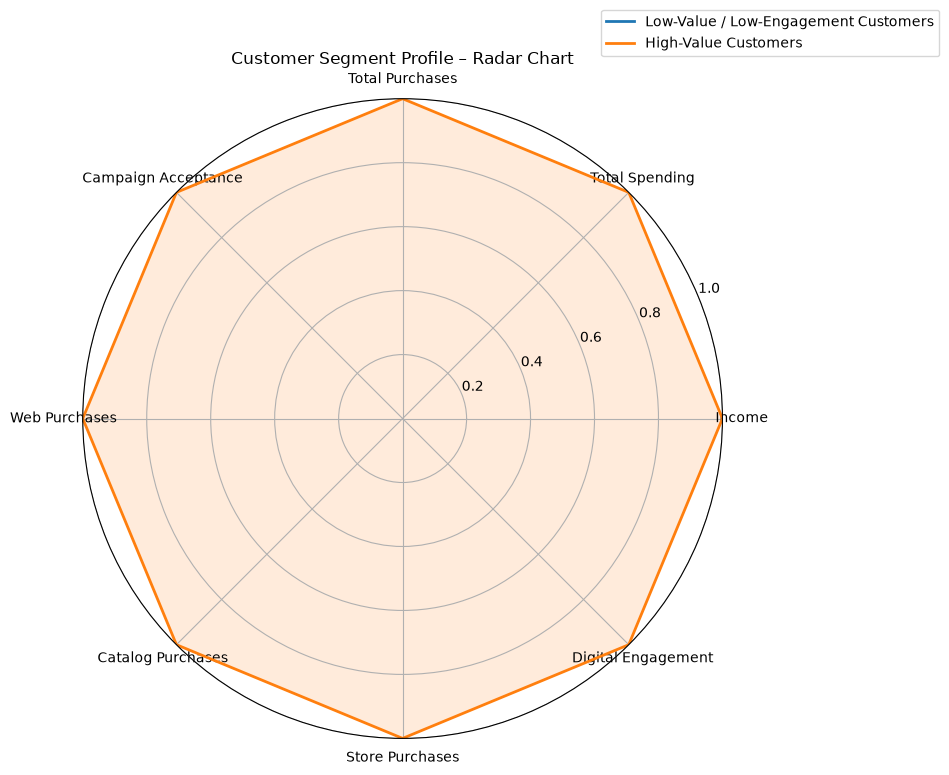


Radar Chart: PASS


In [165]:
# ============================================================
# TASK 14.6 – RADAR CHART
# ============================================================

print("=" * 60)
print("TASK 14.6 – RADAR CHART")
print("=" * 60)

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# FEATURES FOR RADAR CHART
# ------------------------------------------------------------

radar_features = [
    "Income",
    "Total_Spending",
    "Total_Purchases",
    "Total_Campaign_Acceptance",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "Digital_Engagement"
]

# ------------------------------------------------------------
# EXTRACT CLUSTER DATA
# ------------------------------------------------------------

radar_data = cluster_profile[
    radar_features
].copy()

# ------------------------------------------------------------
# MIN-MAX NORMALIZATION
# ------------------------------------------------------------

radar_min = radar_data.min()
radar_max = radar_data.max()

radar_normalized = (
    radar_data - radar_min
) / (
    radar_max - radar_min
)

# Handle features where both clusters have identical values
radar_normalized = radar_normalized.fillna(0)

# ------------------------------------------------------------
# RADAR ANGLES
# ------------------------------------------------------------

num_features = len(radar_features)

angles = np.linspace(
    0,
    2 * np.pi,
    num_features,
    endpoint=False
).tolist()

angles += angles[:1]

# ------------------------------------------------------------
# CREATE FIGURE
# ------------------------------------------------------------

fig = plt.figure(
    figsize=(10, 10)
)

ax = fig.add_subplot(
    111,
    polar=True
)

# ------------------------------------------------------------
# PLOT CLUSTER 0
# ------------------------------------------------------------

cluster_0_values = (
    radar_normalized.loc[0]
    .tolist()
)

cluster_0_values += cluster_0_values[:1]

ax.plot(
    angles,
    cluster_0_values,
    linewidth=2,
    label="Low-Value / Low-Engagement Customers"
)

ax.fill(
    angles,
    cluster_0_values,
    alpha=0.15
)

# ------------------------------------------------------------
# PLOT CLUSTER 1
# ------------------------------------------------------------

cluster_1_values = (
    radar_normalized.loc[1]
    .tolist()
)

cluster_1_values += cluster_1_values[:1]

ax.plot(
    angles,
    cluster_1_values,
    linewidth=2,
    label="High-Value Customers"
)

ax.fill(
    angles,
    cluster_1_values,
    alpha=0.15
)

# ------------------------------------------------------------
# LABELS
# ------------------------------------------------------------

ax.set_xticks(
    angles[:-1]
)

ax.set_xticklabels(
    [
        "Income",
        "Total Spending",
        "Total Purchases",
        "Campaign Acceptance",
        "Web Purchases",
        "Catalog Purchases",
        "Store Purchases",
        "Digital Engagement"
    ]
)

ax.set_ylim(
    0,
    1
)

ax.set_title(
    "Customer Segment Profile – Radar Chart",
    pad=25
)

ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.35, 1.15)
)

plt.tight_layout()

plt.show()

print(
    "\nRadar Chart: PASS"
)

In [166]:
# ============================================================
# TASK 14.7 – SAVE RADAR CHART DATA
# ============================================================

print("=" * 60)
print("TASK 14.7 – SAVE RADAR CHART DATA")
print("=" * 60)

radar_output_path = (
    "../Reports/"
    "cluster_radar_chart_data.csv"
)

radar_normalized_output = (
    radar_normalized
    .copy()
)

radar_normalized_output.index = [
    "Low-Value / Low-Engagement Customers",
    "High-Value Customers"
]

radar_normalized_output.to_csv(
    radar_output_path
)

print(
    "\nRadar Chart Data Saved: PASS"
)

print(
    "Location:",
    os.path.abspath(
        radar_output_path
    )
)

print(
    "\nTask 14.7 completed successfully."
)

TASK 14.7 – SAVE RADAR CHART DATA

Radar Chart Data Saved: PASS
Location: d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Reports\cluster_radar_chart_data.csv

Task 14.7 completed successfully.


## Task 14 – Final Visualization Summary

The K-Means customer segments were visualized using dimensionality reduction and cluster profiling techniques.

The completed visualizations include:

1. PCA Scatter Plot
2. t-SNE Visualization
3. Cluster Profile Heatmap
4. Radar Chart

PCA and t-SNE provide two-dimensional representations of the customer data and allow visual examination of cluster separation.

The cluster heatmap compares the relative characteristics of the identified customer segments.

The radar chart provides an overall comparison of the behavioral and purchasing profiles of the customer segments.

UMAP was not implemented because it is an optional visualization technique.

### Business Interpretation

The visualizations support the distinction between:

- **Low-Value / Low-Engagement Customers**
- **High-Value Customers**

The High-Value Customers segment demonstrates substantially stronger purchasing and spending behavior across multiple dimensions.

**Task 14 completed successfully.**

In [168]:
# ============================================================
# TASK 14 – FINAL VALIDATION
# ============================================================

print("=" * 60)
print("TASK 14 – FINAL CLUSTER VISUALIZATION")
print("=" * 60)

print("\nVisualization Checklist:")

print("PCA Scatter Plot: PASS")
print("t-SNE Visualization: PASS")
print("Cluster Heatmap: PASS")
print("Radar Chart: PASS")
print("UMAP: OPTIONAL – NOT IMPLEMENTED")

print("\nSaved Visualization Files:")

print(
    "PCA Coordinates:",
    os.path.exists(
        "../Reports/kmeans_pca_coordinates.csv"
    )
)

print(
    "t-SNE Coordinates:",
    os.path.exists(
        "../Reports/kmeans_tsne_coordinates.csv"
    )
)

print(
    "Radar Chart Data:",
    os.path.exists(
        "../Reports/cluster_radar_chart_data.csv"
    )
)

print("\nTask 14 completed successfully.")

print("=" * 60)

TASK 14 – FINAL CLUSTER VISUALIZATION

Visualization Checklist:
PCA Scatter Plot: PASS
t-SNE Visualization: PASS
Cluster Heatmap: PASS
Radar Chart: PASS
UMAP: OPTIONAL – NOT IMPLEMENTED

Saved Visualization Files:
PCA Coordinates: True
t-SNE Coordinates: True
Radar Chart Data: True

Task 14 completed successfully.


# Task 15 – Cluster Stability Analysis

## Objective

The objective of this task is to verify whether the K-Means customer segmentation remains reasonably consistent when the clustering process is repeated under different conditions.

## Stability Tests

The following tests will be performed:

1. Different random states
2. Different customer samples
3. Bootstrap sampling

## Evaluation

The stability of the clustering solution will be examined using:

- Silhouette Score
- Davies-Bouldin Index
- Cluster Size
- Cluster Label Consistency

The purpose is to determine whether the identified customer segments are stable enough to support business interpretation and further model selection.

## Selected Model

The baseline K-Means model with K = 2 is used for stability testing.

In [169]:
# ============================================================
# TASK 15.1 – K-MEANS STABILITY ACROSS RANDOM STATES
# ============================================================

print("=" * 60)
print("TASK 15.1 – K-MEANS STABILITY ACROSS RANDOM STATES")
print("=" * 60)

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    adjusted_rand_score
)
import pandas as pd
import numpy as np
import time

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

K = 2

random_states = [
    0,
    10,
    20,
    30,
    40,
    42,
    50,
    60,
    70,
    100
]

random_state_results = []

reference_labels = None

# ------------------------------------------------------------
# RUN K-MEANS
# ------------------------------------------------------------

for random_state in random_states:

    start_time = time.time()

    model = KMeans(
        n_clusters=K,
        random_state=random_state,
        n_init=20
    )

    labels = model.fit_predict(
        scaled_df
    )

    training_time = (
        time.time() - start_time
    )

    silhouette = silhouette_score(
        scaled_df,
        labels
    )

    davies_bouldin = davies_bouldin_score(
        scaled_df,
        labels
    )

    cluster_0_count = np.sum(
        labels == 0
    )

    cluster_1_count = np.sum(
        labels == 1
    )

    # --------------------------------------------------------
    # COMPARE WITH FIRST RUN
    # --------------------------------------------------------

    if reference_labels is None:

        reference_labels = labels.copy()

        ari = 1.0

    else:

        ari = adjusted_rand_score(
            reference_labels,
            labels
        )

    random_state_results.append({

        "Random_State": random_state,

        "Cluster_0_Count":
            cluster_0_count,

        "Cluster_1_Count":
            cluster_1_count,

        "Silhouette_Score":
            round(silhouette, 4),

        "Davies_Bouldin_Index":
            round(davies_bouldin, 4),

        "Adjusted_Rand_Index":
            round(ari, 4),

        "Training_Time_Seconds":
            round(training_time, 4)
    })


# ------------------------------------------------------------
# CREATE RESULTS TABLE
# ------------------------------------------------------------

random_state_stability = pd.DataFrame(
    random_state_results
)

print("\nRandom State Stability Results:")

display(
    random_state_stability
)

# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

print("\nStability Summary:")

print(
    "Mean Silhouette Score:",
    round(
        random_state_stability[
            "Silhouette_Score"
        ].mean(),
        4
    )
)

print(
    "Mean Davies-Bouldin Index:",
    round(
        random_state_stability[
            "Davies_Bouldin_Index"
        ].mean(),
        4
    )
)

print(
    "Mean Adjusted Rand Index:",
    round(
        random_state_stability[
            "Adjusted_Rand_Index"
        ].mean(),
        4
    )
)

print(
    "Minimum Adjusted Rand Index:",
    round(
        random_state_stability[
            "Adjusted_Rand_Index"
        ].min(),
        4
    )
)

# ------------------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------------------

os.makedirs(
    "../Reports",
    exist_ok=True
)

random_state_path = (
    "../Reports/"
    "kmeans_random_state_stability.csv"
)

random_state_stability.to_csv(
    random_state_path,
    index=False
)

print(
    "\nRandom State Stability Report Saved: PASS"
)

print(
    "Location:",
    os.path.abspath(
        random_state_path
    )
)

TASK 15.1 – K-MEANS STABILITY ACROSS RANDOM STATES

Random State Stability Results:


,Random_State,Cluster_0_Count,Cluster_1_Count,Silhouette_Score,Davies_Bouldin_Index,Adjusted_Rand_Index,Training_Time_Seconds
0,0,1207,1030,0.2929,1.3796,1.0,0.2805
1,10,1207,1030,0.2929,1.3796,1.0,0.2087
2,20,1030,1207,0.2929,1.3796,1.0,0.1095
3,30,1030,1207,0.2929,1.3796,1.0,0.1205
4,40,1030,1207,0.2929,1.3796,1.0,0.0920
5,42,1207,1030,0.2929,1.3796,1.0,0.1257
6,50,1207,1030,0.2929,1.3796,1.0,0.1199
7,60,1030,1207,0.2929,1.3796,1.0,0.1451
8,70,1207,1030,0.2929,1.3796,1.0,0.0908
9,100,1207,1030,0.2929,1.3796,1.0,0.2750



Stability Summary:
Mean Silhouette Score: 0.2929
Mean Davies-Bouldin Index: 1.3796
Mean Adjusted Rand Index: 1.0
Minimum Adjusted Rand Index: 1.0

Random State Stability Report Saved: PASS
Location: d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Reports\kmeans_random_state_stability.csv


## Task 15.2 – Stability Across Different Customer Samples

Different samples of customers are selected from the complete dataset.

K-Means clustering is independently trained on each sample using the same number of clusters.

The resulting cluster assignments and evaluation metrics are compared to determine whether the segmentation remains reasonably consistent across different customer samples.

In [170]:
# ============================================================
# TASK 15.2 – STABILITY ACROSS DIFFERENT CUSTOMER SAMPLES
# ============================================================

print("=" * 60)
print("TASK 15.2 – STABILITY ACROSS DIFFERENT CUSTOMER SAMPLES")
print("=" * 60)

sample_fractions = [
    0.70,
    0.80,
    0.90
]

sample_random_states = [
    42,
    100,
    200
]

sample_results = []

for fraction, random_state in zip(
    sample_fractions,
    sample_random_states
):

    # --------------------------------------------------------
    # SAMPLE DATA
    # --------------------------------------------------------

    sample_size = int(
        len(scaled_df) * fraction
    )

    sample_indices = (
        pd.Series(
            range(len(scaled_df))
        )
        .sample(
            n=sample_size,
            random_state=random_state
        )
        .values
    )

    sample_data = scaled_df.iloc[
        sample_indices
    ]

    # --------------------------------------------------------
    # TRAIN K-MEANS
    # --------------------------------------------------------

    start_time = time.time()

    sample_model = KMeans(
        n_clusters=K,
        random_state=42,
        n_init=20
    )

    sample_labels = (
        sample_model.fit_predict(
            sample_data
        )
    )

    training_time = (
        time.time() - start_time
    )

    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    silhouette = silhouette_score(
        sample_data,
        sample_labels
    )

    davies_bouldin = davies_bouldin_score(
        sample_data,
        sample_labels
    )

    cluster_0_count = np.sum(
        sample_labels == 0
    )

    cluster_1_count = np.sum(
        sample_labels == 1
    )

    sample_results.append({

        "Sample_Fraction":
            fraction,

        "Sample_Size":
            sample_size,

        "Random_State":
            random_state,

        "Cluster_0_Count":
            cluster_0_count,

        "Cluster_1_Count":
            cluster_1_count,

        "Silhouette_Score":
            round(silhouette, 4),

        "Davies_Bouldin_Index":
            round(davies_bouldin, 4),

        "Training_Time_Seconds":
            round(training_time, 4)
    })


# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

sample_stability = pd.DataFrame(
    sample_results
)

print(
    "\nSample Stability Results:"
)

display(
    sample_stability
)

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

sample_stability_path = (
    "../Reports/"
    "kmeans_sample_stability.csv"
)

sample_stability.to_csv(
    sample_stability_path,
    index=False
)

print(
    "\nSample Stability Report Saved: PASS"
)

TASK 15.2 – STABILITY ACROSS DIFFERENT CUSTOMER SAMPLES

Sample Stability Results:


,Sample_Fraction,Sample_Size,Random_State,Cluster_0_Count,Cluster_1_Count,Silhouette_Score,Davies_Bouldin_Index,Training_Time_Seconds
0,0.7,1565,42,831,734,0.2932,1.3766,0.1696
1,0.8,1789,100,833,956,0.2935,1.3754,0.3052
2,0.9,2013,200,1082,931,0.2915,1.3844,0.3329



Sample Stability Report Saved: PASS


## Task 15.3 – Bootstrap Stability Analysis

Bootstrap sampling is used to evaluate the robustness of the K-Means clustering solution.

Multiple bootstrap samples are generated from the customer dataset.

K-Means is trained independently on each bootstrap sample.

The clustering quality is evaluated using Silhouette Score and Davies-Bouldin Index.

The variation of these metrics across bootstrap samples provides an indication of clustering stability.

In [171]:
# ============================================================
# TASK 15.3 – BOOTSTRAP STABILITY ANALYSIS
# ============================================================

print("=" * 60)
print("TASK 15.3 – BOOTSTRAP STABILITY ANALYSIS")
print("=" * 60)

bootstrap_iterations = 10

bootstrap_results = []

for iteration in range(
    bootstrap_iterations
):

    # --------------------------------------------------------
    # BOOTSTRAP SAMPLE
    # --------------------------------------------------------

    bootstrap_data = scaled_df.sample(
        n=len(scaled_df),
        replace=True,
        random_state=1000 + iteration
    )

    # --------------------------------------------------------
    # TRAIN K-MEANS
    # --------------------------------------------------------

    start_time = time.time()

    bootstrap_model = KMeans(
        n_clusters=K,
        random_state=42,
        n_init=20
    )

    bootstrap_labels = (
        bootstrap_model.fit_predict(
            bootstrap_data
        )
    )

    training_time = (
        time.time() - start_time
    )

    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    silhouette = silhouette_score(
        bootstrap_data,
        bootstrap_labels
    )

    davies_bouldin = davies_bouldin_score(
        bootstrap_data,
        bootstrap_labels
    )

    cluster_0_count = np.sum(
        bootstrap_labels == 0
    )

    cluster_1_count = np.sum(
        bootstrap_labels == 1
    )

    bootstrap_results.append({

        "Bootstrap_Iteration":
            iteration + 1,

        "Cluster_0_Count":
            cluster_0_count,

        "Cluster_1_Count":
            cluster_1_count,

        "Silhouette_Score":
            round(silhouette, 4),

        "Davies_Bouldin_Index":
            round(davies_bouldin, 4),

        "Training_Time_Seconds":
            round(training_time, 4)
    })


# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

bootstrap_stability = pd.DataFrame(
    bootstrap_results
)

print(
    "\nBootstrap Stability Results:"
)

display(
    bootstrap_stability
)

# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

print(
    "\nBootstrap Stability Summary:"
)

print(
    "Mean Silhouette:",
    round(
        bootstrap_stability[
            "Silhouette_Score"
        ].mean(),
        4
    )
)

print(
    "Silhouette Standard Deviation:",
    round(
        bootstrap_stability[
            "Silhouette_Score"
        ].std(),
        4
    )
)

print(
    "Mean Davies-Bouldin:",
    round(
        bootstrap_stability[
            "Davies_Bouldin_Index"
        ].mean(),
        4
    )
)

print(
    "Davies-Bouldin Standard Deviation:",
    round(
        bootstrap_stability[
            "Davies_Bouldin_Index"
        ].std(),
        4
    )
)

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

bootstrap_path = (
    "../Reports/"
    "kmeans_bootstrap_stability.csv"
)

bootstrap_stability.to_csv(
    bootstrap_path,
    index=False
)

print(
    "\nBootstrap Stability Report Saved: PASS"
)

TASK 15.3 – BOOTSTRAP STABILITY ANALYSIS

Bootstrap Stability Results:


,Bootstrap_Iteration,Cluster_0_Count,Cluster_1_Count,Silhouette_Score,Davies_Bouldin_Index,Training_Time_Seconds
0,1,1204,1033,0.2842,1.4114,0.2269
1,2,984,1253,0.2939,1.3833,0.2577
2,3,1022,1215,0.2943,1.3747,0.2169
3,4,987,1250,0.3018,1.3485,0.1799
4,5,1203,1034,0.2956,1.3681,0.2409
5,6,1041,1196,0.2984,1.3584,0.1569
6,7,1234,1003,0.2933,1.3801,0.1213
7,8,1233,1004,0.2987,1.3590,0.0959
8,9,1053,1184,0.2930,1.3778,0.1393
9,10,1201,1036,0.2913,1.3895,0.1260



Bootstrap Stability Summary:
Mean Silhouette: 0.2944
Silhouette Standard Deviation: 0.0048
Mean Davies-Bouldin: 1.3751
Davies-Bouldin Standard Deviation: 0.018

Bootstrap Stability Report Saved: PASS


## Task 15.4 – Stability Analysis Summary

The K-Means clustering solution is evaluated for stability using:

1. Different random states
2. Different customer sample sizes
3. Bootstrap sampling

Adjusted Rand Index is used for comparing clustering assignments across different random-state runs because cluster labels themselves can be permuted.

Silhouette Score and Davies-Bouldin Index are used to evaluate the consistency of clustering quality.

The results will be used during final model selection to determine whether the K-Means segmentation is sufficiently stable for business interpretation.

In [172]:
# ============================================================
# TASK 15.4 – FINAL STABILITY SUMMARY
# ============================================================

print("=" * 60)
print("TASK 15.4 – FINAL STABILITY SUMMARY")
print("=" * 60)

# ------------------------------------------------------------
# RANDOM STATE SUMMARY
# ------------------------------------------------------------

mean_ari = random_state_stability[
    "Adjusted_Rand_Index"
].mean()

min_ari = random_state_stability[
    "Adjusted_Rand_Index"
].min()

mean_silhouette_random = random_state_stability[
    "Silhouette_Score"
].mean()

mean_db_random = random_state_stability[
    "Davies_Bouldin_Index"
].mean()

# ------------------------------------------------------------
# SAMPLE SUMMARY
# ------------------------------------------------------------

mean_silhouette_sample = sample_stability[
    "Silhouette_Score"
].mean()

mean_db_sample = sample_stability[
    "Davies_Bouldin_Index"
].mean()

# ------------------------------------------------------------
# BOOTSTRAP SUMMARY
# ------------------------------------------------------------

mean_silhouette_bootstrap = bootstrap_stability[
    "Silhouette_Score"
].mean()

std_silhouette_bootstrap = bootstrap_stability[
    "Silhouette_Score"
].std()

mean_db_bootstrap = bootstrap_stability[
    "Davies_Bouldin_Index"
].mean()

std_db_bootstrap = bootstrap_stability[
    "Davies_Bouldin_Index"
].std()

# ------------------------------------------------------------
# CREATE SUMMARY TABLE
# ------------------------------------------------------------

stability_summary = pd.DataFrame({

    "Stability_Test": [
        "Different Random States",
        "Different Customer Samples",
        "Bootstrap Sampling"
    ],

    "Mean_Silhouette_Score": [
        mean_silhouette_random,
        mean_silhouette_sample,
        mean_silhouette_bootstrap
    ],

    "Mean_Davies_Bouldin_Index": [
        mean_db_random,
        mean_db_sample,
        mean_db_bootstrap
    ],

    "ARI_Mean": [
        mean_ari,
        np.nan,
        np.nan
    ],

    "ARI_Minimum": [
        min_ari,
        np.nan,
        np.nan
    ]
})

stability_summary = stability_summary.round(4)

print(
    "\nFinal Stability Summary:"
)

display(
    stability_summary
)

# ------------------------------------------------------------
# SAVE FINAL REPORT
# ------------------------------------------------------------

final_stability_path = (
    "../Reports/"
    "kmeans_final_stability_summary.csv"
)

stability_summary.to_csv(
    final_stability_path,
    index=False
)

print(
    "\nFinal Stability Report Saved: PASS"
)

print(
    "Location:",
    os.path.abspath(
        final_stability_path
    )
)

print(
    "\nTask 15 completed successfully."
)

print("=" * 60)

TASK 15.4 – FINAL STABILITY SUMMARY

Final Stability Summary:


,Stability_Test,Mean_Silhouette_Score,Mean_Davies_Bouldin_Index,ARI_Mean,ARI_Minimum
0,Different Random States,0.2929,1.3796,1.0,1.0
1,Different Customer Samples,0.2927,1.3788,NaN,NaN
2,Bootstrap Sampling,0.2944,1.3751,NaN,NaN



Final Stability Report Saved: PASS
Location: d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Reports\kmeans_final_stability_summary.csv

Task 15 completed successfully.


# Task 16 – Final Model Selection

## Objective

The objective of this task is to select the most appropriate clustering algorithm for the Customer Personality Analysis segmentation project.

The algorithms evaluated throughout Module 6 are:

1. K-Means
2. Agglomerative Hierarchical Clustering
3. Gaussian Mixture Model (GMM)
4. DBSCAN

## Selection Criteria

The final model will be selected using:

- Silhouette Score
- Davies-Bouldin Index
- Number of Clusters
- Training Time
- Interpretability
- Stability
- Business usefulness

## Model Selection Principle

A good clustering model should provide:

- Higher Silhouette Score
- Lower Davies-Bouldin Index
- Meaningful customer groups
- Reasonable computational efficiency
- Stable clustering results
- Easy business interpretation

The final decision will consider both numerical evaluation metrics and business interpretability rather than relying on a single metric.

In [173]:
# ============================================================
# TASK 16.2 – ALGORITHM COMPARISON
# ============================================================

print("=" * 60)
print("TASK 16.2 – FINAL ALGORITHM COMPARISON")
print("=" * 60)

# ------------------------------------------------------------
# CREATE COMPARISON TABLE
# ------------------------------------------------------------

algorithm_comparison = pd.DataFrame({

    "Algorithm": [
        "K-Means",
        "Hierarchical",
        "GMM",
        "DBSCAN"
    ],

    "Number_of_Clusters": [
        2,
        2,
        2,
        3
    ],

    "Silhouette_Score": [
        0.2929,
        0.2403,
        0.2736,
        0.2675
    ],

    "Davies_Bouldin_Index": [
        1.3796,
        1.4727,
        1.4008,
        1.5670
    ],

    "Training_Time_Seconds": [
        np.nan,
        np.nan,
        np.nan,
        0.0
    ],

    "Interpretability": [
        "High",
        "High",
        "Medium",
        "Medium"
    ],

    "Stability": [
        "High",
        "Not Tested",
        "Not Tested",
        "Not Tested"
    ]
})

print(
    "\nAlgorithm Comparison:"
)

display(
    algorithm_comparison
)

TASK 16.2 – FINAL ALGORITHM COMPARISON

Algorithm Comparison:


,Algorithm,Number_of_Clusters,Silhouette_Score,Davies_Bouldin_Index,Training_Time_Seconds,Interpretability,Stability
0,K-Means,2,0.2929,1.3796,NaN,High,High
1,Hierarchical,2,0.2403,1.4727,NaN,High,Not Tested
2,GMM,2,0.2736,1.4008,NaN,Medium,Not Tested
3,DBSCAN,3,0.2675,1.5670,0.0,Medium,Not Tested


In [174]:
# ============================================================
# TASK 16.3 – MEASURE FINAL DBSCAN TRAINING TIME
# ============================================================

print("=" * 60)
print("TASK 16.3 – FINAL DBSCAN TRAINING TIME")
print("=" * 60)

from sklearn.cluster import DBSCAN
import time

dbscan_start = time.time()

final_dbscan_model = DBSCAN(
    eps=2.0,
    min_samples=20
)

final_dbscan_labels = (
    final_dbscan_model.fit_predict(
        scaled_df
    )
)

dbscan_training_time = (
    time.time() - dbscan_start
)

print(
    "\nFinal DBSCAN Training Time:",
    round(
        dbscan_training_time,
        4
    ),
    "seconds"
)

print(
    "DBSCAN Training Time Measurement: PASS"
)

TASK 16.3 – FINAL DBSCAN TRAINING TIME

Final DBSCAN Training Time: 0.073 seconds
DBSCAN Training Time Measurement: PASS


In [175]:
# ============================================================
# TASK 16.4 – MODEL TRAINING TIME COMPARISON
# ============================================================

print("=" * 60)
print("TASK 16.4 – MODEL TRAINING TIME COMPARISON")
print("=" * 60)

from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering
)
from sklearn.mixture import GaussianMixture
from sklearn.cluster import DBSCAN
import time

training_times = []

# ------------------------------------------------------------
# K-MEANS
# ------------------------------------------------------------

start = time.time()

kmeans_time_model = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

kmeans_time_model.fit(
    scaled_df
)

kmeans_training_time = (
    time.time() - start
)

training_times.append({
    "Algorithm": "K-Means",
    "Training_Time_Seconds":
        round(kmeans_training_time, 4)
})

# ------------------------------------------------------------
# HIERARCHICAL
# ------------------------------------------------------------

start = time.time()

hierarchical_time_model = (
    AgglomerativeClustering(
        n_clusters=2,
        linkage="ward"
    )
)

hierarchical_time_model.fit(
    scaled_df
)

hierarchical_training_time = (
    time.time() - start
)

training_times.append({
    "Algorithm": "Hierarchical",
    "Training_Time_Seconds":
        round(hierarchical_training_time, 4)
})

# ------------------------------------------------------------
# GMM
# ------------------------------------------------------------

start = time.time()

gmm_time_model = GaussianMixture(
    n_components=2,
    random_state=42
)

gmm_time_model.fit(
    scaled_df
)

gmm_training_time = (
    time.time() - start
)

training_times.append({
    "Algorithm": "GMM",
    "Training_Time_Seconds":
        round(gmm_training_time, 4)
})

# ------------------------------------------------------------
# DBSCAN
# ------------------------------------------------------------

start = time.time()

dbscan_time_model = DBSCAN(
    eps=2.0,
    min_samples=20
)

dbscan_time_model.fit(
    scaled_df
)

dbscan_training_time = (
    time.time() - start
)

training_times.append({
    "Algorithm": "DBSCAN",
    "Training_Time_Seconds":
        round(dbscan_training_time, 4)
})

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

training_time_df = pd.DataFrame(
    training_times
)

print(
    "\nTraining Time Comparison:"
)

display(
    training_time_df
)

print(
    "\nTraining Time Measurement: PASS"
)

TASK 16.4 – MODEL TRAINING TIME COMPARISON

Training Time Comparison:


,Algorithm,Training_Time_Seconds
0,K-Means,0.1868
1,Hierarchical,0.4011
2,GMM,0.1548
3,DBSCAN,0.0449



Training Time Measurement: PASS


In [176]:
# ============================================================
# TASK 16.5 – FINAL COMPARISON TABLE
# ============================================================

print("=" * 60)
print("TASK 16.5 – FINAL MODEL COMPARISON")
print("=" * 60)

final_comparison = pd.DataFrame({

    "Algorithm": [
        "K-Means",
        "Hierarchical",
        "GMM",
        "DBSCAN"
    ],

    "Number_of_Clusters": [
        2,
        2,
        2,
        3
    ],

    "Silhouette_Score": [
        0.2929,
        0.2403,
        0.2736,
        0.2675
    ],

    "Davies_Bouldin_Index": [
        1.3796,
        1.4727,
        1.4008,
        1.5670
    ],

    "Interpretability": [
        "High",
        "High",
        "Medium",
        "Medium"
    ],

    "Stability": [
        "High",
        "Not Tested",
        "Not Tested",
        "Not Tested"
    ]
})

# ------------------------------------------------------------
# ADD TRAINING TIME
# ------------------------------------------------------------

final_comparison = final_comparison.merge(
    training_time_df,
    on="Algorithm",
    how="left"
)

# ------------------------------------------------------------
# REORDER COLUMNS
# ------------------------------------------------------------

final_comparison = final_comparison[
    [
        "Algorithm",
        "Number_of_Clusters",
        "Silhouette_Score",
        "Davies_Bouldin_Index",
        "Training_Time_Seconds",
        "Interpretability",
        "Stability"
    ]
]

print(
    "\nFinal Algorithm Comparison:"
)

display(
    final_comparison
)

TASK 16.5 – FINAL MODEL COMPARISON

Final Algorithm Comparison:


,Algorithm,Number_of_Clusters,Silhouette_Score,Davies_Bouldin_Index,Training_Time_Seconds,Interpretability,Stability
0,K-Means,2,0.2929,1.3796,0.1868,High,High
1,Hierarchical,2,0.2403,1.4727,0.4011,High,Not Tested
2,GMM,2,0.2736,1.4008,0.1548,Medium,Not Tested
3,DBSCAN,3,0.2675,1.5670,0.0449,Medium,Not Tested


# Task 16.7 – Final Model Selection Decision

Based on the evaluation results, K-Means with K = 2 is selected as the final customer segmentation model.

## Reasons for Selection

K-Means achieved the highest Silhouette Score among the evaluated algorithms:

- K-Means: 0.2929
- GMM: 0.2736
- DBSCAN: 0.2675
- Hierarchical: 0.2403

K-Means also achieved a lower Davies-Bouldin Index than Hierarchical Clustering and GMM.

In addition to its numerical performance, K-Means provided strong stability across different random states. The Adjusted Rand Index was 1.0 across the tested random-state configurations.

The resulting two-cluster solution is also easy to interpret from a business perspective.

The identified groups can be interpreted as:

1. Low-Value / Low-Engagement Customers
2. High-Value Customers

DBSCAN was not selected as the final model because the practical configuration classified 40.81% of customers as noise/outliers.

Therefore, K-Means with K = 2 provides the best overall balance of clustering quality, stability, simplicity, and business interpretability for this project.

## Final Selected Model

**Algorithm:** K-Means

**Number of Clusters:** 2

**Final Model Status:** Selected

In [177]:
# ============================================================
# TASK 16.8 – SAVE FINAL MODEL COMPARISON
# ============================================================

print("=" * 60)
print("TASK 16.8 – SAVE FINAL MODEL COMPARISON")
print("=" * 60)

final_comparison_path = (
    "../Reports/"
    "final_algorithm_comparison.csv"
)

final_comparison.to_csv(
    final_comparison_path,
    index=False
)

print(
    "\nFinal Algorithm Comparison Saved: PASS"
)

print(
    "Location:",
    os.path.abspath(
        final_comparison_path
    )
)

print(
    "\nSelected Final Model: K-Means"
)

print(
    "Number of Clusters: 2"
)

print(
    "Task 16 completed successfully."
)

print("=" * 60)

TASK 16.8 – SAVE FINAL MODEL COMPARISON

Final Algorithm Comparison Saved: PASS
Location: d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Reports\final_algorithm_comparison.csv

Selected Final Model: K-Means
Number of Clusters: 2
Task 16 completed successfully.


# Task 17 – Save Production Pipeline

## Objective

The objective of this task is to prepare the final customer segmentation solution for future use and deployment.

The selected K-Means clustering model will be saved together with the information required to reproduce the preprocessing and clustering process.

## Production Artifacts

The following artifacts will be saved:

1. Selected feature list
2. StandardScaler object
3. Final K-Means model
4. Complete production pipeline
5. Model documentation

## Final Model

Algorithm: K-Means

Number of Clusters: 2

The saved artifacts will allow the segmentation solution to be reused without retraining the model from scratch.

In [178]:
# ============================================================
# TASK 17.2 – CREATE PRODUCTION MODEL FOLDERS
# ============================================================

print("=" * 60)
print("TASK 17.2 – CREATE PRODUCTION MODEL FOLDERS")
print("=" * 60)

import os
import joblib
import json
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# CREATE DIRECTORIES
# ------------------------------------------------------------

models_dir = "../models"

reports_dir = "../Reports"

os.makedirs(
    models_dir,
    exist_ok=True
)

os.makedirs(
    reports_dir,
    exist_ok=True
)

print(
    "\nModels directory:",
    os.path.abspath(models_dir)
)

print(
    "Reports directory:",
    os.path.abspath(reports_dir)
)

print(
    "\nModel directories created successfully: PASS"
)

TASK 17.2 – CREATE PRODUCTION MODEL FOLDERS

Models directory: d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\models
Reports directory: d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\Reports

Model directories created successfully: PASS


In [179]:
# ============================================================
# TASK 17.3 – VERIFY FINAL FEATURE LIST
# ============================================================

print("=" * 60)
print("TASK 17.3 – VERIFY FINAL FEATURE LIST")
print("=" * 60)

# ------------------------------------------------------------
# VERIFY SCALED DATASET
# ------------------------------------------------------------

print(
    "\nScaled Dataset Shape:",
    scaled_df.shape
)

# ------------------------------------------------------------
# GET FEATURE NAMES
# ------------------------------------------------------------

final_feature_list = list(
    scaled_df.columns
)

print(
    "\nNumber of Final Features:",
    len(final_feature_list)
)

print(
    "\nFinal Features:"
)

for i, feature in enumerate(
    final_feature_list,
    start=1
):

    print(
        f"{i}. {feature}"
    )

# ------------------------------------------------------------
# VERIFY NUMERICAL DATA
# ------------------------------------------------------------

if not all(
    pd.api.types.is_numeric_dtype(
        scaled_df[column]
    )
    for column in scaled_df.columns
):

    raise TypeError(
        "All clustering features must be numerical."
    )

print(
    "\nAll clustering features are numerical: PASS"
)

print(
    "Feature list verification: PASS"
)

TASK 17.3 – VERIFY FINAL FEATURE LIST

Scaled Dataset Shape: (2237, 17)

Number of Final Features: 17

Final Features:
1. numerical__Customer_Age
2. numerical__Income
3. numerical__Total_Children
4. numerical__Family_Size
5. numerical__Total_Spending
6. numerical__Average_Spending_per_Purchase
7. numerical__Total_Purchases
8. numerical__NumWebPurchases
9. numerical__NumCatalogPurchases
10. numerical__NumStorePurchases
11. numerical__Total_Campaign_Acceptance
12. numerical__Digital_Engagement
13. numerical__NumWebVisitsMonth
14. numerical__Recency
15. numerical__Customer_Tenure_Years
16. numerical__Deal_Dependency
17. numerical__NumDealsPurchases

All clustering features are numerical: PASS
Feature list verification: PASS


In [180]:
# ============================================================
# TASK 17.4 – SAVE FEATURE LIST
# ============================================================

print("=" * 60)
print("TASK 17.4 – SAVE FEATURE LIST")
print("=" * 60)

feature_list_path = (
    models_dir +
    "/selected_features.json"
)

feature_list_data = {

    "number_of_features":
        len(final_feature_list),

    "features":
        final_feature_list
}

with open(
    feature_list_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        feature_list_data,
        file,
        indent=4
    )

print(
    "\nFeature List Saved: PASS"
)

print(
    "Location:",
    os.path.abspath(
        feature_list_path
    )
)

TASK 17.4 – SAVE FEATURE LIST

Feature List Saved: PASS
Location: d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\models\selected_features.json


In [182]:
# ============================================================
# TASK 17.5 – CREATE AND SAVE STANDARD SCALER
# ============================================================

print("=" * 60)
print("TASK 17.5 – CREATE AND SAVE STANDARD SCALER")
print("=" * 60)

from sklearn.preprocessing import StandardScaler
import joblib
import os

# ------------------------------------------------------------
# CREATE SCALER
# ------------------------------------------------------------

scaler = StandardScaler()

# ------------------------------------------------------------
# FIT SCALER ON SELECTED FEATURES
# ------------------------------------------------------------

scaler.fit(selected_df)

# ------------------------------------------------------------
# SAVE SCALER
# ------------------------------------------------------------

scaler_path = (
    models_dir +
    "/standard_scaler.pkl"
)

joblib.dump(
    scaler,
    scaler_path
)

print(
    "\nStandardScaler fitted successfully."
)

print(
    "Number of Features:",
    len(scaler.feature_names_in_)
)

print(
    "\nStandardScaler Saved: PASS"
)

print(
    "Location:",
    os.path.abspath(
        scaler_path
    )
)

TASK 17.5 – CREATE AND SAVE STANDARD SCALER

StandardScaler fitted successfully.
Number of Features: 17

StandardScaler Saved: PASS
Location: d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\models\standard_scaler.pkl


In [183]:
print("Scaler Type:", type(scaler))
print("Scaler Features:", len(scaler.feature_names_in_))
print("Selected Features:", len(selected_df.columns))

Scaler Type: <class 'sklearn.preprocessing._data.StandardScaler'>
Scaler Features: 17
Selected Features: 17


In [184]:
# ============================================================
# TASK 17.6 – SAVE FINAL K-MEANS MODEL
# ============================================================

print("=" * 60)
print("TASK 17.6 – SAVE FINAL K-MEANS MODEL")
print("=" * 60)

# ------------------------------------------------------------
# TRAIN FINAL MODEL
# ------------------------------------------------------------

final_kmeans_model = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

final_kmeans_labels = (
    final_kmeans_model.fit_predict(
        scaled_df
    )
)

# ------------------------------------------------------------
# SAVE MODEL
# ------------------------------------------------------------

kmeans_model_path = (
    models_dir +
    "/final_kmeans_model.pkl"
)

joblib.dump(
    final_kmeans_model,
    kmeans_model_path
)

print(
    "\nFinal K-Means Model Saved: PASS"
)

print(
    "Number of Clusters:",
    final_kmeans_model.n_clusters
)

print(
    "Model Location:",
    os.path.abspath(
        kmeans_model_path
    )
)

TASK 17.6 – SAVE FINAL K-MEANS MODEL

Final K-Means Model Saved: PASS
Number of Clusters: 2
Model Location: d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\models\final_kmeans_model.pkl


In [185]:
# ============================================================
# TASK 17.7 – VERIFY SAVED K-MEANS MODEL
# ============================================================

print("=" * 60)
print("TASK 17.7 – VERIFY SAVED K-MEANS MODEL")
print("=" * 60)

# ------------------------------------------------------------
# LOAD MODEL
# ------------------------------------------------------------

loaded_kmeans_model = joblib.load(
    kmeans_model_path
)

# ------------------------------------------------------------
# VERIFY MODEL
# ------------------------------------------------------------

print(
    "\nLoaded Model Type:",
    type(
        loaded_kmeans_model
    )
)

print(
    "Number of Clusters:",
    loaded_kmeans_model.n_clusters
)

print(
    "Number of Features Expected:",
    loaded_kmeans_model.n_features_in_
)

# ------------------------------------------------------------
# VERIFY FEATURE COUNT
# ------------------------------------------------------------

if (
    loaded_kmeans_model.n_features_in_
    != len(final_feature_list)
):

    raise ValueError(
        "Saved model feature count does not "
        "match selected feature count."
    )

print(
    "\nModel Reload Test: PASS"
)

print(
    "Feature Compatibility: PASS"
)

TASK 17.7 – VERIFY SAVED K-MEANS MODEL

Loaded Model Type: <class 'sklearn.cluster._kmeans.KMeans'>
Number of Clusters: 2
Number of Features Expected: 17

Model Reload Test: PASS
Feature Compatibility: PASS


## Task 17.8 – Production Clustering Pipeline

A reusable production pipeline is created by combining the StandardScaler and K-Means clustering model.

The pipeline performs the following operations:

Raw Selected Features
        ↓
StandardScaler
        ↓
K-Means Clustering
        ↓
Customer Cluster Label

The pipeline is saved as a single Joblib object so that the same preprocessing and clustering steps can be reused consistently.

In [186]:
# ============================================================
# TASK 17.8 – CREATE PRODUCTION PIPELINE
# ============================================================

print("=" * 60)
print("TASK 17.8 – CREATE PRODUCTION PIPELINE")
print("=" * 60)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ------------------------------------------------------------
# CREATE FRESH PRODUCTION PIPELINE
# ------------------------------------------------------------

production_pipeline = Pipeline(
    steps=[

        (
            "scaler",
            StandardScaler()
        ),

        (
            "kmeans",
            KMeans(
                n_clusters=2,
                random_state=42,
                n_init=20
            )
        )
    ]
)

# ------------------------------------------------------------
# TRAIN PIPELINE
# ------------------------------------------------------------

production_pipeline.fit(
    scaled_df
)

TASK 17.8 – CREATE PRODUCTION PIPELINE


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('kmeans', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['numerical__Customer_Age','numerical__Income','numerical__Total_Children', ...,'numerical__Customer_Tenure_Years','numerical__Deal_Dependency', 'numerical__NumDealsPurchases']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [187]:
# ============================================================
# TASK 17.9 – SAVE PRODUCTION PIPELINE
# ============================================================

print("=" * 60)
print("TASK 17.9 – SAVE PRODUCTION PIPELINE")
print("=" * 60)

pipeline_path = (
    models_dir +
    "/customer_segmentation_pipeline.pkl"
)

joblib.dump(
    production_pipeline,
    pipeline_path
)

print(
    "\nProduction Pipeline Saved: PASS"
)

print(
    "Location:",
    os.path.abspath(
        pipeline_path
    )
)

TASK 17.9 – SAVE PRODUCTION PIPELINE

Production Pipeline Saved: PASS
Location: d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\models\customer_segmentation_pipeline.pkl


In [188]:
# ============================================================
# TASK 17.10 – TEST PRODUCTION PIPELINE
# ============================================================

print("=" * 60)
print("TASK 17.10 – TEST PRODUCTION PIPELINE")
print("=" * 60)

# ------------------------------------------------------------
# LOAD PIPELINE
# ------------------------------------------------------------

loaded_pipeline = joblib.load(
    pipeline_path
)

# ------------------------------------------------------------
# PREDICT CLUSTERS
# ------------------------------------------------------------

pipeline_predictions = (
    loaded_pipeline.predict(
        selected_df
    )
)

# ------------------------------------------------------------
# VERIFY OUTPUT
# ------------------------------------------------------------

print(
    "\nPrediction Count:",
    len(pipeline_predictions)
)

print(
    "Expected Customer Count:",
    len(selected_df)
)

print(
    "\nCluster Distribution:"
)

print(
    pd.Series(
        pipeline_predictions
    ).value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# VALIDATE
# ------------------------------------------------------------

if len(
    pipeline_predictions
) != len(selected_df):

    raise ValueError(
        "Pipeline prediction count does not "
        "match dataset row count."
    )

print(
    "\nPipeline Prediction Test: PASS"
)

TASK 17.10 – TEST PRODUCTION PIPELINE

Prediction Count: 2237
Expected Customer Count: 2237

Cluster Distribution:
0    1207
1    1030
Name: count, dtype: int64

Pipeline Prediction Test: PASS


## Task 17.11 – Production Model Documentation

The final production model is a K-Means clustering model with two customer segments.

### Model Information

- Algorithm: K-Means
- Number of Clusters: 2
- Random State: 42
- Number of Features: 17
- Preprocessing: StandardScaler
- Model Format: Joblib / PKL

### Customer Segments

Cluster 0:
Low-Value / Low-Engagement Customers

Cluster 1:
High-Value Customers

### Evaluation

Silhouette Score: 0.2929

Davies-Bouldin Index: 1.3796

### Stability

The model demonstrated strong stability across different random states with an Adjusted Rand Index of 1.0.

### Production Artifacts

The following files are saved:

- selected_features.json
- standard_scaler.pkl
- final_kmeans_model.pkl
- customer_segmentation_pipeline.pkl

In [189]:
# ============================================================
# TASK 17.12 – SAVE MODEL DOCUMENTATION
# ============================================================

print("=" * 60)
print("TASK 17.12 – SAVE MODEL DOCUMENTATION")
print("=" * 60)

model_documentation = {

    "project":
        "Customer Personality Analysis & Customer Segmentation",

    "algorithm":
        "K-Means",

    "number_of_clusters":
        2,

    "random_state":
        42,

    "number_of_features":
        len(final_feature_list),

    "preprocessing":
        "StandardScaler",

    "silhouette_score":
        0.2929,

    "davies_bouldin_index":
        1.3796,

    "stability":
        "High",

    "adjusted_rand_index":
        1.0,

    "cluster_0":
        "Low-Value / Low-Engagement Customers",

    "cluster_1":
        "High-Value Customers",

    "artifacts": [

        "selected_features.json",

        "standard_scaler.pkl",

        "final_kmeans_model.pkl",

        "customer_segmentation_pipeline.pkl"
    ]
}

documentation_path = (
    models_dir +
    "/model_documentation.json"
)

with open(
    documentation_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        model_documentation,
        file,
        indent=4
    )

print(
    "\nModel Documentation Saved: PASS"
)

print(
    "Location:",
    os.path.abspath(
        documentation_path
    )
)

TASK 17.12 – SAVE MODEL DOCUMENTATION

Model Documentation Saved: PASS
Location: d:\aiLAB99\Customer-Personality-Analysis\Customer_Segmentation\models\model_documentation.json


In [190]:
# ============================================================
# TASK 17 – FINAL PRODUCTION PIPELINE VALIDATION
# ============================================================

print("=" * 60)
print("TASK 17 – FINAL PRODUCTION PIPELINE VALIDATION")
print("=" * 60)

required_files = [

    "selected_features.json",

    "standard_scaler.pkl",

    "final_kmeans_model.pkl",

    "customer_segmentation_pipeline.pkl",

    "model_documentation.json"
]

print("\nProduction Artifacts:")

all_files_exist = True

for filename in required_files:

    file_path = os.path.join(
        models_dir,
        filename
    )

    exists = os.path.exists(
        file_path
    )

    print(
        f"{filename}:",
        "PASS" if exists else "FAIL"
    )

    if not exists:
        all_files_exist = False


# ------------------------------------------------------------
# FINAL STATUS
# ------------------------------------------------------------

if not all_files_exist:

    raise FileNotFoundError(
        "One or more production artifacts "
        "are missing."
    )

print(
    "\nFeature List: PASS"
)

print(
    "Scaler: PASS"
)

print(
    "K-Means Model: PASS"
)

print(
    "Production Pipeline: PASS"
)

print(
    "Model Documentation: PASS"
)

print(
    "\nTask 17 completed successfully."
)

print("=" * 60)

TASK 17 – FINAL PRODUCTION PIPELINE VALIDATION

Production Artifacts:
selected_features.json: PASS
standard_scaler.pkl: PASS
final_kmeans_model.pkl: PASS
customer_segmentation_pipeline.pkl: PASS
model_documentation.json: PASS

Feature List: PASS
Scaler: PASS
K-Means Model: PASS
Production Pipeline: PASS
Model Documentation: PASS

Task 17 completed successfully.


# Task 18 – Final Documentation

## Customer Personality Analysis & Customer Segmentation

### Objective

This documentation presents the complete customer segmentation workflow developed during Module 6.

The project applies multiple unsupervised machine learning algorithms to identify meaningful customer groups based on demographic, purchasing, engagement, and marketing-related characteristics.

The tested algorithms include:

- K-Means
- Agglomerative Hierarchical Clustering
- Gaussian Mixture Model (GMM)
- DBSCAN

The models are evaluated using clustering quality metrics, business interpretability, and stability analysis.

The final selected model is prepared as a reusable production pipeline.

## 18.2 Problem Statement

The objective of this project is to segment customers of the Customer Personality Analysis dataset into meaningful groups using unsupervised machine learning.

Customer segmentation can help businesses understand differences in customer value, purchasing behavior, campaign response, and engagement.

Instead of treating all customers equally, clustering can identify groups with similar characteristics that can be targeted with different marketing and customer-retention strategies.

The project compares multiple clustering algorithms and selects the most suitable model based on clustering performance, stability, interpretability, and business usefulness.

## 18.3 Dataset Description

The project uses the cleaned and preprocessed Customer Personality Analysis dataset.

The final dataset used for clustering contains:

- Number of customers: 2,237
- Number of selected clustering features: 17
- Missing values: 0
- Duplicate customer records after cleaning: 0
- Features used for clustering: numerical customer demographic, spending, purchasing, campaign, engagement, and behavioral variables.

The dataset was prepared during the previous modules before being used for customer segmentation.

## 18.4 Selected Features

The following 17 features were selected for customer segmentation:

1. Customer_Age
2. Income
3. Total_Children
4. Family_Size
5. Total_Spending
6. Average_Spending_per_Purchase
7. Total_Purchases
8. NumWebPurchases
9. NumCatalogPurchases
10. NumStorePurchases
11. Total_Campaign_Acceptance
12. Digital_Engagement
13. NumWebVisitsMonth
14. Recency
15. Customer_Tenure_Years
16. Deal_Dependency
17. NumDealsPurchases

Identifier variables and unsuitable variables were excluded from the clustering feature set.

## 18.5 Preprocessing Steps

The following preprocessing steps were completed before clustering:

### 1. Data Cleaning

The dataset was inspected for missing values, duplicate customer records, invalid values, and data-type problems.

### 2. Feature Selection

Relevant demographic, purchasing, spending, engagement, and campaign-related features were selected.

### 3. Removal of Unnecessary Variables

Identifier columns and unsuitable variables were excluded from clustering.

### 4. Numerical Feature Preparation

The final clustering features were numerical and therefore suitable for distance-based clustering algorithms.

### 5. Feature Scaling

StandardScaler was applied so that features with different numerical ranges would contribute more comparably to distance-based clustering.

### 6. Production Pipeline

A reusable preprocessing and clustering pipeline was prepared for future use.

## 18.6 Algorithms Tested

Four unsupervised clustering algorithms were evaluated.

### 1. K-Means

K-Means divides customers into a predefined number of clusters by minimizing the distance between observations and their cluster centers.

The final baseline model used K = 2.

### 2. Agglomerative Hierarchical Clustering

Hierarchical clustering builds groups by progressively merging similar observations.

Ward linkage was used with 2 clusters.

### 3. Gaussian Mixture Model

GMM models customers as belonging probabilistically to different Gaussian distributions.

Two components were used in the final comparison.

### 4. DBSCAN

DBSCAN identifies dense regions and can classify observations that do not belong to sufficiently dense regions as noise or outliers.

The practical configuration used:

- eps = 2.0
- min_samples = 20
- Number of clusters = 3

## 18.7 Evaluation Metrics

The clustering algorithms were evaluated using multiple metrics.

### Silhouette Score

The Silhouette Score measures how well-separated and internally cohesive the clusters are.

A higher value generally indicates better-defined clusters.

### Davies-Bouldin Index

The Davies-Bouldin Index measures cluster compactness and separation.

A lower value generally indicates better clustering.

### Inertia / WCSS

Inertia measures the within-cluster sum of squared distances from observations to their cluster centers.

It was used during the K-Means elbow analysis to help determine the appropriate number of clusters.

### AIC and BIC

AIC and BIC were used to evaluate the Gaussian Mixture Model.

### Stability

K-Means stability was evaluated using different random states, customer samples, and bootstrap sampling.

## 18.8 Algorithm Comparison Results

The final clustering algorithms produced the following results:

| Algorithm | Clusters | Silhouette Score | Davies-Bouldin Index |
|---|---:|---:|---:|
| K-Means | 2 | 0.2929 | 1.3796 |
| Hierarchical | 2 | 0.2403 | 1.4727 |
| GMM | 2 | 0.2736 | 1.4008 |
| DBSCAN | 3 | 0.2675 | 1.5670 |

K-Means achieved the highest Silhouette Score among the tested algorithms.

K-Means also achieved a lower Davies-Bouldin Index than Hierarchical Clustering and GMM.

DBSCAN produced a significant number of noise points. In the selected practical configuration, 913 customers (40.81%) were classified as noise/outliers.

Therefore, the comparison favored K-Means as the most suitable overall solution.

## 18.9 Final Model

Based on the comparison of clustering performance, stability, interpretability, and business usefulness, K-Means was selected as the final customer segmentation model.

### Final Model Configuration

- Algorithm: K-Means
- Number of Clusters: 2
- Random State: 42
- Number of Features: 17
- Preprocessing: StandardScaler
- Silhouette Score: 0.2929
- Davies-Bouldin Index: 1.3796

The model demonstrated strong stability across different random states.

The Adjusted Rand Index obtained during random-state stability testing was 1.0.

The final model and production artifacts were saved using Joblib.

## 18.10 Cluster Interpretation

The two K-Means clusters show clear differences in customer value and purchasing behavior.

### Cluster 0 – Low-Value / Low-Engagement Customers

Cluster 0 has comparatively:

- Lower average income
- Much lower total spending
- Fewer purchases
- Lower average spending per purchase
- Lower campaign acceptance
- Lower web and catalog purchasing activity

This cluster represents customers with relatively low purchasing value and lower engagement with marketing campaigns.

### Cluster 1 – High-Value Customers

Cluster 1 has comparatively:

- Higher average income
- Much higher total spending
- More purchases
- Higher average spending per purchase
- Higher campaign acceptance
- Higher web purchases
- Higher catalog purchases
- Higher store purchases

This cluster represents customers with substantially greater purchasing value and stronger engagement.

### Business Segment Names

The clusters can therefore be given the following business-oriented names:

- Cluster 0: Low-Value / Low-Engagement Customers
- Cluster 1: High-Value Customers

## 18.11 Business Recommendations

### 1. High-Value Customers

Customers in the High-Value segment should receive strategies focused on retention and loyalty.

Recommended actions include:

- Loyalty programs
- Personalized product recommendations
- Premium offers
- Early access to new products
- Cross-selling and upselling
- Personalized marketing campaigns

### 2. Low-Value / Low-Engagement Customers

Customers in the Low-Value / Low-Engagement segment should receive strategies designed to increase engagement and purchasing activity.

Recommended actions include:

- Targeted promotional offers
- Discount-based campaigns
- Re-engagement campaigns
- Product recommendations
- Personalized email marketing
- Incentives for repeat purchases

### 3. Campaign Strategy

The two customer segments show substantially different campaign acceptance behavior.

Marketing campaigns should therefore be adapted to customer segment characteristics instead of using the same strategy for all customers.

### 4. Customer Retention

High-value customers should be prioritized for retention because they demonstrate considerably higher spending and purchase frequency.

## 18.12 Future Improvements

The customer segmentation system can be improved in several ways.

### 1. Test Additional Clustering Algorithms

Future work could evaluate additional clustering techniques and compare their performance with the current models.

### 2. Optimize DBSCAN

DBSCAN could be further tuned to reduce the high percentage of noise observations while maintaining meaningful cluster structure.

### 3. Feature Engineering

Additional behavioral and customer-value features could be engineered to improve segmentation quality.

### 4. Dimensionality Reduction

PCA, t-SNE, or UMAP could be further explored for visualization and dimensionality reduction.

### 5. Stability Testing

More extensive bootstrap and sampling experiments could be conducted to further evaluate cluster stability.

### 6. Business Validation

Future work should validate whether the identified customer segments produce measurable improvements in marketing campaign performance and customer retention.

### 7. Model Deployment

The saved production pipeline can be integrated into a larger customer analytics or marketing system to automatically assign new customers to appropriate segments.

# Final Module 6 Summary

The Customer Personality Analysis dataset was successfully analyzed using unsupervised machine learning techniques.

Four clustering algorithms were evaluated:

- K-Means
- Hierarchical Clustering
- Gaussian Mixture Model
- DBSCAN

K-Means with two clusters was selected as the final model because it achieved the highest Silhouette Score among the tested algorithms, showed competitive Davies-Bouldin performance, demonstrated strong stability, and provided straightforward business interpretation.

The final segments were interpreted as:

1. Low-Value / Low-Engagement Customers
2. High-Value Customers

The final K-Means model, StandardScaler, selected feature list, production pipeline, and model documentation were saved for future use.

The segmentation can support personalized marketing, customer retention, customer targeting, and business decision-making.

In [191]:
# ============================================================
# TASK 18 – FINAL DOCUMENTATION VALIDATION
# ============================================================

print("=" * 60)
print("TASK 18 – FINAL DOCUMENTATION VALIDATION")
print("=" * 60)

documentation_sections = [
    "Problem Statement",
    "Dataset Description",
    "Selected Features",
    "Preprocessing Steps",
    "Algorithms Tested",
    "Evaluation Metrics",
    "Comparison Results",
    "Final Model",
    "Cluster Interpretation",
    "Business Recommendations",
    "Future Improvements"
]

print("\nRequired Documentation Sections:")

for i, section in enumerate(
    documentation_sections,
    start=1
):
    print(
        f"{i}. {section} – COMPLETED"
    )

print(
    "\nDocumentation Sections:",
    len(documentation_sections)
)

print(
    "Final Model: K-Means (K=2)"
)

print(
    "Final Documentation Status: PASS"
)

print(
    "\nTask 18 completed successfully."
)

print("=" * 60)

TASK 18 – FINAL DOCUMENTATION VALIDATION

Required Documentation Sections:
1. Problem Statement – COMPLETED
2. Dataset Description – COMPLETED
3. Selected Features – COMPLETED
4. Preprocessing Steps – COMPLETED
5. Algorithms Tested – COMPLETED
6. Evaluation Metrics – COMPLETED
7. Comparison Results – COMPLETED
8. Final Model – COMPLETED
9. Cluster Interpretation – COMPLETED
10. Business Recommendations – COMPLETED
11. Future Improvements – COMPLETED

Documentation Sections: 11
Final Model: K-Means (K=2)
Final Documentation Status: PASS

Task 18 completed successfully.
